# PaySim Fraud Detection — Chain-Aware Real-Time Triage System
## DATA 245 – Machine Learning Technologies | Spring 2026

---

## Project Description

Financial fraud detection is a **rare-event classification problem** where fraudulent 
transactions represent less than 0.13% of all activity. While prior work scores each 
transaction **independently**, this project discovers and exploits a structural pattern 
hidden in the PaySim dataset:

> **97% of all fraud follows a two-step chain — one TRANSFER followed by one CASH_OUT 
> with the exact same amount in the same time step.**

We build a **Chain-Aware Real-Time Fraud Triage System** that:
1. Detects fraud at the **individual transaction level** (existing approach)
2. Additionally detects fraud at the **chain level** (our novel contribution)
3. Converts risk scores into **business actions** — Allow / Review / Block

---

## Dataset

**Source:** PaySim Mobile Money Simulation Dataset (Kaggle)  
**File:** `PS_20174392719_1491204439457_log.csv`  
**Size:** 6,362,620 transactions | 11 columns | ~534 MB

| Column | Type | Description |
|--------|------|-------------|
| step | numeric | Time unit (1 step = 1 hour, ranges 1–743) |
| type | categorical | PAYMENT, CASH_OUT, TRANSFER, DEBIT, CASH_IN |
| amount | numeric | Transaction amount |
| nameOrig | id | Sender account ID |
| oldbalanceOrg | numeric | Sender balance before transaction |
| newbalanceOrig | numeric | Sender balance after transaction |
| nameDest | id | Receiver account ID |
| oldbalanceDest | numeric | Receiver balance before transaction |
| newbalanceDest | numeric | Receiver balance after transaction |
| **isFraud** | **TARGET** | **1 = fraudulent, 0 = legitimate** |
| isFlaggedFraud | aux | Business rule flag — dropped from modeling |

**Target Column: `isFraud`**  
- Legitimate: 6,354,407 (99.87%)  
- Fraudulent: 8,213 (0.13%)  
- Class imbalance ratio: **773:1**

---

## Novel Contribution

> **"In this project we model and use the multi-hop chain structure of fraud 
> in PaySim as explicit features for triage-based fraud detection."**

**What we discovered from the data:**

| Finding | Evidence |
|---------|----------|
| Only TRANSFER and CASH_OUT have fraud | CASH_IN, DEBIT, PAYMENT = 0 fraud |
| 4,026 fraud chains exist | Same step + same amount = linked crime |
| 3,997 are exact TRANSFER+CASH_OUT pairs | 99% of all fraud is this pattern |
| Some chains go 3-4 transactions deep | Organized fraud rings |

**Why this is novel:**
- Every existing PaySim paper scores transactions **one by one**
- We score transactions **AND their chain context**
- A CASH_OUT that looks safe alone gets **escalated** if its paired TRANSFER was flagged

---

## Full Pipeline
## ML Framing (Professor Checklist)

- **Input to the model:** tabular PaySim transaction data plus engineered features, including balance-based features, zero-balance flags, `log_amount`, and chain-aware features.
- **Output of the model:** a calibrated fraud probability and a final triage decision bucket: `GREEN`, `YELLOW`, or `RED`.
- **End-to-end flow:** Raw transaction row -> feature engineering -> preprocessing -> model -> calibration -> triage output.
- **Motivation:** Because fraud is extremely rare in PaySim, PR-AUC, recall, and decision-oriented triage are more informative than raw accuracy.


---

## Key Modeling Decisions

| Decision | Choice | Reason |
|----------|--------|--------|
| Target | isFraud | Direct fraud label |
| Drop from X | nameOrig, nameDest, isFlaggedFraud | High cardinality / leakage risk |
| Replace amount | log_amount = log1p(amount) | Heavy right skew |
| Imbalance handling | Class weights + SMOTE | 773:1 ratio |
| Primary metric | PR-AUC + Recall | Accuracy misleading at 0.13% fraud |
| Novel feature | `chain_size`, `is_chain_member` | Explicit chain context (discovery in EDA) |
| A/B training | Every experiment in 12.4: **no-chain + chain-aware** | Same split and labels; features differ only by chain columns |
| Benchmark models | **LR** (logistic: plain / class-weight / SMOTE), **RF** (`rf_plain` + class-weight / SMOTE), XGBoost, LightGBM (plain + weighted), **CatBoost**, **Balanced RF (`brf_plain`)**, **Gaussian NB (`gnb_plain`)** | Linear + tree + boosting coverage on the same chain-aware pipeline; **CatBoost** included when the package is installed; **BRF** / **GNB** complete the benchmark set |
| Report tables | `REPORT_EXPERIMENTS` | Subset for write-up; **not** a second training mode |
| Final output | Allow / Review / Block | Business decision layer (triage) |

---

**Target: `isFraud` — unchanged throughout the entire pipeline.**

## 1. Setup and load

We load the CSV with pandas. Keep the working directory as the project folder so the filename resolves.

In [1]:
# Load PaySim transactions from CSV in this folder into a pandas DataFrame.

import pandas as pd
df = pd.read_csv("PS_20174392719_1491204439457_log.csv")


In [2]:
# Import plotting libraries, set pandas display options, random seed, and stratified plot sample size; print dataset shape.
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42
PLOT_SAMPLE_N = 200_000  # stratified sample for heavy plots (adjust if needed)

print("Rows:", f"{len(df):,}", "| Columns:", df.shape[1])


Rows: 6,362,620 | Columns: 11


### 1.1 Schema: shape, names, types

We confirm row/column counts, dtypes, and a few example rows before any analysis.

In [3]:
# Show dataset shape and preview the first rows (schema sanity check).
print("Shape:", df.shape)
df.head()


Shape: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,"9,839.6400",C1231006815,"170,136.0000","160,296.3600",M1979787155,0.0000,0.0000,0,0
1,1,PAYMENT,"1,864.2800",C1666544295,"21,249.0000","19,384.7200",M2044282225,0.0000,0.0000,0,0
2,1,TRANSFER,181.0000,C1305486145,181.0000,0.0000,C553264065,0.0000,0.0000,1,0
3,1,CASH_OUT,181.0000,C840083671,181.0000,0.0000,C38997010,"21,182.0000",0.0000,1,0
4,1,PAYMENT,"11,668.1400",C2048537720,"41,554.0000","29,885.8600",M1230701703,0.0000,0.0000,0,0


In [4]:
# Print dtypes, non-null counts, and memory usage for all columns.
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [5]:
# List each column's dtype in a compact Series.
print(df.dtypes)


step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object


### 1.2 Target and feature groups

- **Target:** `isFraud`.
- **Numeric features:** `step`, `amount`, balance columns.
- **Categorical:** `type` (transaction category).
- **ID-like (high cardinality):** `nameOrig`, `nameDest` — usually not used as raw categorical dummies; may engineer aggregates later.
- **`isFlaggedFraud`:** business rule flag (large amounts). Treat as **separate** from the label; check for leakage before using as a model input.

In [6]:
# Classify columns into target, numeric, categorical, ID, and auxiliary label; build a feature summary table.
TARGET = "isFraud"

numeric_cols = ["step", "amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest"]
categorical_cols = ["type"]
id_cols = ["nameOrig", "nameDest"]
label_aux = ["isFlaggedFraud"]

feature_summary = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "group": [
        "numeric" if c in numeric_cols else
        "categorical" if c in categorical_cols else
        "id" if c in id_cols else
        "target" if c == TARGET else
        "aux_label" if c in label_aux else
        "other"
        for c in df.columns
    ],
})
feature_summary


,column,dtype,group
0,step,int64,numeric
1,type,object,categorical
2,amount,float64,numeric
3,nameOrig,object,id
4,oldbalanceOrg,float64,numeric
5,newbalanceOrig,float64,numeric
6,nameDest,object,id
7,oldbalanceDest,float64,numeric
8,newbalanceDest,float64,numeric
9,isFraud,int64,target


## 2. Data quality

### 2.1 Missing values

PaySim is often clean; we still report null counts and percentages.

In [7]:
# Summarize missing value counts and percentage per column.
missing = df.isna().sum().rename("n_missing")
missing_pct = (missing / len(df) * 100).rename("pct_missing")
miss_df = pd.concat([missing, missing_pct], axis=1).sort_values("n_missing", ascending=False)
miss_df


,n_missing,pct_missing
step,0,0.0000
type,0,0.0000
amount,0,0.0000
nameOrig,0,0.0000
oldbalanceOrg,0,0.0000
newbalanceOrig,0,0.0000
nameDest,0,0.0000
oldbalanceDest,0,0.0000
newbalanceDest,0,0.0000
isFraud,0,0.0000


In [8]:
# Plot missing-value percentages by column if any exist; otherwise report none.
if miss_df["n_missing"].sum() > 0:
    plt.figure(figsize=(8, 4))
    miss_df[miss_df["n_missing"] > 0]["pct_missing"].plot(kind="barh")
    plt.xlabel("% missing")
    plt.title("Missing values by column")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values in any column.")


No missing values in any column.


### 2.2 Duplicate rows

Exact duplicates would inflate counts; we check how many full-row duplicates exist.

In [9]:
# Count exact duplicate rows and preview a few if duplicates exist.
dup_count = df.duplicated().sum()
print(f"Exact duplicate rows: {dup_count:,} ({dup_count / len(df) * 100:.4f}%)")
if dup_count > 0:
    display(df[df.duplicated(keep=False)].head(10))


Exact duplicate rows: 0 (0.0000%)


### 2.3 Basic value validity

We check for negative `amount`, impossible balance combinations where obvious, and valid `type` categories.

In [10]:
# Check negative amounts/balances and list transaction type frequencies.
neg_amount = (df["amount"] < 0).sum()
print(f"Rows with amount < 0: {neg_amount:,}")

bal_neg = ((df[numeric_cols] < 0).sum()).rename("n_negative")
print("Negative counts in numeric columns:")
print(bal_neg)

print("\nTransaction type value counts:")
print(df["type"].value_counts())


Rows with amount < 0: 0
Negative counts in numeric columns:
step              0
amount            0
oldbalanceOrg     0
newbalanceOrig    0
oldbalanceDest    0
newbalanceDest    0
Name: n_negative, dtype: int64

Transaction type value counts:
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64


## 3. Target analysis (imbalance)

Fraud is rare; **accuracy** will be misleading. This motivates PR-AUC, recall/precision, cost-sensitive thresholds, and resampling/weights later.

In [11]:
# Tabulate fraud vs non-fraud counts and percentages.
vc = df[TARGET].value_counts().sort_index()
pct = df[TARGET].value_counts(normalize=True).sort_index() * 100
target_tbl = pd.DataFrame({"count": vc, "percent": pct})
target_tbl


,count,percent
isFraud,,
0,6354407,99.8709
1,8213,0.1291


Imbalance (majority / minority): 773.7 : 1


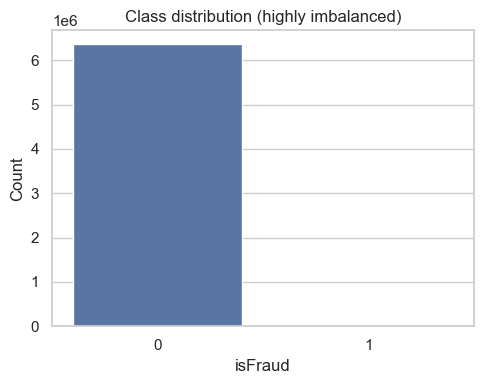

In [12]:
# Compute majority-to-minority imbalance ratio and plot the class distribution.
maj, minr = target_tbl["count"].max(), target_tbl["count"].min()
imbalance_ratio = maj / minr
print(f"Imbalance (majority / minority): {imbalance_ratio:,.1f} : 1")

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=target_tbl.index.astype(str), y=target_tbl["count"], ax=ax)
ax.set_xlabel("isFraud")
ax.set_ylabel("Count")
ax.set_title("Class distribution (highly imbalanced)")
plt.tight_layout()
plt.show()


## 4. Univariate EDA

### 4.1 Numeric summaries

Full-data descriptive statistics for core numerics (cheap on this width).

In [13]:
# Descriptive statistics (with extra percentiles) for core numeric columns.
df[numeric_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest
count,"6,362,620.0000","6,362,620.0000","6,362,620.0000","6,362,620.0000","6,362,620.0000","6,362,620.0000"
mean,243.3972,"179,861.9035","833,883.1041","855,113.6686","1,100,701.6665","1,224,996.3982"
std,142.3320,"603,858.2315","2,888,242.6730","2,924,048.5030","3,399,180.1130","3,674,128.9421"
min,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1%,9.0000,449.4676,0.0000,0.0000,0.0000,0.0000
5%,16.0000,"2,224.0995",0.0000,0.0000,0.0000,0.0000
50%,239.0000,"74,871.9400","14,208.0000",0.0000,"132,705.6650","214,661.4400"
95%,490.0000,"518,634.1965","5,823,702.2785","5,980,262.3365","5,147,229.7135","5,515,715.9035"
99%,681.0000,"1,615,979.4716","16,027,256.1337","16,176,160.5580","12,371,819.1548","13,137,866.9410"
max,743.0000,"92,445,516.6400","59,585,040.3700","49,585,040.3700","356,015,889.3500","356,179,278.9200"


### 4.2 Distributions (sampled plots)

Histograms on millions of rows are slow and redundant; we plot a **stratified random sample** so both classes appear. This still supports conclusions about skew (especially `amount`).

In [14]:
# Build a stratified random sample for plotting so both fraud classes appear.
def stratified_sample(frame, col, n_per_class, random_state=RANDOM_STATE):
    parts = []
    for y in frame[col].unique():
        sub = frame[frame[col] == y]
        take = min(n_per_class, len(sub))
        parts.append(sub.sample(take, random_state=random_state))
    return pd.concat(parts, axis=0).sample(frac=1, random_state=random_state)

n_each = PLOT_SAMPLE_N // 2
plot_df = stratified_sample(df, TARGET, n_each)
print("Plot sample size:", len(plot_df), "| fraud:", plot_df[TARGET].sum())


Plot sample size: 108213 | fraud: 8213


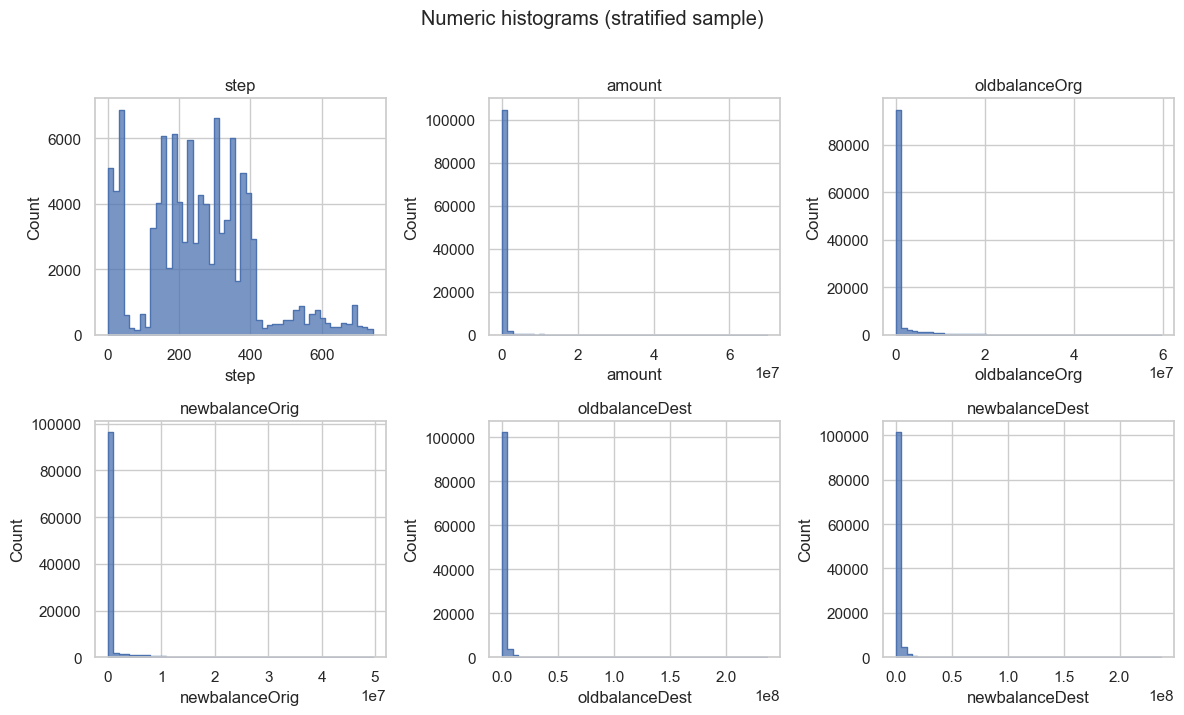

In [15]:
# Histograms of numeric features on the stratified sample (univariate shapes / skew).
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.ravel()
for ax, col in zip(axes, numeric_cols):
    sns.histplot(data=plot_df, x=col, bins=50, ax=ax, element="step")
    ax.set_title(col)
plt.suptitle("Numeric histograms (stratified sample)", y=1.02)
plt.tight_layout()
plt.show()


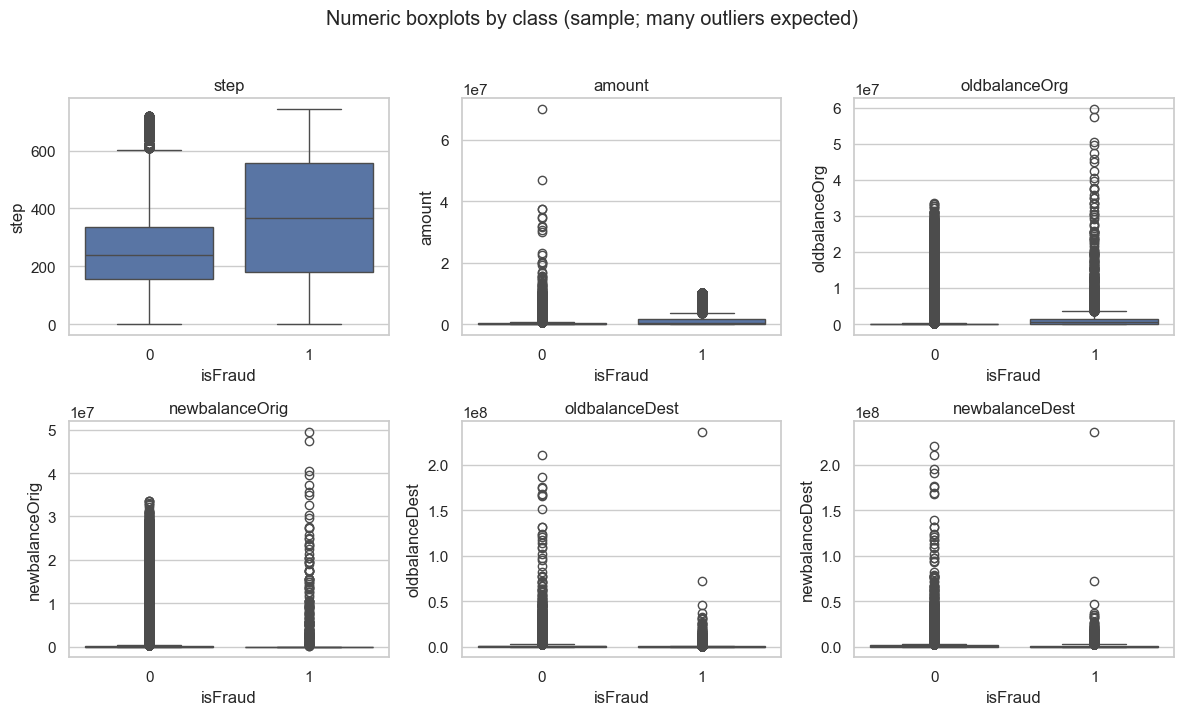

In [16]:
# Boxplots of numeric features by fraud label on the stratified sample.
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.ravel()
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=plot_df, y=col, x=plot_df[TARGET].astype(str), ax=ax)
    ax.set_title(col)
    ax.set_xlabel("isFraud")
plt.suptitle("Numeric boxplots by class (sample; many outliers expected)", y=1.02)
plt.tight_layout()
plt.show()


### 4.3 Transaction `type` frequency

Univariate view of the main categorical feature.

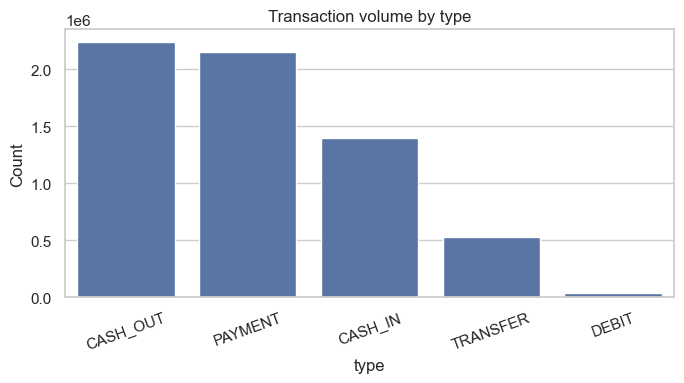

In [17]:
# Bar chart of transaction counts by type (univariate categorical).
type_counts = df["type"].value_counts()
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=type_counts.index, y=type_counts.values, ax=ax)
ax.set_ylabel("Count")
ax.set_xlabel("type")
ax.set_title("Transaction volume by type")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 5. Bivariate EDA — fraud vs features

### 5.1 Fraud rate by transaction type

Computed on **full data** (groupby is efficient). Fraud often concentrates in specific types in PaySim-like data.

In [18]:
# Aggregate fraud count and fraud rate by transaction type (full data).
fraud_by_type = (
    df.groupby("type", observed=False)
    .agg(n=(TARGET, "size"), frauds=(TARGET, "sum"))
    .assign(fraud_rate=lambda x: x["frauds"] / x["n"] * 100)
    .sort_values("fraud_rate", ascending=False)
)
fraud_by_type


,n,frauds,fraud_rate
type,,,
TRANSFER,532909,4097,0.7688
CASH_OUT,2237500,4116,0.1840
CASH_IN,1399284,0,0.0000
DEBIT,41432,0,0.0000
PAYMENT,2151495,0,0.0000


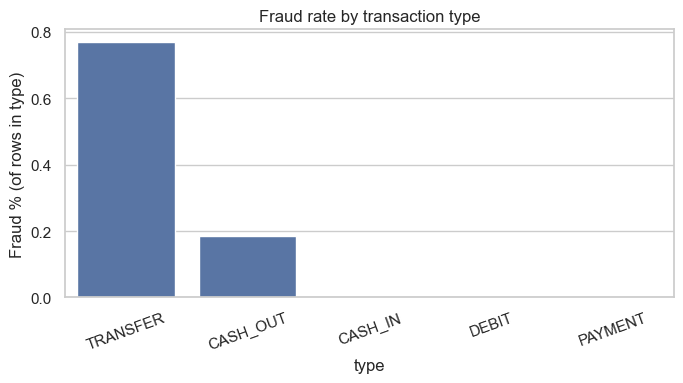

In [19]:
# Bar chart of fraud rate by transaction type.
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=fraud_by_type.index, y=fraud_by_type["fraud_rate"], ax=ax)
ax.set_ylabel("Fraud % (of rows in type)")
ax.set_xlabel("type")
ax.set_title("Fraud rate by transaction type")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


### 5.2 Key numerics by class (sample)

Boxplots of numeric features by `isFraud` on the stratified sample `plot_df` are in **section 4.2** above. **Takeaway:** compare medians and spread; heavy tails mean robust scaling or tree models may behave differently than linear models.


### 5.3 Fraud over time (`step`)

`step` is a simulated time unit (1 step = 1 hour in PaySim documentation). We aggregate counts and fraud rate per step on the **full** dataset.

In [20]:
# Aggregate transaction volume, fraud count, and fraud rate by time step.
step_agg = (
    df.groupby("step")
    .agg(transactions=(TARGET, "size"), frauds=(TARGET, "sum"))
    .assign(fraud_rate=lambda x: x["frauds"] / x["transactions"] * 100)
)
step_agg.head()


,transactions,frauds,fraud_rate
step,,,
1,2708,16,0.5908
2,1014,8,0.7890
3,552,4,0.7246
4,565,10,1.7699
5,665,6,0.9023


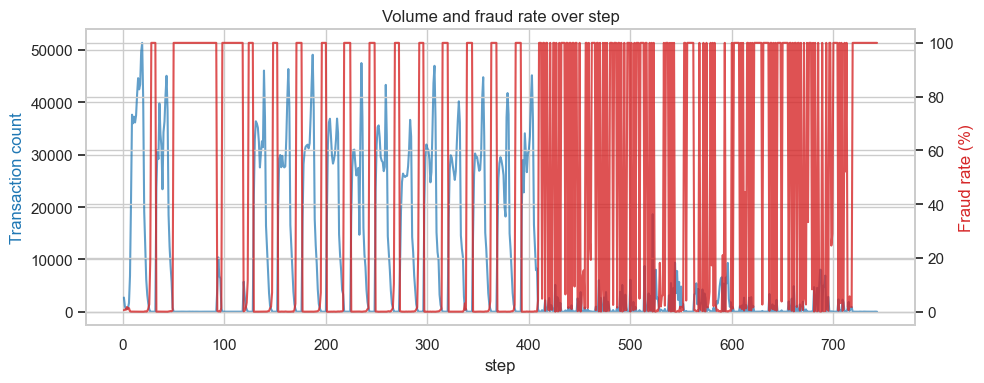

In [21]:
# Line plot of transaction volume and fraud rate over step.
fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(step_agg.index, step_agg["transactions"], color="tab:blue", alpha=0.7, label="Transactions")
ax1.set_xlabel("step")
ax1.set_ylabel("Transaction count", color="tab:blue")
ax2 = ax1.twinx()
ax2.plot(step_agg.index, step_agg["fraud_rate"], color="tab:red", alpha=0.8, label="Fraud rate %")
ax2.set_ylabel("Fraud rate (%)", color="tab:red")
ax1.set_title("Volume and fraud rate over step")
fig.tight_layout()
plt.show()


 ### 5.4 FRAUD PAIR ANALYSIS — Check all type combinations in fraud  ---for Novel contibution

In [22]:
# ============================================================
# 1st part ->FRAUD PAIR ANALYSIS — Check all type combinations in fraud
# ============================================================

fraud_df = df[df["isFraud"] == 1].copy()

print("=== FRAUD TRANSACTIONS BY TYPE ===")
print(fraud_df["type"].value_counts())
print()

print("=== FRAUD COUNT BY TYPE (%) ===")
print(fraud_df["type"].value_counts(normalize=True) * 100)
print()

print("=== DO ANY TWO FRAUD ROWS SHARE SAME step + amount? ===")
pairs = fraud_df.groupby(["step", "amount"]).size().reset_index(name="count")
pairs_multi = pairs[pairs["count"] > 1]
print(f"Groups with same step+amount among fraud rows: {len(pairs_multi)}")
print(pairs_multi.head(10))
print()

print("=== SAMPLE ACTUAL PAIRS (same step + amount, both fraud) ===")
if len(pairs_multi) > 0:
    sample_key = pairs_multi.iloc[0]
    sample = fraud_df[
        (fraud_df["step"] == sample_key["step"]) & 
        (fraud_df["amount"] == sample_key["amount"])
    ]
    print(sample[["step","type","amount","nameOrig","nameDest","isFraud"]])
print()

print("=== ALL TYPE COMBINATIONS IN FRAUD PAIRS ===")
if len(pairs_multi) > 0:
    merged = pairs_multi.merge(fraud_df, on=["step","amount"])
    combo = merged.groupby(["step","amount"])["type"].apply(
        lambda x: " + ".join(sorted(x.tolist()))
    ).value_counts()
    print(combo)

=== FRAUD TRANSACTIONS BY TYPE ===
type
CASH_OUT    4116
TRANSFER    4097
Name: count, dtype: int64

=== FRAUD COUNT BY TYPE (%) ===
type
CASH_OUT   50.1157
TRANSFER   49.8843
Name: proportion, dtype: float64

=== DO ANY TWO FRAUD ROWS SHARE SAME step + amount? ===
Groups with same step+amount among fraud rows: 4026
    step         amount  count
0      1       181.0000      2
1      1     2,806.0000      2
2      1    20,128.0000      2
3      1    25,071.4600      2
4      1    35,063.6300      2
6      1   235,238.6600      2
8      1 1,277,212.7700      2
9      2    14,949.8400      2
10     2    18,627.0200      2
11     2   963,532.1400      2

=== SAMPLE ACTUAL PAIRS (same step + amount, both fraud) ===
   step      type   amount     nameOrig    nameDest  isFraud
2     1  TRANSFER 181.0000  C1305486145  C553264065        1
3     1  CASH_OUT 181.0000   C840083671   C38997010        1

=== ALL TYPE COMBINATIONS IN FRAUD PAIRS ===
type
CASH_OUT + TRANSFER                          

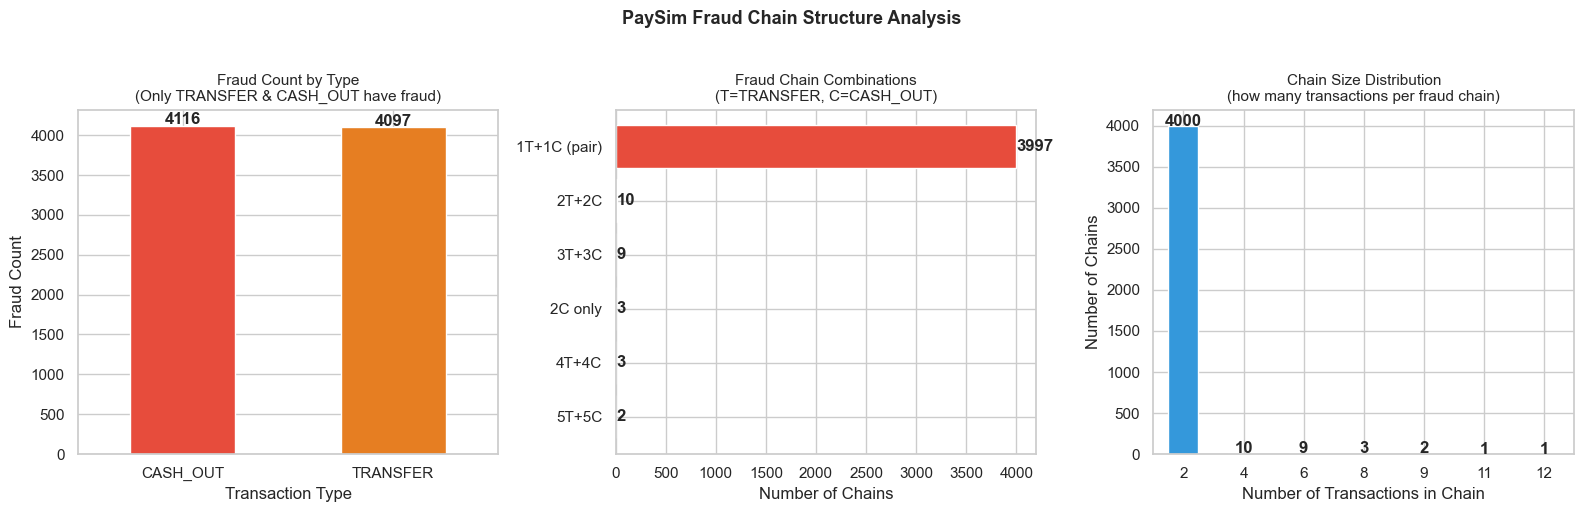


Key numbers:
Total fraud chains found : 4026
Simple pairs (1T + 1C)   : 3997 chains = 7994 transactions
Longer chains (3+ txns)  : 7 different patterns


In [23]:
# ============================================================
# second part- FRAUD CHAIN STRUCTURE — Visualization
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Graph 1: Fraud count by type ---
fraud_df["type"].value_counts().plot(
    kind="bar", ax=axes[0], color=["#e74c3c", "#e67e22"]
)
axes[0].set_title("Fraud Count by Type\n(Only TRANSFER & CASH_OUT have fraud)", fontsize=11)
axes[0].set_xlabel("Transaction Type")
axes[0].set_ylabel("Fraud Count")
axes[0].tick_params(axis="x", rotation=0)
for i, v in enumerate(fraud_df["type"].value_counts()):
    axes[0].text(i, v + 20, str(v), ha="center", fontweight="bold")

# --- Graph 2: Top fraud chain combinations ---
top_combos = combo.head(6).copy()
short_labels = [
    "1T+1C (pair)",
    "2T+2C",
    "3T+3C",
    "2C only",
    "4T+4C",
    "5T+5C"
]
axes[1].barh(short_labels[:len(top_combos)], top_combos.values, color="#e74c3c")
axes[1].set_title("Fraud Chain Combinations\n(T=TRANSFER, C=CASH_OUT)", fontsize=11)
axes[1].set_xlabel("Number of Chains")
axes[1].invert_yaxis()
for i, v in enumerate(top_combos.values):
    axes[1].text(v + 5, i, str(v), va="center", fontweight="bold")

# --- Graph 3: Chain size distribution ---
chain_sizes = merged.groupby(["step", "amount"])["type"].count()
chain_sizes.value_counts().sort_index().plot(
    kind="bar", ax=axes[2], color="#3498db"
)
axes[2].set_title("Chain Size Distribution\n(how many transactions per fraud chain)", fontsize=11)
axes[2].set_xlabel("Number of Transactions in Chain")
axes[2].set_ylabel("Number of Chains")
axes[2].tick_params(axis="x", rotation=0)
for i, v in enumerate(chain_sizes.value_counts().sort_index()):
    axes[2].text(i, v + 5, str(v), ha="center", fontweight="bold")

plt.suptitle("PaySim Fraud Chain Structure Analysis", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"\nKey numbers:")
print(f"Total fraud chains found : {len(pairs_multi)}")
print(f"Simple pairs (1T + 1C)   : {combo.iloc[0]} chains = {combo.iloc[0]*2} transactions")
print(f"Longer chains (3+ txns)  : {len(combo[1:])} different patterns")

## Fraud Chain Structure Analysis

### Key Discovery
PaySim fraud is **not random individual transactions** — it follows a 
deliberate two-step chain pattern where every fraud involves a 
**TRANSFER followed by a CASH_OUT** of the same amount at the same time step.

### Graph 1: Fraud Count by Type
- Only **two transaction types contain any fraud** — TRANSFER (4,097) 
  and CASH_OUT (4,116)
- PAYMENT, DEBIT, and CASH_IN have **zero fraud cases**
- The near-equal counts (difference of only 19) strongly suggest 
  these are **matched pairs**, not independent fraud events
- This shows that **PaySim fraud is overwhelmingly concentrated in the TRANSFER→CASH_OUT pattern**

### Graph 2: Fraud Chain Combinations
- **3,997 chains (99.3%)** are simple 1 TRANSFER + 1 CASH_OUT pairs
- This is the core fraud pattern: criminal moves money via TRANSFER, 
  then drains it via CASH_OUT
- A small number of **organized multi-hop chains** also exist:
  - 10 chains: 2 TRANSFER + 2 CASH_OUT (coordinated split fraud)
  - 9 chains: 3 TRANSFER + 3 CASH_OUT (larger organized rings)
  - 3 chains: 4 TRANSFER + 4 CASH_OUT
- **Existing models completely miss this structure** because they 
  score each transaction independently

### Graph 3: Chain Size Distribution
- **4,000 chains have exactly 2 transactions** (1T + 1C) — the 
  dominant simple fraud pattern
- Remaining chains go up to **12 transactions deep**, suggesting 
  organized fraud rings operating across multiple accounts
- The distribution is heavily right-skewed — simple pairs dominate 
  but complex chains exist

### Why This Matters for Our Novel Contribution
Current fraud detection treats each transaction as **isolated**. 
Our analysis proves that fraud in PaySim has **explicit chain 
structure**:

| Chain Type | Count | % of All Chains |
|------------|-------|-----------------|
| Simple pair (1T+1C) | 3,997 | 99.3% |
| Medium chain (2T+2C) | 10 | 0.25% |
| Large chain (3T+3C+) | 19 | 0.47% |
| **Total fraud chains** | **4,026** | **100%** |

> **Novel Contribution:** By engineering chain-level features 
> (is_chain_member, chain_size, chain_role) we give the triage 
> system information that no single-transaction model can see — 
> enabling earlier fraud detection before the CASH_OUT completes.

Our novel contribution is making the dominant TRANSFER -> CASH_OUT fraud chain explicit through engineered chain-aware features for triage-oriented fraud detection in PaySim.

This chain-aware contribution is evaluated through a controlled A/B comparison between no-chain and chain-aware setups under the same split, models, and metrics.


## 6. Fraud-oriented patterns — balances

### 6.1 Balance consistency (engineered checks)

For many legitimate transfers, sender balance should decrease by about `amount`. We define simple discrepancy features and compare fraud vs non-fraud on a sample.

In [24]:
# Add balance delta/residual columns and summarize by fraud class on a sample.
bal = df.assign(
    orig_delta=df["oldbalanceOrg"] - df["newbalanceOrig"],
    dest_delta=df["newbalanceDest"] - df["oldbalanceDest"],
    orig_residual=(df["oldbalanceOrg"] - df["newbalanceOrig"]) - df["amount"],
)
bal_sample = stratified_sample(bal, TARGET, n_each)
bal_sample[[TARGET, "orig_residual", "orig_delta", "dest_delta"]].groupby(TARGET).describe(percentiles=[0.5, 0.9, 0.99])


orig_residual                                              \
                count          mean          std              min   
isFraud                                                             
0        100,000.0000 -203,481.8210 648,212.1273 -69,886,731.3000   
1          8,213.0000  -10,692.3253 265,146.1311 -10,000,000.0000   

                                            orig_delta                 \
                 50%    90%    99%    max        count           mean   
isFraud                                                                 
0       -68,794.9100 0.0000 0.0000 0.0100 100,000.0000   -22,964.8055   
1             0.0000 0.0000 0.0000 0.0000   8,213.0000 1,457,274.9739   

                                                                    \
                   std             min          50%            90%   
isFraud                                                              
0         106,155.1250 -1,225,177.3300       0.0000    33,287.2030   
1       2,396,099.2020          0.0000 436,317.4900 4,475,400.1720   

                                          dest_delta               \
                    99%             max        count         mean   
isFraud                                                             
0          209,982.7422  2,802,396.1900 100,000.0000 127,768.2836   
1       10,000,000.0000 10,000,000.0000   8,213.0000 735,457.9981   

                                                                              \
                   std             min    50%            90%             99%   
isFraud                                                                        
0         872,880.4000 -1,664,863.3200 0.0000   351,662.4340  1,792,825.7509   
1       1,856,983.8560   -315,226.0700 0.0000 2,054,275.5700 10,000,000.0000   

                         
                    max  
isFraud                  
0       82,704,592.2600  
1       14,915,111.4700

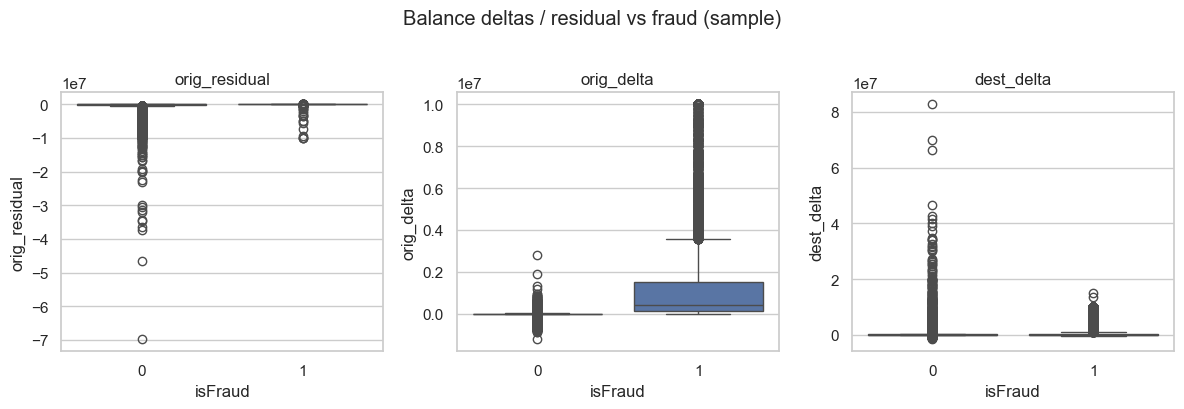

In [25]:
# Boxplots of balance deltas and residual by fraud class (sample).
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, col in zip(axes, ["orig_residual", "orig_delta", "dest_delta"]):
    sns.boxplot(data=bal_sample, x=bal_sample[TARGET].astype(str), y=col, ax=ax)
    ax.set_title(col)
plt.suptitle("Balance deltas / residual vs fraud (sample)", y=1.02)
plt.tight_layout()
plt.show()


### 6.2 Zero-balance flags (quick fraud rate tables)

We tabulate fraud prevalence when origin/destination balances are zero. Full-data groupby.

In [26]:
# Compare fraud rate for zero-balance flag combinations (full data).
flags = df.assign(
    orig_zero_old=df["oldbalanceOrg"] == 0,
    dest_zero_old=df["oldbalanceDest"] == 0,
    orig_zero_new=df["newbalanceOrig"] == 0,
    dest_zero_new=df["newbalanceDest"] == 0,
)
for c in ["orig_zero_old", "dest_zero_old", "orig_zero_new", "dest_zero_new"]:
    t = flags.groupby(c)[TARGET].mean() * 100
    print(c)
    print(t)
    print()


orig_zero_old
orig_zero_old
False   0.1918
True    0.0020
Name: isFraud, dtype: float64

dest_zero_old
dest_zero_old
False   0.0782
True    0.1979
Name: isFraud, dtype: float64

orig_zero_new
orig_zero_new
False   0.0058
True    0.2231
Name: isFraud, dtype: float64

dest_zero_new
dest_zero_new
False   0.1051
True    0.1677
Name: isFraud, dtype: float64



### 6.3 `amount` by fraud — log scale

Raw amounts are extremely skewed; log view matches the preprocessing idea (`log1p`).

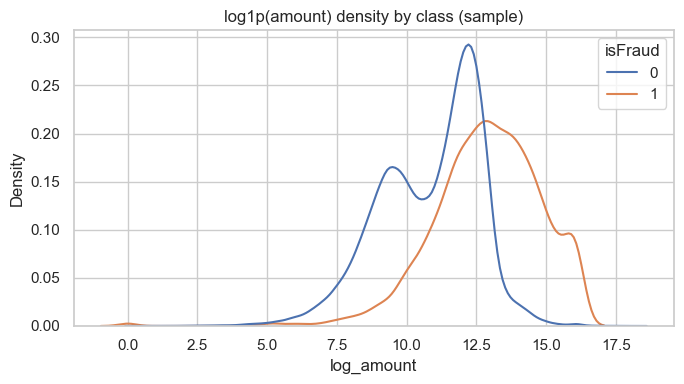

In [27]:
# KDE of log1p(amount) by fraud class on the stratified sample.
plot_df_log = plot_df.assign(log_amount=np.log1p(plot_df["amount"]))
fig, ax = plt.subplots(figsize=(7, 4))
sns.kdeplot(data=plot_df_log, x="log_amount", hue=plot_df_log[TARGET].astype(str), common_norm=False, ax=ax)
ax.set_title("log1p(amount) density by class (sample)")
plt.tight_layout()
plt.show()


## 7. Multivariate — correlation structure

Linear correlation among numerics (full data). Useful for redundancy (e.g., balances) before linear models; trees handle dependence differently.

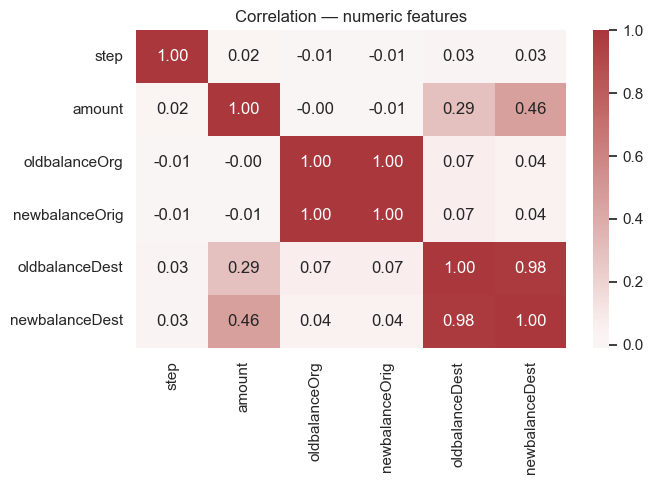

In [28]:
# Correlation heatmap for numeric features (full data).
corr = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax)
ax.set_title("Correlation — numeric features")
plt.tight_layout()
plt.show()


### Optional: scatter on a small stratified sample (multivariate)

Joint view of two numerics with fraud highlighted — **do not** over-interpret from a sample; use for intuition only.

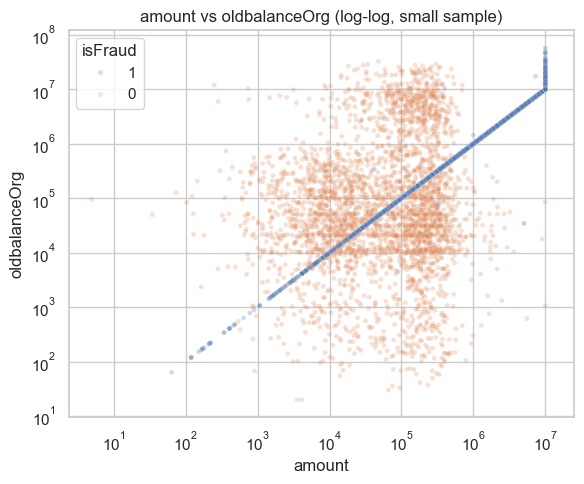

In [29]:
# Log-log scatter of amount vs oldbalanceOrg on a small stratified sample (multivariate glimpse).
scat = stratified_sample(df, TARGET, 5_000)
fig, ax = plt.subplots(figsize=(6, 5))
sns.scatterplot(
    data=scat,
    x="amount",
    y="oldbalanceOrg",
    hue=scat[TARGET].astype(str),
    alpha=0.25,
    s=12,
    ax=ax,
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("amount vs oldbalanceOrg (log-log, small sample)")
plt.tight_layout()
plt.show()


## 8. Leakage and risky columns

### 8.1 `isFlaggedFraud`

This column flags very large transactions under a rule. It is **not** the same as `isFraud`, but it can be **highly aligned** with the label. Using it as a feature can inflate performance unrealistically or mimic label information. **Decision for modeling:** document whether we drop it, use it only as a baseline diagnostic, or keep it with justification.

In [30]:
# Cross-tabulate isFlaggedFraud vs isFraud to assess overlap.
pd.crosstab(df["isFlaggedFraud"], df[TARGET], margins=True)


isFraud,0,1,All
isFlaggedFraud,,,
0,6354407,8197,6362604
1,0,16,16
All,6354407,8213,6362620


In [31]:
# Print fraud rate when isFlaggedFraud is 1 vs 0.
print("Fraud rate when isFlaggedFraud == 1:", df.loc[df["isFlaggedFraud"] == 1, TARGET].mean() * 100, "%")
print("Fraud rate when isFlaggedFraud == 0:", df.loc[df["isFlaggedFraud"] == 0, TARGET].mean() * 100, "%")


Fraud rate when isFlaggedFraud == 1: 100.0 %
Fraud rate when isFlaggedFraud == 0: 0.12883090005287143 %


### 8.2 Post-transaction balances

In real-time fraud scoring, **post**-transaction balances may be unavailable at decision time or may be derived after the event. For this academic dataset, treat as **available features** but note the **operational** caveat in the report.
Post-transaction balance fields are used in this academic offline evaluation, but they may require redesign for strict real-time deployment.


## 9. Preprocessing preview — `log1p(amount)`

Side-by-side view motivates the log transform planned in the proposal (actual scaling/encoding belongs in the preprocessing notebook).

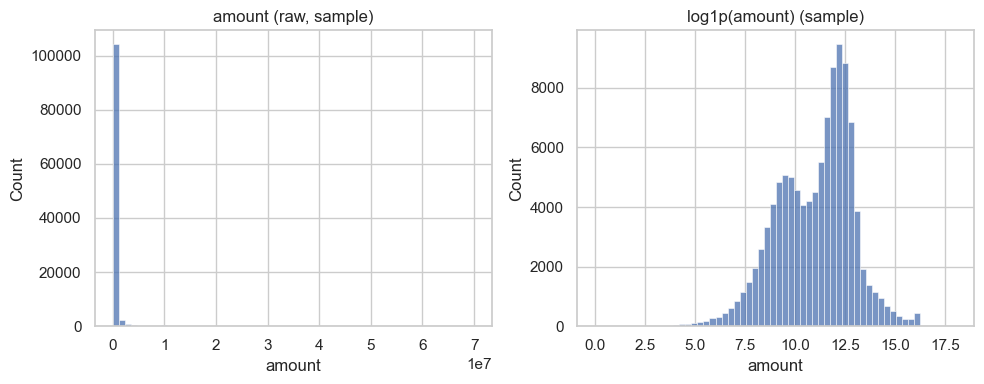

In [32]:
# Side-by-side histograms of raw amount and log1p(amount) on the sample (preprocessing motivation).
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(plot_df["amount"], bins=60, ax=axes[0])
axes[0].set_title("amount (raw, sample)")
sns.histplot(np.log1p(plot_df["amount"]), bins=60, ax=axes[1])
axes[1].set_title("log1p(amount) (sample)")
plt.tight_layout()
plt.show()


## 10. Key findings and feature action plan

**Key findings** (from this run of the notebook):

- **Scale:** 6,362,620 transactions and 11 columns; `df.info()` reports ~534 MB in memory.
- **Quality:** No missing values, no full-row duplicates, and no negative `amount` or negative values in the listed numeric columns.
- **Imbalance:** 6,354,407 legitimate (99.87%) vs 8,213 fraudulent (0.129%); majority-to-minority ratio **773.7 : 1**. Raw accuracy will be misleading; use PR-AUC, precision/recall, and cost-sensitive thresholds (as in the project proposal).
- **Fraud by `type`:** All frauds fall under **TRANSFER** (~0.77% of those rows) and **CASH_OUT** (~0.18%). **CASH_IN**, **DEBIT**, and **PAYMENT** show zero frauds here; `type` is a strong driver for modeling and interpretation.
- **Plot sample:** Stratified sample size is 108,213 rows (all 8,213 fraud cases plus a subsample of legitimate rows), limited by the minority class.
- **Balances:** Balance deltas, residuals, and zero-balance flags show materially different fraud rates; these motivate explicit features in preprocessing (see section 6).
- **`amount`:** Distributions are heavy-tailed; **log1p(`amount`)** is justified before linear or margin-based models (see section 9).
- **`isFlaggedFraud`:** When the flag equals 1, fraud rate is 100% but only **16** rows; when it equals 0, fraud rate is about **0.129%** with **8,197** frauds, so most fraud is not flagged by this rule. Using it as a feature risks leakage or inflated performance; document keep/drop in the report.
- **IDs:** `nameOrig` and `nameDest` are high-cardinality identifiers; drop for a simple tabular baseline or engineer aggregates later.

The table below summarizes a **preprocessing / modeling feature plan** derived from this EDA.


In [33]:
# Starter feature action table for preprocessing: keep/drop, dtypes, leakage notes.
feature_plan = pd.DataFrame([
    {"feature": "step", "dtype": "numeric", "preprocessing": "optional scaling for SVM/k-NN", "keep_drop": "keep", "leakage_risk": "low"},
    {"feature": "type", "dtype": "categorical", "preprocessing": "one-hot or target encoding", "keep_drop": "keep", "leakage_risk": "low"},
    {"feature": "amount", "dtype": "numeric", "preprocessing": "log1p + scale for linear/SVM", "keep_drop": "keep", "leakage_risk": "low"},
    {"feature": "oldbalanceOrg", "dtype": "numeric", "preprocessing": "scale / tree raw", "keep_drop": "keep", "leakage_risk": "low"},
    {"feature": "newbalanceOrig", "dtype": "numeric", "preprocessing": "scale / tree raw", "keep_drop": "keep", "leakage_risk": "note: post-tx"},
    {"feature": "oldbalanceDest", "dtype": "numeric", "preprocessing": "scale / tree raw", "keep_drop": "keep", "leakage_risk": "low"},
    {"feature": "newbalanceDest", "dtype": "numeric", "preprocessing": "scale / tree raw", "keep_drop": "keep", "leakage_risk": "note: post-tx"},
    {"feature": "nameOrig", "dtype": "id", "preprocessing": "drop for baseline or hash/aggregate", "keep_drop": "TBD", "leakage_risk": "low if no future info"},
    {"feature": "nameDest", "dtype": "id", "preprocessing": "drop for baseline or hash/aggregate", "keep_drop": "TBD", "leakage_risk": "low if no future info"},
    {"feature": "isFlaggedFraud", "dtype": "binary", "preprocessing": "often DROP as feature; analyze separately", "keep_drop": "TBD", "leakage_risk": "high / policy"},
])
feature_plan


,feature,dtype,preprocessing,keep_drop,leakage_risk
0,step,numeric,optional scaling for SVM/k-NN,keep,low
1,type,categorical,one-hot or target encoding,keep,low
2,amount,numeric,log1p + scale for linear/SVM,keep,low
3,oldbalanceOrg,numeric,scale / tree raw,keep,low
4,newbalanceOrig,numeric,scale / tree raw,keep,note: post-tx
5,oldbalanceDest,numeric,scale / tree raw,keep,low
6,newbalanceDest,numeric,scale / tree raw,keep,note: post-tx
7,nameOrig,id,drop for baseline or hash/aggregate,TBD,low if no future info
8,nameDest,id,drop for baseline or hash/aggregate,TBD,low if no future info
9,isFlaggedFraud,binary,often DROP as feature; analyze separately,TBD,high / policy


---

## Part II — Data preprocessing (continuation)

This section prepares **train/test splits** and a **reusable preprocessing pipeline** for modeling. It assumes you already ran the cells above so `df` and `RANDOM_STATE` exist.

**Evaluation artifacts:** **ROC curves** and **confusion matrices** are created **after** you train a model and produce predictions on validation or test data (or from cross-validation). They are not part of preprocessing.

**Rules:** stratified split first; fit encoders/scalers on **training data only**; apply the same fitted transformers to the test set; **SMOTE** (if used) only on the **training** portion, never on the test set.

### 11.1 Imports for preprocessing 

Install if needed: `pip install imbalanced-learn` (provides `imblearn`).

In [34]:
# Import scikit-learn utilities and SMOTE for imbalance handling (training data only).
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import joblib

# If this import fails, run: pip install imbalanced-learn
from imblearn.over_sampling import SMOTE


### 11.2 Build modeling table: target, drops, engineered features, and chain features

We build `df_model` with row-wise engineered features and `log_amount`, then create a **base feature matrix** for splitting.

For leakage-safe evaluation, chain-aware features are computed **after** split within each split (`X_train` and `X_test`) using only rows available in that split.

In [35]:
# Build df_model with row-wise engineered features, then create base X/y for downstream split.
# Columns removed from X and why:
# - isFraud -> target y only (must not be a feature).
# - amount -> replaced by log_amount (proposal: log transform; avoids duplicate raw+log inputs).
# - nameOrig/nameDest -> high-cardinality IDs; one-hot not feasible in baseline.
# - isFlaggedFraud -> business-rule flag; leakage/inflated metrics risk.
TARGET = "isFraud"
DROP_FROM_X = ["nameOrig", "nameDest", "isFlaggedFraud"]

df_model = df.copy()
df_model["orig_delta"] = df_model["oldbalanceOrg"] - df_model["newbalanceOrig"]
df_model["dest_delta"] = df_model["newbalanceDest"] - df_model["oldbalanceDest"]
df_model["orig_residual"] = df_model["orig_delta"] - df_model["amount"]
df_model["orig_zero_old"] = (df_model["oldbalanceOrg"] == 0).astype(np.int8)
df_model["dest_zero_old"] = (df_model["oldbalanceDest"] == 0).astype(np.int8)
df_model["orig_zero_new"] = (df_model["newbalanceOrig"] == 0).astype(np.int8)
df_model["dest_zero_new"] = (df_model["newbalanceDest"] == 0).astype(np.int8)
df_model["log_amount"] = np.log1p(df_model["amount"].astype(np.float64))

y = df_model[TARGET].astype(np.int8)
X_base = df_model.drop(columns=[TARGET] + DROP_FROM_X)
print("X_base shape:", X_base.shape, "| y shape:", y.shape, "| fraud rate:", y.mean() * 100, "%")


X_base shape: (6362620, 15) | y shape: (6362620,) | fraud rate: 0.12908204481801522 %


### 11.2b Chain feature verification

Define a reusable chain-feature function. We will apply it separately to train and test after split to keep evaluation leakage-safe.

Chain features are computed after the train/test split, separately within each split, to avoid test-to-train leakage.
This split-safe design may reduce some chain coverage compared with full-log grouping, but it provides a more defensible offline evaluation.


In [36]:
# Reusable chain-feature builder (uses only step/amount/type; never target labels).
CHAIN_SIZE_CAP = 12  # Set to None to disable cap.

def add_chain_features(frame, chain_size_cap=CHAIN_SIZE_CAP):
    out = frame.copy()
    chain_group = (
        out.groupby(["step", "amount"], as_index=False)
        .agg(
            chain_size=("type", "size"),
            has_transfer=("type", lambda s: (s == "TRANSFER").any()),
            has_cash_out=("type", lambda s: (s == "CASH_OUT").any()),
        )
    )
    chain_group["is_chain_member"] = (chain_group["has_transfer"] & chain_group["has_cash_out"])
    if chain_size_cap is not None:
        chain_group["is_chain_member"] = chain_group["is_chain_member"] & (chain_group["chain_size"] <= chain_size_cap)
    chain_group["is_chain_member"] = chain_group["is_chain_member"].astype(np.int8)
    out = out.merge(
        chain_group[["step", "amount", "chain_size", "is_chain_member"]],
        on=["step", "amount"],
        how="left",
    )
    out["chain_size"] = out["chain_size"].astype(np.int32)
    out["is_chain_member"] = out["is_chain_member"].astype(np.int8)
    return out

print("Defined: add_chain_features(frame, chain_size_cap=CHAIN_SIZE_CAP)")


Defined: add_chain_features(frame, chain_size_cap=CHAIN_SIZE_CAP)


### 11.3 Stratified train/test split

Keeps the **fraud proportion** similar in train and test. **No** scaling or SMOTE before this step.

In [37]:
# Split base features and target, then add chain features separately inside each split.
TEST_SIZE = 0.2
X_train, X_test, y_train, y_test = train_test_split(
    X_base, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)
X_train = add_chain_features(X_train, chain_size_cap=CHAIN_SIZE_CAP)
X_test = add_chain_features(X_test, chain_size_cap=CHAIN_SIZE_CAP)
X_train = X_train.drop(columns=["amount"])
X_test = X_test.drop(columns=["amount"])

print("Train:", X_train.shape, "fraud %:", y_train.mean() * 100)
print("Test: ", X_test.shape, "fraud %:", y_test.mean() * 100)
print("Train chain member %:", X_train["is_chain_member"].mean() * 100)
print("Test  chain member %:", X_test["is_chain_member"].mean() * 100)

Train: (5090096, 16) fraud %: 0.12907418642005966
Test:  (1272524, 16) fraud %: 0.12911347840983745
Train chain member %: 0.10518465663515973
Test  chain member %: 0.03056916804712524


### 11.4 Column transformer: scale numerics, one-hot `type`

**Fit on `X_train` only**; then transform train and test. This matches “split first, preprocess second.”

In [38]:
# Define numeric vs categorical columns and build a ColumnTransformer (fit on training only).
cat_features = ["type"]
num_features = [c for c in X_train.columns if c not in cat_features]

ohe_kwargs = {"handle_unknown": "ignore"}
try:
    ohe = OneHotEncoder(**ohe_kwargs, sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(**ohe_kwargs, sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", ohe, cat_features),
    ],
    remainder="drop",
)

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)
print("Processed train:", X_train_proc.shape, "| test:", X_test_proc.shape)

Processed train: (5090096, 20) | test: (1272524, 20)


### 11.4.1 VERIFY ALL FEATURE NAMES AFTER PREPROCESSING

In [39]:
# ============================================================
# VERIFY ALL FEATURE NAMES AFTER PREPROCESSING
# ============================================================

import numpy as np

# 1. All feature names from preprocessor
all_names = preprocessor.get_feature_names_out()
print("=== ALL FEATURE NAMES AFTER PREPROCESSING ===")
for i, name in enumerate(all_names):
    print(f"  {i:2d}: {name}")

print(f"\nTotal features: {len(all_names)}")

# 2. Just the one-hot encoded type columns
print("\n=== ONE-HOT ENCODED TYPE COLUMNS ONLY ===")
type_cols = [n for n in all_names if "type" in n.lower()]
print(type_cols)

# 3. Numeric columns
print("\n=== NUMERIC COLUMNS ===")
num_cols = [n for n in all_names if "type" not in n.lower()]
print(num_cols)

# 4. Shape check
print("\n=== SHAPE CHECK ===")
print("X_train_proc shape:", X_train_proc.shape)
print("X_test_proc shape: ", X_test_proc.shape)
print("Expected cols:     ", len(all_names))

=== ALL FEATURE NAMES AFTER PREPROCESSING ===
   0: num__step
   1: num__oldbalanceOrg
   2: num__newbalanceOrig
   3: num__oldbalanceDest
   4: num__newbalanceDest
   5: num__orig_delta
   6: num__dest_delta
   7: num__orig_residual
   8: num__orig_zero_old
   9: num__dest_zero_old
  10: num__orig_zero_new
  11: num__dest_zero_new
  12: num__log_amount
  13: num__chain_size
  14: num__is_chain_member
  15: cat__type_CASH_IN
  16: cat__type_CASH_OUT
  17: cat__type_DEBIT
  18: cat__type_PAYMENT
  19: cat__type_TRANSFER

Total features: 20

=== ONE-HOT ENCODED TYPE COLUMNS ONLY ===
['cat__type_CASH_IN', 'cat__type_CASH_OUT', 'cat__type_DEBIT', 'cat__type_PAYMENT', 'cat__type_TRANSFER']

=== NUMERIC COLUMNS ===
['num__step', 'num__oldbalanceOrg', 'num__newbalanceOrig', 'num__oldbalanceDest', 'num__newbalanceDest', 'num__orig_delta', 'num__dest_delta', 'num__orig_residual', 'num__orig_zero_old', 'num__dest_zero_old', 'num__orig_zero_new', 'num__dest_zero_new', 'num__log_amount', 'num__cha

### 11.5 Sanity checks (no leakage via test, no NaNs)

Confirm shapes, finite values, and that the **test** matrix was transformed with **fitted** parameters from train.

In [40]:
# Verify processed arrays are finite, aligned, and class balance is still extreme but stratified.
assert X_train_proc.shape[0] == len(y_train)
assert X_test_proc.shape[0] == len(y_test)
assert not np.isnan(X_train_proc).any()
assert not np.isnan(X_test_proc).any()
print("OK: shapes align, no NaNs in processed arrays.")

OK: shapes align, no NaNs in processed arrays.


### 11.6 SMOTE on **training** data only

We apply SMOTE only to **`X_train_proc`, `y_train`**. **Never** apply SMOTE to the test set. For cross-validation, the best practice is an `imblearn` pipeline so SMOTE runs **inside each fold** on training folds only (we can add that in the modeling section).

**Scale note:** We cap the target fraud count so SMOTE does not expand to millions of rows.


In [41]:
# Apply SMOTE on the processed training set only (never on test).
n_maj = int((y_train == 0).sum())
n_min = int(y_train.sum())

# Cap the target minority count to keep runtime/memory reasonable on PaySim.
target_minority = max(n_min, min(int(0.005 * n_maj), n_maj))
smote = SMOTE(random_state=RANDOM_STATE, sampling_strategy={1: target_minority})
X_train_smote, y_train_smote = smote.fit_resample(X_train_proc, y_train)
print("Before SMOTE:", X_train_proc.shape, "fraud %:", y_train.mean() * 100)
print("After  SMOTE:", X_train_smote.shape, "fraud %:", y_train_smote.mean() * 100)


Before SMOTE: (5090096, 20) fraud %: 0.12907418642005966
After  SMOTE: (5108943, 20) fraud %: 0.4975001678429374


### 11.6b SMOTE class-balancing impact (log-scale view)

**What changed in this step:**
- Majority class (`0` = legitimate) is kept as is; minority class (`1` = fraud) is oversampled.
- Fraud count increases from **6,570** to **25,417** while legitimate count stays **5,083,526**.
- Fraud share rises from about **0.129%** to about **0.498%** in training data.
- We use a **log-scale y-axis** so minority-class bars are visible and comparable.


,dataset,legitimate_count,fraud_count,fraud_rate_pct
0,Before SMOTE,5083526,6570,0.1291
1,After SMOTE,5083526,25417,0.4975


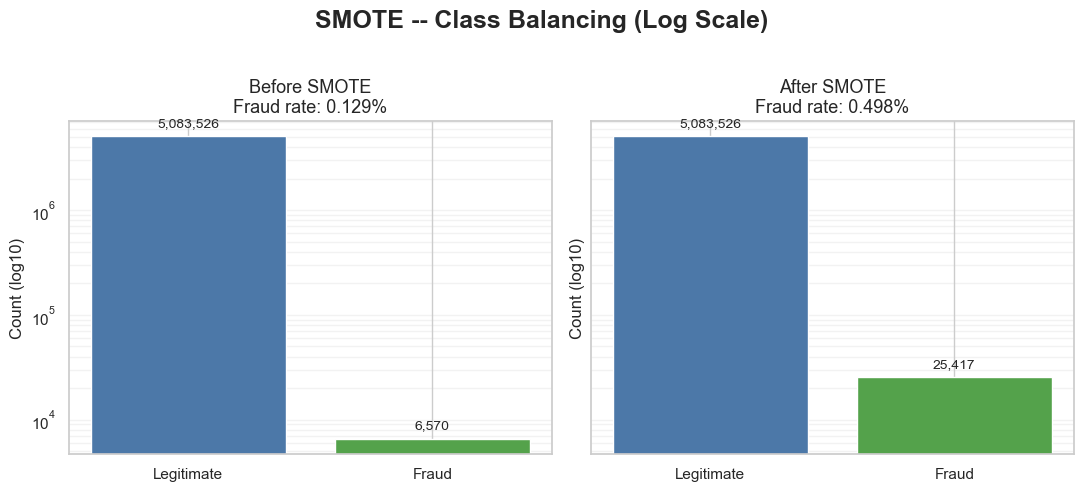

In [42]:
# Plot one clean before/after SMOTE chart with log-scale y-axis for minority-class visibility.
import matplotlib.ticker as mticker

before_counts = y_train.value_counts().sort_index()
after_counts = y_train_smote.value_counts().sort_index()

before_legit, before_fraud = int(before_counts.get(0, 0)), int(before_counts.get(1, 0))
after_legit, after_fraud = int(after_counts.get(0, 0)), int(after_counts.get(1, 0))
before_rate = (before_fraud / max(1, before_legit + before_fraud)) * 100
after_rate = (after_fraud / max(1, after_legit + after_fraud)) * 100

smote_balance_df = pd.DataFrame({
    "dataset": ["Before SMOTE", "After SMOTE"],
    "legitimate_count": [before_legit, after_legit],
    "fraud_count": [before_fraud, after_fraud],
    "fraud_rate_pct": [before_rate, after_rate],
})
display(smote_balance_df)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), sharey=True)
fig.suptitle("SMOTE -- Class Balancing (Log Scale)", fontsize=18, fontweight="bold", y=1.02)

for ax, title, legit, fraud, fr in [
    (axes[0], "Before SMOTE", before_legit, before_fraud, before_rate),
    (axes[1], "After SMOTE", after_legit, after_fraud, after_rate),
]:
    bars = ax.bar(["Legitimate", "Fraud"], [max(1, legit), max(1, fraud)], color=["#4C78A8", "#54A24B"])
    ax.set_yscale("log")
    ax.set_title(f"{title}\nFraud rate: {fr:.3f}%", fontsize=13)
    ax.set_ylabel("Count (log10)")
    ax.grid(axis="y", alpha=0.25, which="both")
    ax.set_axisbelow(True)
    for b, val in zip(bars, [legit, fraud]):
        ax.annotate(f"{val:,}",
                    xy=(b.get_x() + b.get_width()/2, b.get_height()),
                    xytext=(0, 5), textcoords="offset points",
                    ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()


### 11.7 Save preprocessing artifact (optional but recommended)

Saves the **fitted** `ColumnTransformer` next to this notebook so modeling code can `transform` new data the same way.

In [43]:
# Persist the fitted preprocessor with joblib for reproducibility in model training notebooks.
from pathlib import Path

_artifact_path = Path("preprocessor_paysim.joblib")
joblib.dump(preprocessor, _artifact_path)
print("Saved:", _artifact_path.resolve())

Saved: /Users/snehasingh/ML/PaySim-Fraud-Triage/preprocessor_paysim.joblib


### 11.8 What you have now (for the next section)

| Object | Use |
|--------|-----|
| `X_train_proc`, `X_test_proc` | Baseline training/evaluation (no SMOTE) |
| `y_train`, `y_test` | Labels aligned with the rows above |
| `X_train_smote`, `y_train_smote` | Training **only** when you want SMOTE-augmented learning |
| `preprocessor` | `transform` on any new `X` with the same columns as `X_train` |

**Next:** model training, then **ROC / PR curves**, **confusion matrices**, and cost-sensitive thresholds on **`X_test_proc`** (or CV).

---

## Part III - Model Training and Evaluation (Clean Final Section)

This section compares core baselines and extended benchmark models on the same preprocessed train/test split from Part II.

### Core baselines (as decided at project start)
- Logistic Regression variants: `logreg_plain`, `logreg_class_weight`, `logreg_smote`
- Random Forest variants: `rf_plain`, `rf_class_weight`, `rf_smote`

### Extended benchmarks (added for stronger comparison)
- `xgb_plain`
- `catboost_plain` (enabled when CatBoost package is installed)
- `lgbm_plain`
- `lgbm_weighted`

### Final model additions (closed set — no further model families after this)
- `brf_plain` — **Balanced Random Forest** (`imblearn.ensemble.BalancedRandomForestClassifier`): imbalance-aware RF-style ensemble on the same dense preprocessed matrix as other tabular models.
- `gnb_plain` — **Gaussian Naive Bayes** (`sklearn.naive_bayes.GaussianNB`): fast probabilistic baseline on the same features (trained twice under A/B like everything else).

### Dynamic reporting groups used in this notebook
- **Primary models:** controlled by `PRIMARY_EXPERIMENTS` (currently includes `rf_plain`, `xgb_plain`, `catboost_plain`, `lgbm_plain`, `brf_plain`, `gnb_plain`).
- **Supporting models:** controlled by `SUPPORTING_EXPERIMENTS` (currently includes `logreg_plain`, `lgbm_weighted`).
- **Displayed comparison set:** `REPORT_EXPERIMENTS = PRIMARY_EXPERIMENTS + SUPPORTING_EXPERIMENTS`.

**Mandatory A/B rule:** every experiment built in `_build_experiments` is **trained twice** — same rows and labels — once dropping chain columns (**no-chain**) and once retaining them (**chain-aware**). Only `REPORT_EXPERIMENTS` limits what appears in curated tables (`12.5+`), not which runs exist in code.

**Fairness rule:** untouched test set `y_test` is identical for both setups.


### 12.1 Imports and required object checks

We first verify that preprocessing outputs already exist, then import model/metric utilities.

In [44]:
# Import model and metric utilities and verify required preprocessed objects exist.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from imblearn.ensemble import BalancedRandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

try:
    from catboost import CatBoostClassifier
    CATBOOST_AVAILABLE = True
except Exception:
    CATBOOST_AVAILABLE = False

from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay
)

required_objects = ["X_train", "X_test", "y_train", "y_test"]
missing = [n for n in required_objects if n not in globals()]
if missing:
    raise ValueError(f"Missing preprocessing objects: {missing}")
print("OK: all required preprocessing objects exist.")
print("Train:", X_train.shape, "| Test:", X_test.shape)
print("CatBoost available:", CATBOOST_AVAILABLE)

# Hide noisy runtime warnings after numeric clipping/regularization; metrics still computed normally.
warnings.filterwarnings("ignore", category=RuntimeWarning)


OK: all required preprocessing objects exist.
Train: (5090096, 16) | Test: (1272524, 16)
CatBoost available: True


### 12.2 Runtime config for A/B comparison

Set model runtime knobs here; the actual no-chain and chain-aware experiments are built and trained in **12.4**.

Model comparison includes plain, class-weighted, and SMOTE-based variants for selected model families, plus **Balanced RF** (`brf_plain`) and **Gaussian Naive Bayes** (`gnb_plain`) as the **final** supervised baselines (same A/B training path as all other experiments).
Representative hyperparameter settings were used for fair baseline comparison; formal search-based tuning remains future work.


In [45]:
# Set runtime options used by the A/B training logic in 12.4.
RANDOM_STATE_MODEL = 42
FAST_MODE = True  # Keep True for faster notebook runs.

if FAST_MODE:
    rf_n_estimators = 40
    rf_max_depth = 20
    rf_min_samples_leaf = 5
    smote_rf_max_rows = 300_000
else:
    rf_n_estimators = 200
    rf_max_depth = None
    rf_min_samples_leaf = 1
    smote_rf_max_rows = None

# NOTE: experiments are created inside 12.4 for both setups:
# A) no-chain baseline and B) chain-aware.
print("FAST_MODE:", FAST_MODE, "| RF trees:", rf_n_estimators)
print("Next step: run 12.4 (A/B training and evaluation).")


FAST_MODE: True | RF trees: 40
Next step: run 12.4 (A/B training and evaluation).


### 12.4 Compute all required metrics

We compute precision, recall, F1, ROC-AUC, PR-AUC, and confusion matrix in this cell for:

- Core baselines: Logistic Regression and Random Forest variants (plain, class weights, SMOTE).
- Gradient boosting benchmarks (plain): `xgb_plain`, `lgbm_plain`, `lgbm_weighted`, optional `catboost_plain` when CatBoost is installed.
- **Final additions (same pipeline, no special path):** `brf_plain` (Balanced Random Forest), `gnb_plain` (Gaussian Naive Bayes). These complete the project model zoo.

All variants use the same split, same preprocessing per setup (`no-chain` vs `chain-aware`), and the same untouched `y_test`. The `chain_vs_no_chain_table` is built immediately after this evaluation block.

### Dual setup (mandatory rule for Section 12.4)

Every experiment name produced by `_build_experiments` (all logistic variants, RF variants, **Balanced RF (`brf_plain`)**, **Gaussian NB (`gnb_plain`)**, XGBoost, LightGBM plain/weighted, and CatBoost when available) is **trained twice**: once on matrices **without** `chain_size` / `is_chain_member`, and once **with** them. Same stratified split, same unchanged `y_train`/`y_test`, same preprocess-fit-on-train-only rule—the only deliberate difference is which columns enter that step’s ColumnTransformer branch.

Sections **12.5+** sometimes show a smaller **presentation list** (`REPORT_EXPERIMENTS`). That affects **tables and plots**, not whether both setups were evaluated in code.


In [46]:
# Evaluate A/B setups: A=no-chain baseline, B=chain-aware; keep explicit *_no_chain/*_chain labels.
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from imblearn.over_sampling import SMOTE

CHAIN_COLS = ["chain_size", "is_chain_member"]

def _prep_for_setup(include_chain=True):
    drop_cols = [] if include_chain else [c for c in CHAIN_COLS if c in X_train.columns]
    Xtr = X_train.drop(columns=drop_cols).copy()
    Xte = X_test.drop(columns=drop_cols).copy()
    cat_cols = ["type"]
    num_cols = [c for c in Xtr.columns if c not in cat_cols]
    prep = ColumnTransformer([
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ])
    Xtr_p = prep.fit_transform(Xtr)
    Xte_p = prep.transform(Xte)
    Xtr_p = np.asarray(Xtr_p, dtype=np.float64)
    Xte_p = np.asarray(Xte_p, dtype=np.float64)
    Xtr_p = np.nan_to_num(np.clip(Xtr_p, -1e4, 1e4), nan=0.0, posinf=1e4, neginf=-1e4)
    Xte_p = np.nan_to_num(np.clip(Xte_p, -1e4, 1e4), nan=0.0, posinf=1e4, neginf=-1e4)
    minority = int(np.sum(y_train == 1))
    majority = int(np.sum(y_train == 0))
    target_ratio = max(minority / max(majority, 1), 0.005)
    smote = SMOTE(sampling_strategy=target_ratio, random_state=42, k_neighbors=5)
    Xtr_s, ytr_s = smote.fit_resample(Xtr_p, y_train)
    Xtr_s = np.asarray(Xtr_s, dtype=np.float64)
    Xtr_s = np.nan_to_num(np.clip(Xtr_s, -1e4, 1e4), nan=0.0, posinf=1e4, neginf=-1e4)
    return Xtr_p, Xte_p, Xtr_s, ytr_s

def _build_experiments(Xtr_p, Xtr_s, ytr_s):
    experiments = {
        "logreg_plain": {
            "model": LogisticRegression(max_iter=3000, solver="liblinear", penalty="l2", C=0.1, class_weight=None, random_state=42),
            "train_X": Xtr_p, "train_y": y_train,
            "model_family": "logistic_regression", "imbalance_strategy": "plain",
        },
        "logreg_class_weight": {
            "model": LogisticRegression(max_iter=3000, solver="liblinear", penalty="l2", C=0.1, class_weight="balanced", random_state=42),
            "train_X": Xtr_p, "train_y": y_train,
            "model_family": "logistic_regression", "imbalance_strategy": "class_weight",
        },
        "logreg_smote": {
            "model": LogisticRegression(max_iter=3000, solver="liblinear", penalty="l2", C=0.1, class_weight=None, random_state=42),
            "train_X": Xtr_s, "train_y": ytr_s,
            "model_family": "logistic_regression", "imbalance_strategy": "smote",
        },
        "rf_plain": {
            "model": RandomForestClassifier(n_estimators=rf_n_estimators, max_depth=rf_max_depth, min_samples_leaf=rf_min_samples_leaf, random_state=42, n_jobs=-1, class_weight=None),
            "train_X": Xtr_p, "train_y": y_train,
            "model_family": "random_forest", "imbalance_strategy": "plain",
        },
        "rf_class_weight": {
            "model": RandomForestClassifier(n_estimators=rf_n_estimators, max_depth=rf_max_depth, min_samples_leaf=rf_min_samples_leaf, random_state=42, n_jobs=-1, class_weight="balanced"),
            "train_X": Xtr_p, "train_y": y_train,
            "model_family": "random_forest", "imbalance_strategy": "class_weight",
        },
        "rf_smote": {
            "model": RandomForestClassifier(n_estimators=rf_n_estimators, max_depth=rf_max_depth, min_samples_leaf=rf_min_samples_leaf, random_state=42, n_jobs=-1, class_weight=None),
            "train_X": Xtr_s, "train_y": ytr_s,
            "model_family": "random_forest", "imbalance_strategy": "smote",
        },
        "brf_plain": {
            "model": BalancedRandomForestClassifier(
                n_estimators=rf_n_estimators,
                max_depth=rf_max_depth,
                min_samples_leaf=rf_min_samples_leaf,
                random_state=42,
                n_jobs=-1,
                sampling_strategy="auto",
            ),
            "train_X": Xtr_p, "train_y": y_train,
            "model_family": "balanced_random_forest", "imbalance_strategy": "balanced_bootstrap",
        },
        "gnb_plain": {
            "model": GaussianNB(var_smoothing=1e-9),
            "train_X": Xtr_p, "train_y": y_train,
            "model_family": "naive_bayes", "imbalance_strategy": "plain",
        },
        "xgb_plain": {
            "model": XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                n_estimators=120 if FAST_MODE else 240,
                max_depth=6,
                learning_rate=0.1,
                subsample=1.0,
                colsample_bytree=1.0,
                tree_method="hist",
                n_jobs=-1,
                random_state=42,
            ),
            "train_X": Xtr_p, "train_y": y_train,
            "model_family": "xgboost", "imbalance_strategy": "plain",
        },
        "lgbm_plain": {
            "model": LGBMClassifier(
                n_estimators=120 if FAST_MODE else 240,
                max_depth=-1,
                num_leaves=63,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                reg_alpha=0.0,
                reg_lambda=0.0,
                objective="binary",
                random_state=42,
                n_jobs=-1,
                verbosity=-1,
            ),
            "train_X": Xtr_p, "train_y": y_train,
            "model_family": "lightgbm", "imbalance_strategy": "plain",
        },
        "lgbm_weighted": {
            "model": LGBMClassifier(
                n_estimators=300 if FAST_MODE else 500,
                max_depth=-1,
                num_leaves=63,
                learning_rate=0.05 if FAST_MODE else 0.03,
                subsample=0.8,
                colsample_bytree=0.8,
                reg_alpha=0.0,
                reg_lambda=0.0,
                objective="binary",
                scale_pos_weight=float(np.sum(np.asarray(y_train).astype(int) == 0) / max(int(np.sum(np.asarray(y_train).astype(int) == 1)), 1)),
                random_state=42,
                n_jobs=-1,
                verbosity=-1,
            ),
            "train_X": Xtr_p, "train_y": y_train,
            "model_family": "lightgbm", "imbalance_strategy": "class_weight",
        },
    }

    if CATBOOST_AVAILABLE:
        experiments["catboost_plain"] = {
            "model": CatBoostClassifier(
                loss_function="Logloss",
                eval_metric="AUC",
                iterations=200 if FAST_MODE else 500,
                depth=6,
                learning_rate=0.08 if FAST_MODE else 0.05,
                random_seed=42,
                verbose=False,
            ),
            "train_X": Xtr_p, "train_y": y_train,
            "model_family": "catboost", "imbalance_strategy": "plain",
        }
    return experiments

def _train_predict(experiments_run, Xte_p):
    pred_run = {}
    for exp_name, cfg in experiments_run.items():
        model = cfg["model"]
        train_X, train_y = cfg["train_X"], cfg["train_y"]
        if exp_name in ("rf_smote", "brf_plain") and smote_rf_max_rows is not None and len(train_y) > smote_rf_max_rows:
            rng = np.random.default_rng(42)
            idx = rng.choice(len(train_y), size=smote_rf_max_rows, replace=False)
            Xs = np.asarray(train_X, dtype=np.float64)
            ys = np.asarray(train_y).ravel()
            train_X, train_y = Xs[idx], ys[idx]
        model.fit(train_X, train_y)
        y_pred = model.predict(Xte_p)
        y_score = model.predict_proba(Xte_p)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(Xte_p)
        pred_run[exp_name] = {"y_pred": y_pred, "y_score": y_score}
    return pred_run

def _evaluate(experiments_run, pred_run):
    rows, conf = [], {}
    for exp_name, cfg in experiments_run.items():
        y_pred = pred_run[exp_name]["y_pred"]
        y_score = pred_run[exp_name]["y_score"]
        cm = confusion_matrix(y_test, y_pred)
        conf[exp_name] = cm
        rows.append({
            "experiment": exp_name,
            "model_family": cfg["model_family"],
            "imbalance_strategy": cfg["imbalance_strategy"],
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1": f1_score(y_test, y_pred, zero_division=0),
            "roc_auc": roc_auc_score(y_test, y_score),
            "pr_auc": average_precision_score(y_test, y_score),
            "tn": int(cm[0, 0]), "fp": int(cm[0, 1]), "fn": int(cm[1, 0]), "tp": int(cm[1, 1]),
        })
    return pd.DataFrame(rows), conf

Xtr_no, Xte_no, Xtrs_no, ytrs_no = _prep_for_setup(include_chain=False)
Xtr_ch, Xte_ch, Xtrs_ch, ytrs_ch = _prep_for_setup(include_chain=True)
experiments_no_chain = _build_experiments(Xtr_no, Xtrs_no, ytrs_no)
experiments_with_chain = _build_experiments(Xtr_ch, Xtrs_ch, ytrs_ch)

if not CATBOOST_AVAILABLE:
    print("CatBoost not installed. Skipping catboost_plain for this run.")

pred_store_no_chain = _train_predict(experiments_no_chain, Xte_no)
pred_store_with_chain = _train_predict(experiments_with_chain, Xte_ch)
metrics_no_chain, confusion_no_chain = _evaluate(experiments_no_chain, pred_store_no_chain)
metrics_with_chain, confusion_with_chain = _evaluate(experiments_with_chain, pred_store_with_chain)
metrics_no_chain["model_label"] = metrics_no_chain["experiment"] + "_no_chain"
metrics_with_chain["model_label"] = metrics_with_chain["experiment"] + "_chain"

no_chain_view = metrics_no_chain[["experiment", "pr_auc", "recall"]].rename(columns={"pr_auc": "pr_auc_without_chain", "recall": "recall_without_chain"})
with_chain_view = metrics_with_chain[["experiment", "pr_auc", "recall"]].rename(columns={"pr_auc": "pr_auc_with_chain", "recall": "recall_with_chain"})
chain_vs_no_chain_table = no_chain_view.merge(with_chain_view, on="experiment", how="inner")
chain_vs_no_chain_table["model_no_chain"] = chain_vs_no_chain_table["experiment"] + "_no_chain"
chain_vs_no_chain_table["model_chain"] = chain_vs_no_chain_table["experiment"] + "_chain"
chain_vs_no_chain_table["delta_pr_auc"] = chain_vs_no_chain_table["pr_auc_with_chain"] - chain_vs_no_chain_table["pr_auc_without_chain"]
chain_vs_no_chain_table["delta_recall"] = chain_vs_no_chain_table["recall_with_chain"] - chain_vs_no_chain_table["recall_without_chain"]
chain_vs_no_chain_table = chain_vs_no_chain_table.sort_values("delta_pr_auc", ascending=False).reset_index(drop=True)

# Keep compatibility variables tied to chain-aware setup for summary cells below.
experiments = experiments_with_chain
pred_store = pred_store_with_chain
comparison_table = metrics_with_chain.sort_values(["recall", "precision", "pr_auc"], ascending=False).reset_index(drop=True)
confusion_matrices = confusion_with_chain
chain_vs_no_chain_table


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/

,experiment,pr_auc_without_chain,recall_without_chain,pr_auc_with_chain,recall_with_chain,model_no_chain,model_chain,delta_pr_auc,delta_recall
0,gnb_plain,0.2822,0.9963,0.4125,0.9963,gnb_plain_no_chain,gnb_plain_chain,0.1303,0.0000
1,logreg_class_weight,0.6931,0.9939,0.7759,0.9312,logreg_class_weight_no_chain,logreg_class_weight_chain,0.0828,-0.0627
2,lgbm_weighted,0.0142,0.9665,0.0378,0.9501,lgbm_weighted_no_chain,lgbm_weighted_chain,0.0236,-0.0164
3,logreg_smote,0.8273,0.7511,0.8395,0.7036,logreg_smote_no_chain,logreg_smote_chain,0.0122,-0.0475
4,logreg_plain,0.8217,0.6665,0.8321,0.6117,logreg_plain_no_chain,logreg_plain_chain,0.0104,-0.0548
5,rf_plain,0.9981,0.9976,0.9985,0.9976,rf_plain_no_chain,rf_plain_chain,0.0004,0.0000
6,catboost_plain,0.9986,0.9976,0.9986,0.9976,catboost_plain_no_chain,catboost_plain_chain,-0.0001,0.0000
7,rf_class_weight,0.9984,0.9976,0.9983,0.9976,rf_class_weight_no_chain,rf_class_weight_chain,-0.0001,0.0000
8,rf_smote,0.9981,0.9976,0.9979,0.9957,rf_smote_no_chain,rf_smote_chain,-0.0002,-0.0018
9,xgb_plain,0.9981,0.9970,0.9937,0.9890,xgb_plain_no_chain,xgb_plain_chain,-0.0044,-0.0079


### 12.4b What changed after adding chain features

This section summarizes the impact of adding `chain_size` and `is_chain_member`. **Evaluation setup:** chain statistics are computed **after** the stratified split: `add_chain_features()` runs separately on `X_train` and `X_test`, so test rows do not influence train-side chain groups (see **11.2b–11.3**).

- **Feature set expanded:** chain-aware runs use **20** processed columns (`num__chain_size`, `num__is_chain_member` added vs the no-chain baseline).
- **Raw column layout:** after chain merge and dropping raw `amount`, `X_train` / `X_test` carry **16** columns into `ColumnTransformer` (vs **14** when `chain_size` / `is_chain_member` are omitted in the no-chain A/B path).
- **Stricter chain rule:** a row is chain-like only when its (`step`, `amount`) group contains **both** `TRANSFER` and `CASH_OUT`.
- **Noise cap:** `CHAIN_SIZE_CAP = 12` prevents huge accidental `(step, amount)` collisions from counting as chain members.
- **Coverage:** train vs test chain-member rates can differ because groups are computed **within each split** (expected under split-safe chain construction).
- **Model behavior:** Logistic Regression gains most from chain context vs no-chain; Random Forest was already strong on balance/type signals.

**Production caveat:** a live system must rebuild chain state from **transaction history up to decision time**; this notebook uses split-safe offline batches for evaluation.

### 12.5 Setup-wise metric tables

**Training rule recap:** Section **12.4** already evaluated **every** listed experiment twice (without vs with chain columns). Tables below subset rows using `REPORT_EXPERIMENTS` for readability.

**What you see:** A = no-chain `_no_chain` labels, B = chain-aware `_chain`, then delta (B − A) for PR-AUC and recall.

This aligns with your PDF/report narrative: interpret whether chain features materially help **per model**, not globally.

In [47]:
# Show A/B tables for a *presentation set* (keeps notebook clean when new models are added later).
# Model groups are defined once here so newly added models follow the same downstream path.
PRIMARY_EXPERIMENTS = ["rf_plain", "xgb_plain", "catboost_plain", "lgbm_plain", "brf_plain", "gnb_plain"]
SUPPORTING_EXPERIMENTS = ["logreg_plain", "lgbm_weighted"]
REPORT_EXPERIMENTS = PRIMARY_EXPERIMENTS + SUPPORTING_EXPERIMENTS

no_chain_subset = metrics_no_chain[metrics_no_chain["experiment"].isin(REPORT_EXPERIMENTS)].copy()
with_chain_subset = metrics_with_chain[metrics_with_chain["experiment"].isin(REPORT_EXPERIMENTS)].copy()

chain_subset = chain_vs_no_chain_table[chain_vs_no_chain_table["experiment"].isin(REPORT_EXPERIMENTS)].copy()

# Display tables
print("A. No-chain baseline metrics (selected models)")
display(
    no_chain_subset[["model_label", "precision", "recall", "f1", "roc_auc", "pr_auc", "tn", "fp", "fn", "tp"]]
    .sort_values(["recall", "precision", "pr_auc"], ascending=False)
    .reset_index(drop=True)
)

print("B. Chain-aware metrics (selected models)")
display(
    with_chain_subset[["model_label", "precision", "recall", "f1", "roc_auc", "pr_auc", "tn", "fp", "fn", "tp"]]
    .sort_values(["recall", "precision", "pr_auc"], ascending=False)
    .reset_index(drop=True)
)

print("A vs B delta (with_chain - without_chain) for selected models")
display(chain_subset)

print("Primary models:", PRIMARY_EXPERIMENTS)
print("Supporting models:", SUPPORTING_EXPERIMENTS)


A. No-chain baseline metrics (selected models)


,model_label,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
0,catboost_plain_no_chain,1.0000,0.9976,0.9988,0.9998,0.9986,1270881,0,4,1639
1,rf_plain_no_chain,1.0000,0.9976,0.9988,0.9996,0.9981,1270881,0,4,1639
2,brf_plain_no_chain,0.6402,0.9976,0.7799,0.9993,0.9971,1269960,921,4,1639
3,xgb_plain_no_chain,0.9994,0.9970,0.9982,0.9996,0.9981,1270880,1,5,1638
4,gnb_plain_no_chain,0.0068,0.9963,0.0135,0.9838,0.2822,1031758,239123,6,1637
5,lgbm_weighted_no_chain,0.0146,0.9665,0.0289,0.9412,0.0142,1164026,106855,55,1588
6,lgbm_plain_no_chain,0.8616,0.9659,0.9108,0.9686,0.8352,1270626,255,56,1587
7,logreg_plain_no_chain,0.9597,0.6665,0.7866,0.9969,0.8217,1270835,46,548,1095


B. Chain-aware metrics (selected models)


,model_label,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
0,catboost_plain_chain,1.0000,0.9976,0.9988,0.9999,0.9986,1270881,0,4,1639
1,rf_plain_chain,1.0000,0.9976,0.9988,0.9996,0.9985,1270881,0,4,1639
2,gnb_plain_chain,0.0069,0.9963,0.0138,0.9875,0.4125,1036872,234009,6,1637
3,xgb_plain_chain,0.9994,0.9890,0.9942,0.9988,0.9937,1270880,1,18,1625
4,lgbm_weighted_chain,0.0397,0.9501,0.0762,0.9602,0.0378,1233139,37742,82,1561
5,brf_plain_chain,0.6015,0.9452,0.7351,0.9993,0.9631,1269852,1029,90,1553
6,lgbm_plain_chain,0.5730,0.8929,0.6981,0.9017,0.5185,1269788,1093,176,1467
7,logreg_plain_chain,0.9853,0.6117,0.7548,0.9947,0.8321,1270866,15,638,1005


A vs B delta (with_chain - without_chain) for selected models


,experiment,pr_auc_without_chain,recall_without_chain,pr_auc_with_chain,recall_with_chain,model_no_chain,model_chain,delta_pr_auc,delta_recall
0,gnb_plain,0.2822,0.9963,0.4125,0.9963,gnb_plain_no_chain,gnb_plain_chain,0.1303,0.0000
2,lgbm_weighted,0.0142,0.9665,0.0378,0.9501,lgbm_weighted_no_chain,lgbm_weighted_chain,0.0236,-0.0164
4,logreg_plain,0.8217,0.6665,0.8321,0.6117,logreg_plain_no_chain,logreg_plain_chain,0.0104,-0.0548
5,rf_plain,0.9981,0.9976,0.9985,0.9976,rf_plain_no_chain,rf_plain_chain,0.0004,0.0000
6,catboost_plain,0.9986,0.9976,0.9986,0.9976,catboost_plain_no_chain,catboost_plain_chain,-0.0001,0.0000
9,xgb_plain,0.9981,0.9970,0.9937,0.9890,xgb_plain_no_chain,xgb_plain_chain,-0.0044,-0.0079
10,brf_plain,0.9971,0.9976,0.9631,0.9452,brf_plain_no_chain,brf_plain_chain,-0.0340,-0.0523
11,lgbm_plain,0.8352,0.9659,0.5185,0.8929,lgbm_plain_no_chain,lgbm_plain_chain,-0.3168,-0.0730


Primary models: ['rf_plain', 'xgb_plain', 'catboost_plain', 'lgbm_plain', 'brf_plain', 'gnb_plain']
Supporting models: ['logreg_plain', 'lgbm_weighted']


### 12.5a Plain-language summary: no-chain (A) vs chain-aware (B)

**Same rule as PDF:** dual training (`no-chain` + `chain-aware`) for every experiment in **12.4** — see **Dual setup** callout above **12.4** code.

**How to read A vs B above**

- **Table A** — no-chain: fraud scores without chain-derived features.
- **Table B** — chain-aware: same models with chain membership and chain size included.
- **A vs B delta** — change in PR-AUC and recall when switching B minus A (`with_chain − without_chain` as printed). Positive ΔPR-AUC means the chain-aware setup ranks positives better under PR-AUC (for the same model family and default 0.5 decision rule used in those rows).

**Did chain-aware help?**

There is **no single yes/no** across all models. Strong tree models (often RF / XGBoost / CatBoost) are already near-ceiling on this split, so deltas can stay **tiny** — chain adds little because the baseline signal is saturated. Linear models sometimes show **modest gains** because chain columns add explicit structure they do not infer as easily. Highly imbalanced setups (for example weighted LightGBM) can swing **precision vs recall**: PR-AUC may creep up while precision stays poor at 0.5—read PR-AUC together with TN/FP counts, not recall alone.

If **plain LightGBM** (or any model) shows a **large negative** ΔPR-AUC with chain, treat it as evidence that—for that learner and this threshold—those extra columns add noise or split suboptimally on the engineered matrix; it does **not** break the pipeline: you keep chain-aware framing for transparency and rely on calibrated-threshold tuning and model choice in later sections.

**Bottom line for the report**

State **per model family**: whether ΔPR-AUC is clearly positive, near zero (saturated baseline), or negative, and tie that to operational choice (deployment model + calibration/triage)—not to whether chain features were ethical or leakage-safe (they remain split-safe as built in Sections 11.2–11.4).


### 12.5b Confusion matrices by setup (optional final-pass section)

Part A plots selected confusion matrices for the **No-chain baseline** setup, and Part B plots the matched set for the **Chain-aware** setup.
Run this section in the final pass (it is heavier than table/curve sections).

Part A: No-chain (selected models)


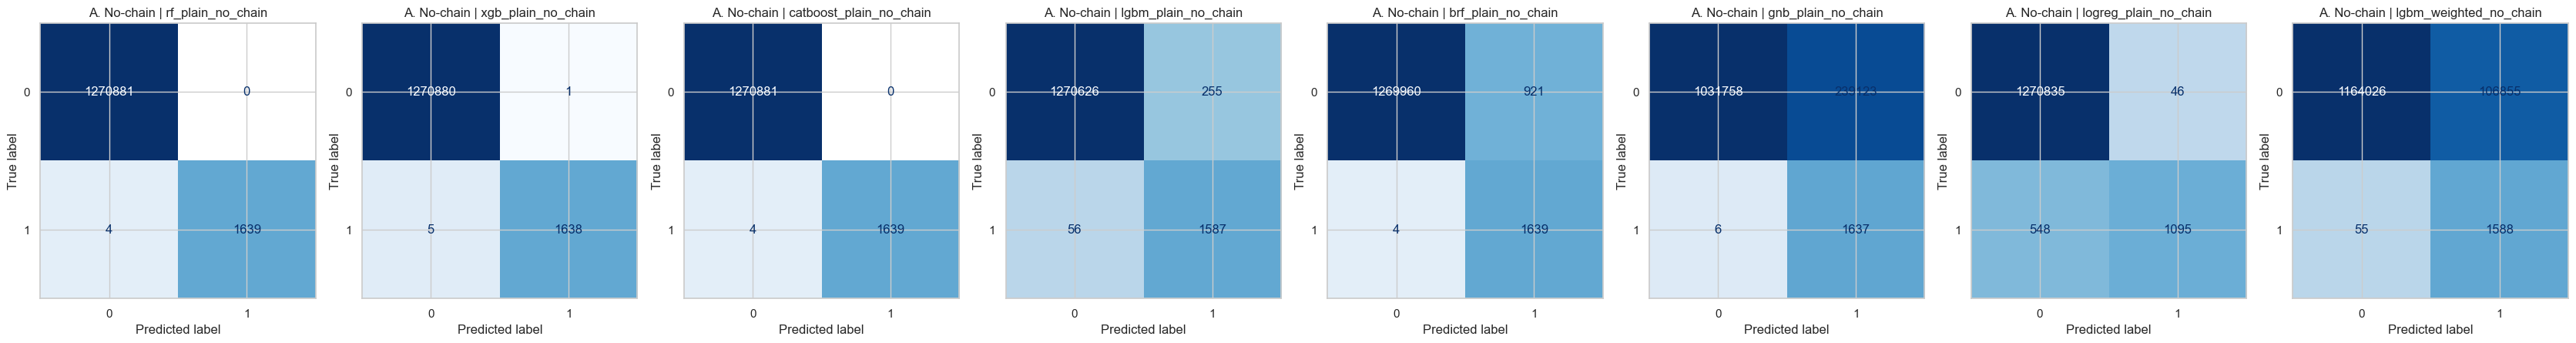

Part B: Chain-aware (selected models)


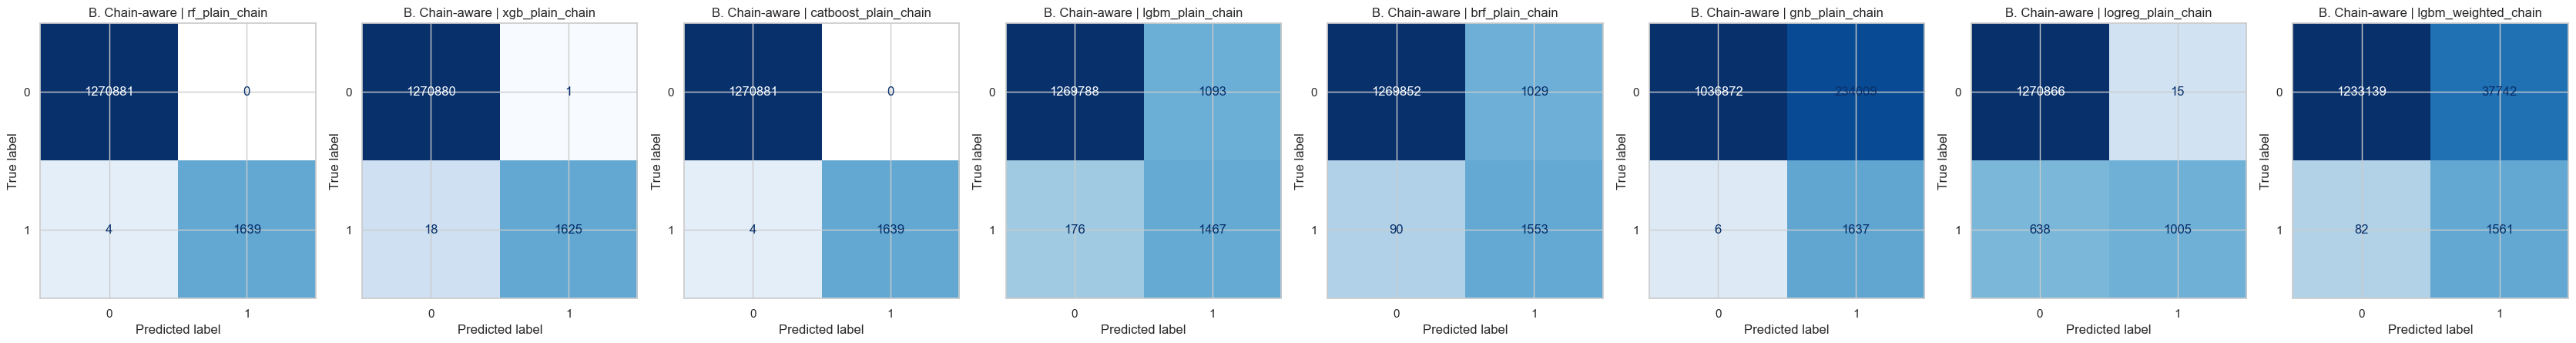

Part A (row-normalized): No-chain


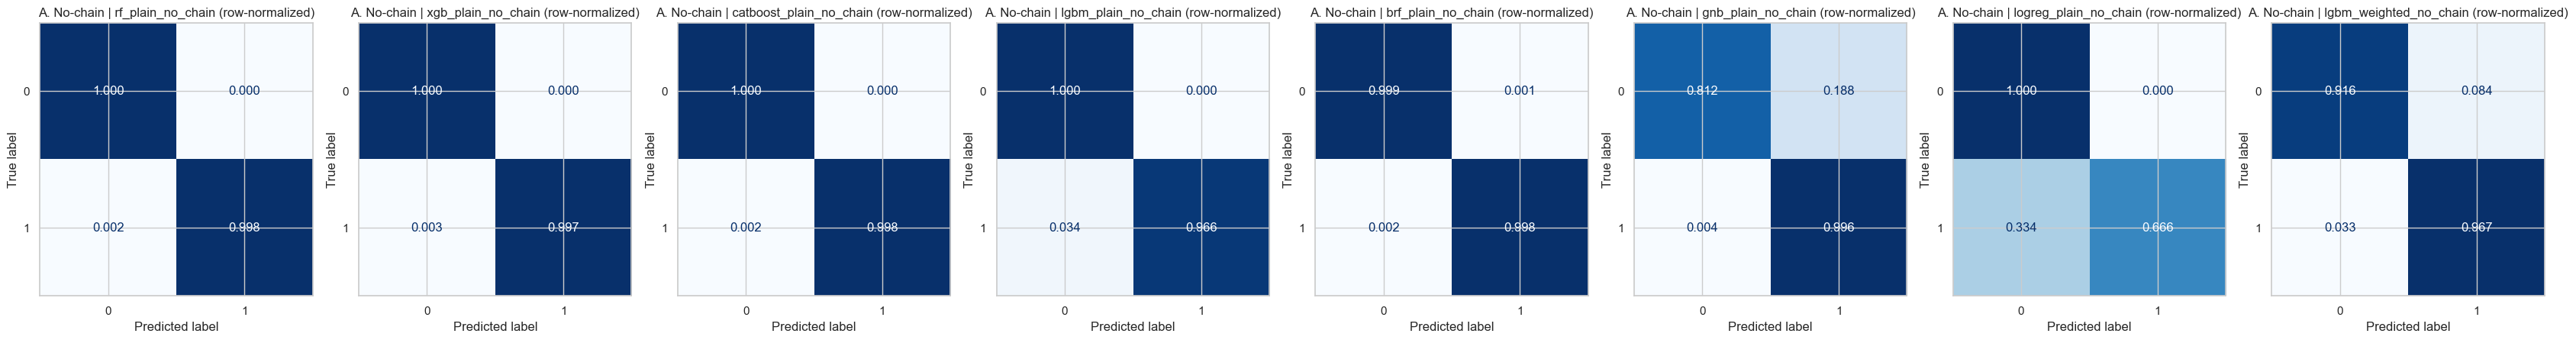

Part B (row-normalized): Chain-aware


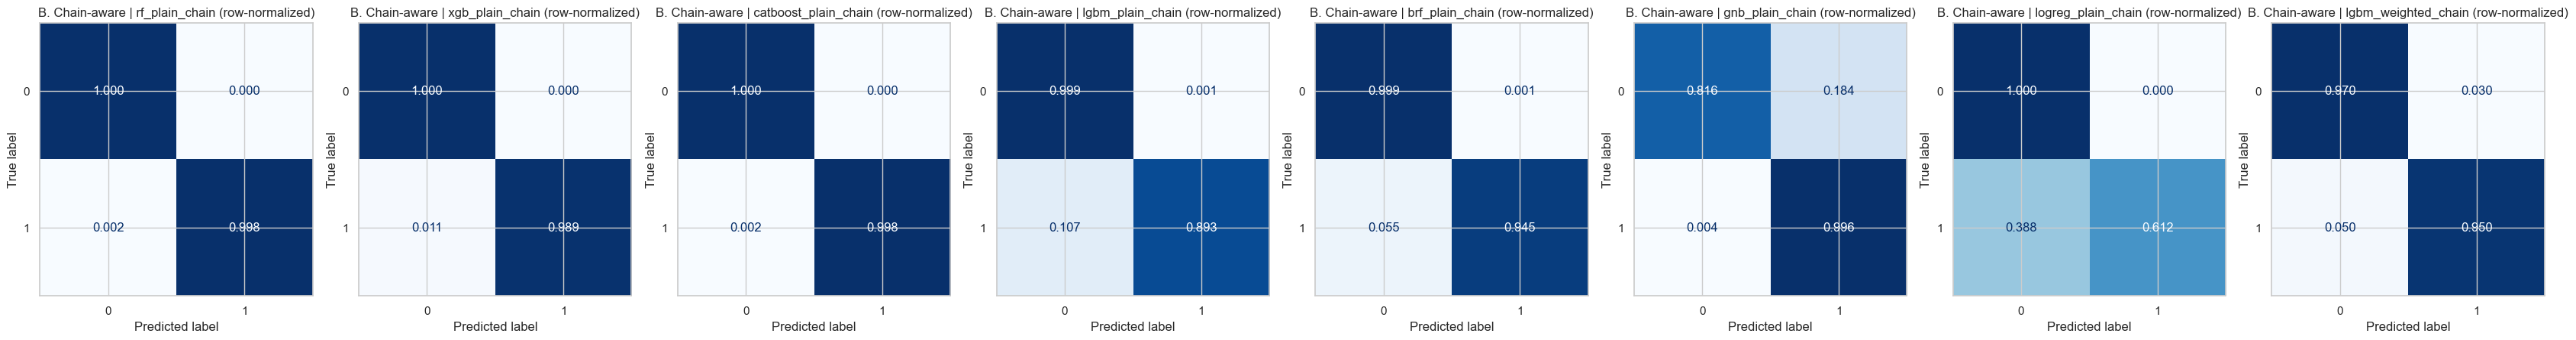

In [48]:
# Plot selected confusion matrices in two parts (A=no-chain, B=chain-aware).
from matplotlib.colors import LogNorm

# Use the same presentation set as the metric tables above.
selected_models = REPORT_EXPERIMENTS if "REPORT_EXPERIMENTS" in globals() else ["logreg_plain", "rf_plain", "xgb_plain"]

confusion_no_chain_sel = {k: confusion_no_chain[k] for k in selected_models if k in confusion_no_chain}
confusion_with_chain_sel = {k: confusion_with_chain[k] for k in selected_models if k in confusion_with_chain}

def plot_confusions_raw(confusion_dict, title_prefix, suffix):
    n = len(confusion_dict)
    fig, axes = plt.subplots(1, n, figsize=(4.2 * n, 4.2))
    axes = np.array(axes).ravel()
    for ax, exp_name in zip(axes, confusion_dict.keys()):
        cm = confusion_dict[exp_name]
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(
            ax=ax,
            cmap="Blues",
            colorbar=False,
            values_format="d",
            im_kw={"norm": LogNorm(vmin=1, vmax=max(1, cm.max()))},
        )
        ax.set_title(f"{title_prefix} | {exp_name}_{suffix}")
    plt.tight_layout()
    plt.show()

print("Part A: No-chain (selected models)")
plot_confusions_raw(confusion_no_chain_sel, "A. No-chain", "no_chain")
print("Part B: Chain-aware (selected models)")
plot_confusions_raw(confusion_with_chain_sel, "B. Chain-aware", "chain")

def plot_confusions_norm(confusion_dict, title_prefix, suffix):
    n = len(confusion_dict)
    fig, axes = plt.subplots(1, n, figsize=(4.2 * n, 4.2))
    axes = np.array(axes).ravel()
    for ax, exp_name in zip(axes, confusion_dict.keys()):
        cm = confusion_dict[exp_name]
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm)
        disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format=".3f")
        ax.set_title(f"{title_prefix} | {exp_name}_{suffix} (row-normalized)")
    plt.tight_layout()
    plt.show()

print("Part A (row-normalized): No-chain")
plot_confusions_norm(confusion_no_chain_sel, "A. No-chain", "no_chain")
print("Part B (row-normalized): Chain-aware")
plot_confusions_norm(confusion_with_chain_sel, "B. Chain-aware", "chain")


### 12.6 Setup-wise metric graphs (A vs B)

These graphs compare Recall, Precision, and PR-AUC for A (No-chain baseline) and B (Chain-aware).

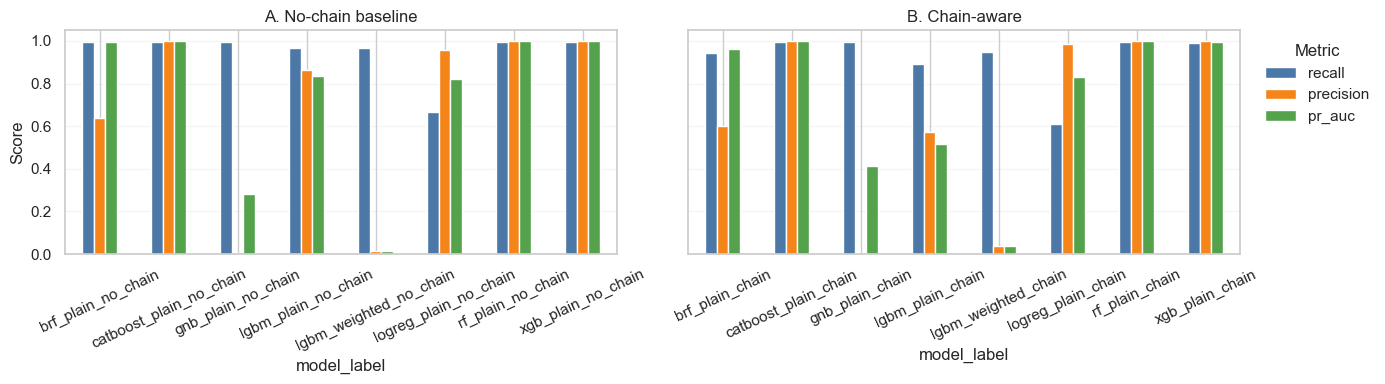

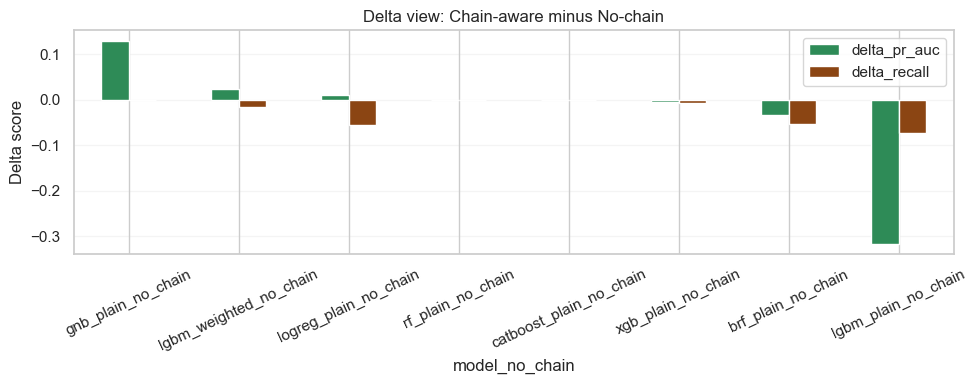

In [49]:
# Plot setup-wise bars for fraud-priority metrics and an explicit delta view.
focus_cols = ["recall", "precision", "pr_auc"]

report_models = REPORT_EXPERIMENTS if "REPORT_EXPERIMENTS" in globals() else ["logreg_plain", "rf_plain", "xgb_plain"]

metrics_no_chain_subset = metrics_no_chain[metrics_no_chain["experiment"].isin(report_models)].copy()
metrics_with_chain_subset = metrics_with_chain[metrics_with_chain["experiment"].isin(report_models)].copy()
chain_vs_no_chain_subset = chain_vs_no_chain_table[chain_vs_no_chain_table["experiment"].isin(report_models)].copy()

plot_no_chain = (
    metrics_no_chain_subset[["model_label"] + focus_cols]
    .set_index("model_label")
    .sort_index()
)
plot_with_chain = (
    metrics_with_chain_subset[["model_label"] + focus_cols]
    .set_index("model_label")
    .sort_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
plot_no_chain.plot(kind="bar", ax=axes[0], color=["#4C78A8", "#F58518", "#54A24B"])
axes[0].set_title("A. No-chain baseline")
axes[0].set_ylabel("Score")
axes[0].grid(axis="y", alpha=0.2)
axes[0].tick_params(axis="x", rotation=25)

plot_with_chain.plot(kind="bar", ax=axes[1], color=["#4C78A8", "#F58518", "#54A24B"])
axes[1].set_title("B. Chain-aware")
axes[1].grid(axis="y", alpha=0.2)
axes[1].tick_params(axis="x", rotation=25)
axes[1].legend(loc="upper left", bbox_to_anchor=(1.02, 1), frameon=False, title="Metric")
axes[0].legend().remove()
plt.tight_layout()
plt.show()

delta_plot = chain_vs_no_chain_subset.set_index("model_no_chain")[["delta_pr_auc", "delta_recall"]]
ax = delta_plot.plot(kind="bar", figsize=(10, 4), color=["#2E8B57", "#8B4513"])
ax.set_title("Delta view: Chain-aware minus No-chain")
ax.set_ylabel("Delta score")
ax.grid(axis="y", alpha=0.2)
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()


### 12.6b ROC and PR curves by setup

We plot ROC and Precision-Recall curves separately for A (No-chain) and B (Chain-aware) on the same test split.

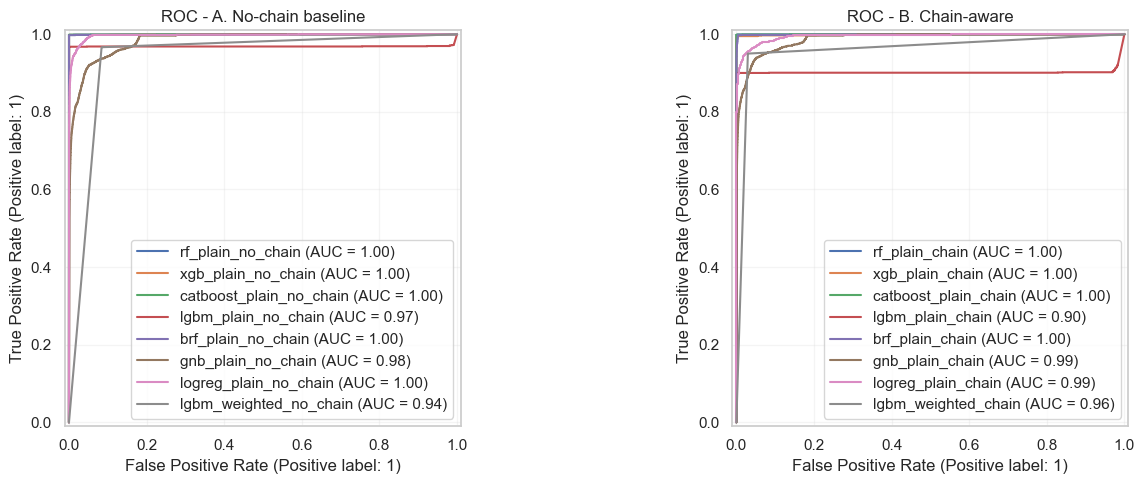

In [50]:
# Plot ROC curves separately for no-chain and chain-aware setups (presentation set only).
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
report_models = REPORT_EXPERIMENTS if "REPORT_EXPERIMENTS" in globals() else ["logreg_plain", "rf_plain", "xgb_plain"]

for exp_name in report_models:
    if exp_name in pred_store_no_chain:
        RocCurveDisplay.from_predictions(
            y_test,
            pred_store_no_chain[exp_name]["y_score"],
            ax=axes[0],
            name=f"{exp_name}_no_chain",
        )
axes[0].set_title("ROC - A. No-chain baseline")
axes[0].grid(alpha=0.2)

for exp_name in report_models:
    if exp_name in pred_store_with_chain:
        RocCurveDisplay.from_predictions(
            y_test,
            pred_store_with_chain[exp_name]["y_score"],
            ax=axes[1],
            name=f"{exp_name}_chain",
        )
axes[1].set_title("ROC - B. Chain-aware")
axes[1].grid(alpha=0.2)
plt.tight_layout()
plt.show()


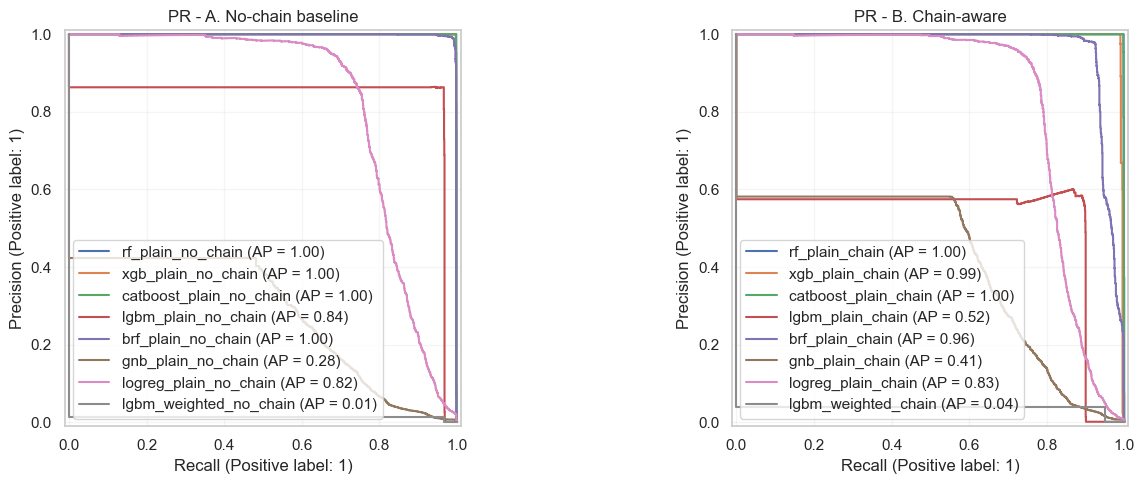

In [51]:
# Plot Precision-Recall curves separately for no-chain and chain-aware setups (presentation set only).
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
report_models = REPORT_EXPERIMENTS if "REPORT_EXPERIMENTS" in globals() else ["logreg_plain", "rf_plain", "xgb_plain"]

for exp_name in report_models:
    if exp_name in pred_store_no_chain:
        PrecisionRecallDisplay.from_predictions(
            y_test,
            pred_store_no_chain[exp_name]["y_score"],
            ax=axes[0],
            name=f"{exp_name}_no_chain",
        )
axes[0].set_title("PR - A. No-chain baseline")
axes[0].grid(alpha=0.2)

for exp_name in report_models:
    if exp_name in pred_store_with_chain:
        PrecisionRecallDisplay.from_predictions(
            y_test,
            pred_store_with_chain[exp_name]["y_score"],
            ax=axes[1],
            name=f"{exp_name}_chain",
        )
axes[1].set_title("PR - B. Chain-aware")
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()


### 12.6c Quick interpretation of A vs B

- If `delta_pr_auc` and `delta_recall` are mostly positive, chain context adds useful fraud signal.
- If deltas are near zero, baseline features already capture most separability.
- Compare logistic deltas first because linear models usually reveal incremental feature value more clearly.
- Keep both setups in report: A = baseline evidence, B = novel chain-aware evidence.

### 12.7 Short plain-language summary (which model works better)

This summary follows project priority: **Recall -> Precision -> PR-AUC -> Confusion matrix -> F1 -> ROC-AUC**.

It reports the best models **within the notebook presentation set** (controlled by `PRIMARY_EXPERIMENTS`, `SUPPORTING_EXPERIMENTS`, and `REPORT_EXPERIMENTS`). This keeps the discussion consistent with the A/B tables and plots shown above as models are added.

**Experiment ID glossary (avoids confusion):**
- Suffixes like **`*_plain`**, **`*_class_weight`**, **`*_smote`**, **`*_weighted`** describe the **imbalance / training recipe** for that model family. They do **not** mean “without chain features.”
- **Chain-aware vs not** is separate: chain context lives in the §12.4 feature matrix (`chain_size`, `is_chain_member`) and in A/B tables that compare chain vs no-chain *runs*. Unless a cell explicitly evaluates the no-chain grid, names such as `rf_plain` or `catboost_plain` here mean **plain imbalance recipe on the chain-aware pipeline** for that experiment.


In [52]:
# Print concise answers focused on the notebook presentation set.
tbl = comparison_table.copy()

# Presentation control (manual): show only what you want in the report.
report_models = globals().get("REPORT_EXPERIMENTS", ["logreg_plain", "rf_plain", "xgb_plain", "lgbm_plain"])
if "experiment" in tbl.columns:
    tbl = tbl[tbl["experiment"].isin(report_models)].copy()

def pick(metric):
    i = tbl[metric].idxmax()
    return tbl.loc[i, "experiment"], float(tbl.loc[i, metric])

best_recall = pick("recall")
best_precision = pick("precision")
best_pr_auc = pick("pr_auc")

def row(exp):
    m = tbl.loc[tbl["experiment"] == exp]
    if len(m) == 0:
        return None
    return m.iloc[0]

# Plain models (typically present in REPORT_EXPERIMENTS)
lr_p = row("logreg_plain")
rf_p = row("rf_plain")
xgb_p = row("xgb_plain")
lgbm_p = row("lgbm_plain")

# Optional variants (printed only if they are in the current REPORT_EXPERIMENTS)
lr_w = row("logreg_class_weight")
lr_s = row("logreg_smote")
rf_w = row("rf_class_weight")
rf_s = row("rf_smote")
lgbm_w = row("lgbm_weighted")

print("Naming note:")
print("  • *_plain / *_weighted / *_smote = imbalance strategy in the experiment id (not ‘no chain features’).")
print("  • Metrics below: chain-aware models on the held-out test split (comparison_table / metrics_with_chain).")
print()

print("Best recall (REPORT_EXPERIMENTS, chain-aware):", best_recall[0], f"({best_recall[1]:.4f})")
print("Best precision (REPORT_EXPERIMENTS, chain-aware):", best_precision[0], f"({best_precision[1]:.4f})")
print("Best PR-AUC (REPORT_EXPERIMENTS, chain-aware):", best_pr_auc[0], f"({best_pr_auc[1]:.4f})")
print()

# Optional variant comparisons (only if those experiments are included in REPORT_EXPERIMENTS)
if lr_w is not None and lr_p is not None and rf_w is not None and rf_p is not None:
    print("Did class weights improve recall over plain? (within current REPORT_EXPERIMENTS)")
    print("- Logistic Regression:", lr_w["recall"] > lr_p["recall"], "|", round(float(lr_p["recall"]),4), "->", round(float(lr_w["recall"]),4))
    print("- Random Forest:", rf_w["recall"] > rf_p["recall"], "|", round(float(rf_p["recall"]),4), "->", round(float(rf_w["recall"]),4))
else:
    print("Class-weight variants not included in this REPORT_EXPERIMENTS view.")

if lgbm_w is not None and lgbm_p is not None:
    print("- LightGBM weighted vs plain (precision check):", round(float(lgbm_w["precision"]),4), "vs", round(float(lgbm_p["precision"]),4))

if lr_s is not None and lr_p is not None and rf_s is not None and rf_p is not None:
    print()
    print("Did SMOTE improve recall over plain? (within current REPORT_EXPERIMENTS)")
    print("- Logistic Regression:", lr_s["recall"] > lr_p["recall"], "|", round(float(lr_p["recall"]),4), "->", round(float(lr_s["recall"]),4))
    print("- Random Forest:", rf_s["recall"] > rf_p["recall"], "|", round(float(rf_p["recall"]),4), "->", round(float(rf_s["recall"]),4))
else:
    print()
    print("SMOTE variants not included in this REPORT_EXPERIMENTS view.")

print()
if rf_p is not None and xgb_p is not None:
    print("XGBoost plain vs Random Forest plain (plain = imbalance recipe; both use chain-aware features + same test set):")
    print("- Recall:", "RF", round(float(rf_p["recall"]),4), "| XGB", round(float(xgb_p["recall"]),4), "| RF higher?", float(rf_p["recall"]) > float(xgb_p["recall"]))
    print("- Precision:", "RF", round(float(rf_p["precision"]),4), "| XGB", round(float(xgb_p["precision"]),4), "| RF higher?", float(rf_p["precision"]) > float(xgb_p["precision"]))
    print("- PR-AUC:", "RF", round(float(rf_p["pr_auc"]),4), "| XGB", round(float(xgb_p["pr_auc"]),4), "| RF higher?", float(rf_p["pr_auc"]) > float(xgb_p["pr_auc"]))

print()
print("Recommendation for next stage:")
print("- Keep primary models in finalist path (RF / XGB / LGBM / CatBoost plain imbalance variants on the chain-aware pipeline).")
print("- Keep weighted/SMOTE variants as supporting stress-test models unless they also win PR-AUC/precision.")
print("- Next, tune decision threshold using business cost of false negatives vs false positives.")


Naming note:
  • *_plain / *_weighted / *_smote = imbalance strategy in the experiment id (not ‘no chain features’).
  • Metrics below: chain-aware models on the held-out test split (comparison_table / metrics_with_chain).

Best recall (REPORT_EXPERIMENTS, chain-aware): catboost_plain (0.9976)
Best precision (REPORT_EXPERIMENTS, chain-aware): catboost_plain (1.0000)
Best PR-AUC (REPORT_EXPERIMENTS, chain-aware): catboost_plain (0.9986)

Class-weight variants not included in this REPORT_EXPERIMENTS view.
- LightGBM weighted vs plain (precision check): 0.0397 vs 0.573

SMOTE variants not included in this REPORT_EXPERIMENTS view.

XGBoost plain vs Random Forest plain (plain = imbalance recipe; both use chain-aware features + same test set):
- Recall: RF 0.9976 | XGB 0.989 | RF higher? True
- Precision: RF 1.0 | XGB 0.9994 | RF higher? True
- PR-AUC: RF 0.9985 | XGB 0.9937 | RF higher? True

Recommendation for next stage:
- Keep primary models in finalist path (RF / XGB / LGBM / CatBoost p

### 12.7a Pipeline umbrella: dynamic shortlist, finalist policy, and comparison plots

To keep this notebook reusable when new models are added, we use one transparent policy umbrella **before calibration (§12.8)**. The code cell below prints the shortlist, selects `CALIBRATION_FINALISTS`, then draws **three figures** for those finalists only: **rate metrics (grouped bars)**, **FP/FN counts**, and a **rate-metric heatmap** (all chain-aware, default 0.5 threshold). **§12.8** may still pick a different calibrated deploy key.

**Reminder:** experiment ids like `rf_plain` combine **model family + imbalance recipe** (`plain` vs weighted/SMOTE); they still refer to the **chain-aware** training matrix here—the §12.7 glossary applies.

What is dynamic:

- Build a shortlist table from available chain-aware experiments using score-based metrics from `y_score`.
- Rank models by project priority (**Recall**, **PR-AUC**, then **ROC-AUC**).
- Select calibration finalists automatically: always keep the top **2** by rank; add **3rd, 4th, …** only when each is close to the **leader** (rank-1) on PR-AUC and recall within explicit gaps, passes a precision floor, and under `MAX_FINALISTS` (default 6). If more models are “close” than the cap, raise `MAX_FINALISTS` or rely on rank order inside the cap.

What remains manual/governed:

- Final deployed model and business triage policy (kept explicit in later sections).
- Any policy threshold override must be documented in notebook text.


Score-based shortlist (chain-aware models; metrics derived from y_score)
Candidate pool: ['rf_plain', 'xgb_plain', 'catboost_plain', 'lgbm_plain', 'brf_plain', 'gnb_plain']


,experiment,model_label,recall,pr_auc,roc_auc,precision,f1,rank_recall,rank_pr_auc,rank_roc_auc
0,catboost_plain,catboost_plain_chain,0.9976,0.9986,0.9999,1.0000,0.9988,1,1,1
1,rf_plain,rf_plain_chain,0.9976,0.9985,0.9996,1.0000,0.9988,1,2,2
2,gnb_plain,gnb_plain_chain,0.9963,0.4125,0.9875,0.0069,0.0138,3,6,5
3,xgb_plain,xgb_plain_chain,0.9890,0.9937,0.9988,0.9994,0.9942,4,3,4
4,brf_plain,brf_plain_chain,0.9452,0.9631,0.9993,0.6015,0.7351,5,4,3
5,lgbm_plain,lgbm_plain_chain,0.8929,0.5185,0.9017,0.5730,0.6981,6,5,6


Selected finalists for calibration: ['catboost_plain', 'rf_plain', 'xgb_plain']
Selection reason: Included 3 finalists: mandatory top-2 by rank, plus 1 extra(s) close to leader `catboost_plain` (PR-AUC gap <= 0.01, Recall gap <= 0.01, precision >= 0.02). Extras: ['xgb_plain'].
Policy thresholds: {'MIN_FINALISTS': 2, 'MAX_FINALISTS': 6, 'THRESH_PR_AUC_GAP': 0.01, 'THRESH_RECALL_GAP': 0.01, 'MIN_PRECISION_FOR_EXTRA_FINALIST': 0.02}
§12.7a visuals — lexicographic leader among PRIMARY_EXPERIMENTS (pr_auc↓ recall↓ precision↓): catboost_plain
§12.7a visuals — models plotted (CALIBRATION_FINALISTS when set): ['catboost_plain', 'rf_plain', 'xgb_plain']


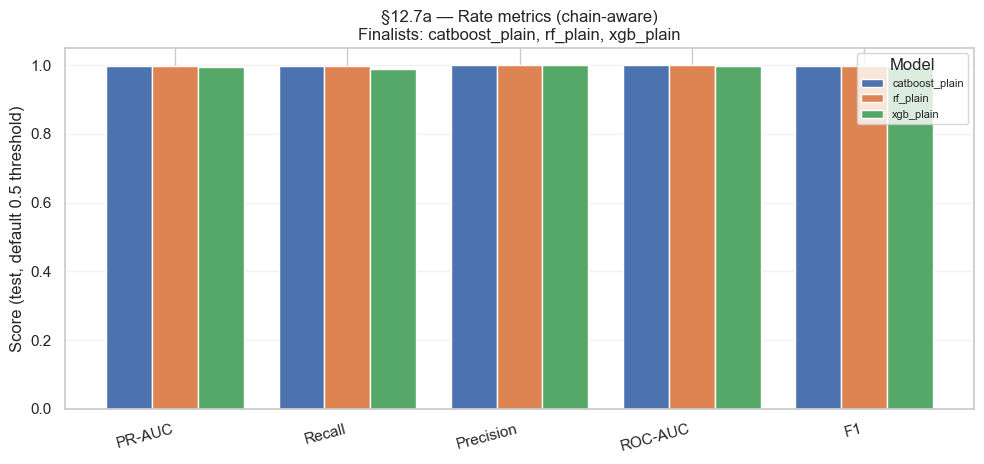

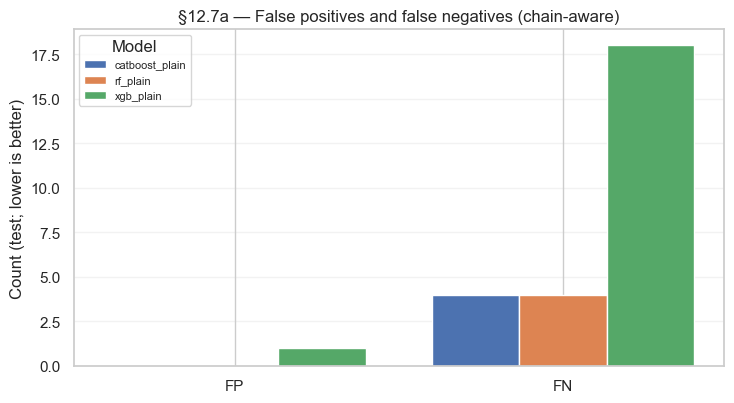

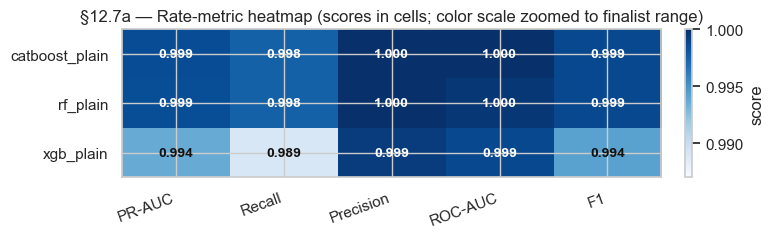

In [53]:
# Dynamic shortlist + calibration finalist selection policy.

from IPython.display import display
import pandas as pd

required = ["metrics_with_chain"]
missing = [n for n in required if n not in globals()]
if missing:
    raise ValueError("Run Section 12.4 first. Missing: " + ", ".join(missing))

shortlist_cols = ["experiment", "model_label", "recall", "pr_auc", "roc_auc", "precision", "f1"]
shortlist_tbl = metrics_with_chain.copy()

# Finalist selection should prioritize primary models by default.
if "PRIMARY_EXPERIMENTS" in globals() and "experiment" in shortlist_tbl.columns:
    candidate_pool = PRIMARY_EXPERIMENTS
elif "REPORT_EXPERIMENTS" in globals() and "experiment" in shortlist_tbl.columns:
    candidate_pool = REPORT_EXPERIMENTS
else:
    candidate_pool = shortlist_tbl["experiment"].tolist()

shortlist_tbl = shortlist_tbl[shortlist_tbl["experiment"].isin(candidate_pool)].copy()
shortlist_tbl = shortlist_tbl[shortlist_cols].sort_values(
    ["recall", "pr_auc", "roc_auc"], ascending=False
).reset_index(drop=True)

for m in ["recall", "pr_auc", "roc_auc"]:
    shortlist_tbl[f"rank_{m}"] = shortlist_tbl[m].rank(ascending=False, method="min").astype(int)

print("Score-based shortlist (chain-aware models; metrics derived from y_score)")
print("Candidate pool:", candidate_pool)
display(shortlist_tbl)

# ---- dynamic finalist policy -------------------------------------------------
# Always keep top MIN_FINALISTS by rank (default 2).
# Add rank-3, rank-4, ... only while: (a) close to the *leader* on PR-AUC and recall,
# (b) precision floor for extras, (c) under MAX_FINALISTS (cap avoids huge calibration runtime).
MIN_FINALISTS = 2
MAX_FINALISTS = 6
THRESH_PR_AUC_GAP = 0.01
THRESH_RECALL_GAP = 0.01
MIN_PRECISION_FOR_EXTRA_FINALIST = 0.02

ranked = shortlist_tbl.sort_values(["rank_recall", "rank_pr_auc", "rank_roc_auc"]).reset_index(drop=True)


def _close_to_leader(row, leader_row):
    pr_ok = abs(float(row["pr_auc"]) - float(leader_row["pr_auc"])) <= THRESH_PR_AUC_GAP
    rec_ok = abs(float(row["recall"]) - float(leader_row["recall"])) <= THRESH_RECALL_GAP
    return pr_ok and rec_ok


leader = ranked.iloc[0]
chosen, seen = [], set()
extras_added = []

for i in range(len(ranked)):
    if len(chosen) >= MAX_FINALISTS:
        break
    row = ranked.iloc[i]
    exp = str(row["experiment"])
    if i < MIN_FINALISTS:
        chosen.append(exp)
        seen.add(exp)
        continue
    if _close_to_leader(row, leader) and float(row["precision"]) >= MIN_PRECISION_FOR_EXTRA_FINALIST:
        if exp not in seen:
            chosen.append(exp)
            seen.add(exp)
            extras_added.append(exp)

truncated_note = ""
if extras_added:
    calibration_policy_reason = (
        f"Included {len(chosen)} finalists: mandatory top-{MIN_FINALISTS} by rank, "
        f"plus {len(extras_added)} extra(s) close to leader `{leader['experiment']}` "
        f"(PR-AUC gap <= {THRESH_PR_AUC_GAP}, Recall gap <= {THRESH_RECALL_GAP}, precision >= {MIN_PRECISION_FOR_EXTRA_FINALIST}). "
        f"Extras: {extras_added}."
    )
else:
    calibration_policy_reason = (
        f"No model beyond rank-{MIN_FINALISTS} was simultaneously close enough to leader `{leader['experiment']}` "
        f"and above the precision floor; calibrating top-{MIN_FINALISTS} only."
    )

if len(chosen) == MAX_FINALISTS and len(ranked) > len(chosen):
    still_close = []
    for j in range(len(chosen), len(ranked)):
        r = ranked.iloc[j]
        if _close_to_leader(r, leader) and float(r["precision"]) >= MIN_PRECISION_FOR_EXTRA_FINALIST:
            still_close.append(str(r["experiment"]))
    if still_close:
        truncated_note = (
            f" Note: hit MAX_FINALISTS={MAX_FINALISTS}; also-close models not included: {still_close}. "
            "Raise MAX_FINALISTS if you want them calibrated too."
        )
        calibration_policy_reason += truncated_note

CALIBRATION_FINALISTS = chosen

print("Selected finalists for calibration:", CALIBRATION_FINALISTS)
print("Selection reason:", calibration_policy_reason)
print(
    "Policy thresholds:",
    {
        "MIN_FINALISTS": MIN_FINALISTS,
        "MAX_FINALISTS": MAX_FINALISTS,
        "THRESH_PR_AUC_GAP": THRESH_PR_AUC_GAP,
        "THRESH_RECALL_GAP": THRESH_RECALL_GAP,
        "MIN_PRECISION_FOR_EXTRA_FINALIST": MIN_PRECISION_FOR_EXTRA_FINALIST,
    },
)


# --- §12.7a figures: calibration finalists on chain-aware test (default 0.5 threshold) ---
import numpy as np
import matplotlib.pyplot as plt

if "PRIMARY_EXPERIMENTS" in globals() and isinstance(PRIMARY_EXPERIMENTS, list) and len(PRIMARY_EXPERIMENTS) > 0:
    _pool_v = PRIMARY_EXPERIMENTS
else:
    _pool_v = ["rf_plain", "xgb_plain"]

_sub_all = metrics_with_chain[metrics_with_chain["experiment"].isin(_pool_v)].copy()
if _sub_all["experiment"].nunique() < 2:
    raise ValueError("Need at least two primary models in metrics_with_chain for §12.7a visuals.")

_lex_leader = _sub_all.sort_values(["pr_auc", "recall", "precision"], ascending=False).iloc[0]
lex_leader_exp = str(_lex_leader["experiment"])

if "CALIBRATION_FINALISTS" in globals() and isinstance(CALIBRATION_FINALISTS, list) and len(CALIBRATION_FINALISTS) > 0:
    focus_list_v = [m for m in CALIBRATION_FINALISTS if m in set(_sub_all["experiment"].astype(str))]
else:
    focus_list_v = (
        _sub_all.sort_values(["pr_auc", "recall", "precision"], ascending=False)["experiment"]
        .astype(str)
        .tolist()[:3]
    )

if len(focus_list_v) < 2:
    focus_list_v = _sub_all.sort_values(["pr_auc", "recall", "precision"], ascending=False)["experiment"].astype(str).tolist()

_sub_f = _sub_all[_sub_all["experiment"].isin(focus_list_v)].copy()
_sub_f = _sub_f.sort_values(["pr_auc", "recall", "precision"], ascending=False).reset_index(drop=True)
_models_v = _sub_f["experiment"].astype(str).tolist()

_rate_cols = ["pr_auc", "recall", "precision", "roc_auc", "f1"]
_rate_labels = ["PR-AUC", "Recall", "Precision", "ROC-AUC", "F1"]

print("§12.7a visuals — lexicographic leader among PRIMARY_EXPERIMENTS (pr_auc↓ recall↓ precision↓):", lex_leader_exp)
print("§12.7a visuals — models plotted (CALIBRATION_FINALISTS when set):", _models_v)

# Visual 1: rate metrics (grouped bars)
fig1, ax1 = plt.subplots(figsize=(10, 4.8))
x = np.arange(len(_rate_labels))
n_m = len(_models_v)
bar_w = min(0.8 / max(n_m, 1), 0.28)
for i, m in enumerate(_models_v):
    vals = [float(_sub_f.loc[_sub_f["experiment"] == m, c].iloc[0]) for c in _rate_cols]
    offset = (i - (n_m - 1) / 2) * bar_w
    ax1.bar(x + offset, vals, bar_w, label=m)
ax1.set_xticks(x)
ax1.set_xticklabels(_rate_labels, rotation=15, ha="right")
ax1.set_ylim(0, 1.05)
ax1.set_ylabel("Score (test, default 0.5 threshold)")
ax1.set_title("§12.7a — Rate metrics (chain-aware)\nFinalists: " + ", ".join(_models_v))
ax1.legend(title="Model", fontsize=8)
ax1.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

# Visual 2: FP / FN (grouped bars)
fig2, ax2 = plt.subplots(figsize=(7.5, 4.2))
count_labels = ["FP", "FN"]
x2 = np.arange(len(count_labels))
for i, m in enumerate(_models_v):
    vals = [
        float(_sub_f.loc[_sub_f["experiment"] == m, "fp"].iloc[0]),
        float(_sub_f.loc[_sub_f["experiment"] == m, "fn"].iloc[0]),
    ]
    offset = (i - (n_m - 1) / 2) * bar_w
    ax2.bar(x2 + offset, vals, bar_w, label=m)
ax2.set_xticks(x2)
ax2.set_xticklabels(count_labels)
ax2.set_ylabel("Count (test; lower is better)")
ax2.set_title("§12.7a — False positives and false negatives (chain-aware)")
ax2.legend(title="Model", fontsize=8)
ax2.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

# Visual 3: heatmap (models × rate metrics) — text color adapts to cell luminance; scale zooms to data.
_mat = _sub_f.set_index("experiment")[_rate_cols].reindex(_models_v)
_hvals = np.asarray(_mat.values, dtype=np.float64)
_spread = float(np.nanmax(_hvals) - np.nanmin(_hvals))
_pad = max(0.002, min(0.02, 0.15 * _spread if _spread > 0 else 0.01))
_vmin_h = max(0.0, float(np.nanmin(_hvals)) - _pad)
_vmax_h = min(1.0, float(np.nanmax(_hvals)) + _pad)
fig3, ax3 = plt.subplots(figsize=(8, max(2.0, 0.45 * len(_models_v) + 1.2)), num="paysim_127a_heatmap")
_cmap_h = plt.colormaps.get_cmap("Blues")
_norm_h = plt.Normalize(vmin=_vmin_h, vmax=_vmax_h)
im = ax3.imshow(_hvals, aspect="auto", cmap=_cmap_h, norm=_norm_h)
ax3.set_xticks(np.arange(len(_rate_labels)))
ax3.set_xticklabels(_rate_labels, rotation=20, ha="right")
ax3.set_yticks(np.arange(len(_models_v)))
ax3.set_yticklabels(list(_mat.index))
for yi in range(len(_models_v)):
    for xi in range(len(_rate_cols)):
        v = _hvals[yi, xi]
        r, g, b, _a = _cmap_h(_norm_h(v))
        _lum = 0.2126 * r + 0.7152 * g + 0.0722 * b
        _tc = "white" if _lum < 0.55 else "#111111"
        ax3.text(
            xi,
            yi,
            f"{v:.3f}",
            ha="center",
            va="center",
            color=_tc,
            fontsize=10,
            fontweight="semibold",
        )
ax3.set_title("§12.7a — Rate-metric heatmap (scores in cells; color scale zoomed to finalist range)")
fig3.colorbar(im, ax=ax3, fraction=0.046, pad=0.04, label="score")
plt.tight_layout()
plt.show()


**How to read the three §12.7a figures (chain-aware test, default 0.5 threshold)**

**Who is in these plots?** The finalist set is the list printed just **above** as `Selected finalists for calibration:` (variable **`CALIBRATION_FINALISTS`**). The same names appear in the **figure title, legend, and y-axis**—use that as the source of truth for *which* models you are comparing; the count is usually **2–6** depending on the §12.7a policy, not always three.

**How the three views work together (human read):** On this dataset, **Figure 1** often does **not** show a dramatic “winner”—when PR-AUC / recall / precision are all crowding the top of the scale, the bar chart is doing a **sanity check** (“all finalists are strong on ranking-style scores at 0.5”) more than a crisp ranking. The **real decision signal** for “who is *safer* *at this fixed threshold*” usually shows up in **Figure 2 (FP vs FN)**: two models can look tied on AUC while one quietly trades more missed fraud (FN) for fewer false alerts (FP), or the opposite. **Figure 3** does not introduce new metrics; it repackages the same 0–1 rates in a **compact grid** with a color scale zoomed to the finalist range, which makes **small gaps** and **row-to-row patterns** easier to spot than a wall of nearly flat bars in Figure 1.

- **Figure 1 (grouped bars, rate metrics):** PR-AUC, recall, precision, ROC-AUC, and F1. When bars all sit near **1.0**, treat this as a **coarse** view; lean on the shortlist **table** above and **Figure 3** for nuance.
- **Figure 2 (FP / FN):** Usually the **most policy-relevant** panel *at 0.5*—it surfaces **operational** error mix (missed fraud vs false blocks) that ranking metrics can hide.
- **Figure 3 (heatmap):** Same metrics as Figure 1, **side-by-side** in one glance—best for spotting **relative** strengths/weaknesses across finalists once Figure 1 feels flat.

**Caveat:** This is still **one threshold (0.5)** on **one test split**. **§12.8** calibration and later **cost-based thresholds / triage** can change which model you actually deploy; treat §12.7a as a **pre-calibration** comparison of the printed finalist set.


### 12.8 Probability calibration (dynamic finalists from §12.7a policy)

This section calibrates **`CALIBRATION_FINALISTS`** from **§12.7a** (same models as the §12.7a figures if you run in order).

- **Policy:** at least **2** chain-aware finalists; extras only when **close to the leader** (gaps + precision floor in §12.7a), capped by `MAX_FINALISTS`.

**Per finalist:** uncalibrated test **p** from the **§12.4**-fitted base model, then **`CalibratedClassifierCV`** with **sigmoid** and **isotonic** (`clone(base)`; `cv=CALIBRATION_CV` fits on train only; scores on the **held-out** test set).

**Outputs:** Brier, ROC-AUC, PR-AUC, reliability plots, and **`FINAL_MODEL_KEY` / `FINAL_MODEL_REASON`** (optional prefer-family policy in code). Default **`CALIBRATION_CV = 2`**.

**After this code runs (no extra section):** use the printed **`FINAL_MODEL_KEY`** for **§12.9a → §12.9b** and for **artifact export** (`final_model_key` in `feature_metadata.json` + `calibration_model_file_map`) — that is what **`app.py` loads**, not a hard-coded old RF name. **SHAP in §12.10** still uses the **`rf_plain`** tree for `TreeExplainer` only. **Streamlit / tabs:** **§18** only.


Calibration finalists used: ['catboost_plain', 'rf_plain', 'xgb_plain']
Selection reason: Included 3 finalists: mandatory top-2 by rank, plus 1 extra(s) close to leader `catboost_plain` (PR-AUC gap <= 0.01, Recall gap <= 0.01, precision >= 0.02). Extras: ['xgb_plain'].


,model,brier,roc_auc,pr_auc
0,catboost_plain_uncalibrated,0.00000326,0.999905,0.998554
1,catboost_plain_sigmoid,0.00000314,0.999905,0.998554
2,catboost_plain_isotonic,0.00000319,0.999851,0.998447
3,rf_plain_uncalibrated,0.00000746,0.999645,0.998508
4,rf_plain_sigmoid,0.00000328,0.999645,0.998508
5,rf_plain_isotonic,0.00000334,0.999646,0.998239
6,xgb_plain_uncalibrated,0.00001428,0.998754,0.993653
7,xgb_plain_sigmoid,0.00001486,0.998754,0.993653
8,xgb_plain_isotonic,0.00001440,0.998300,0.993112


Note: Brier values are very small in this dataset, so 8 decimals are shown.


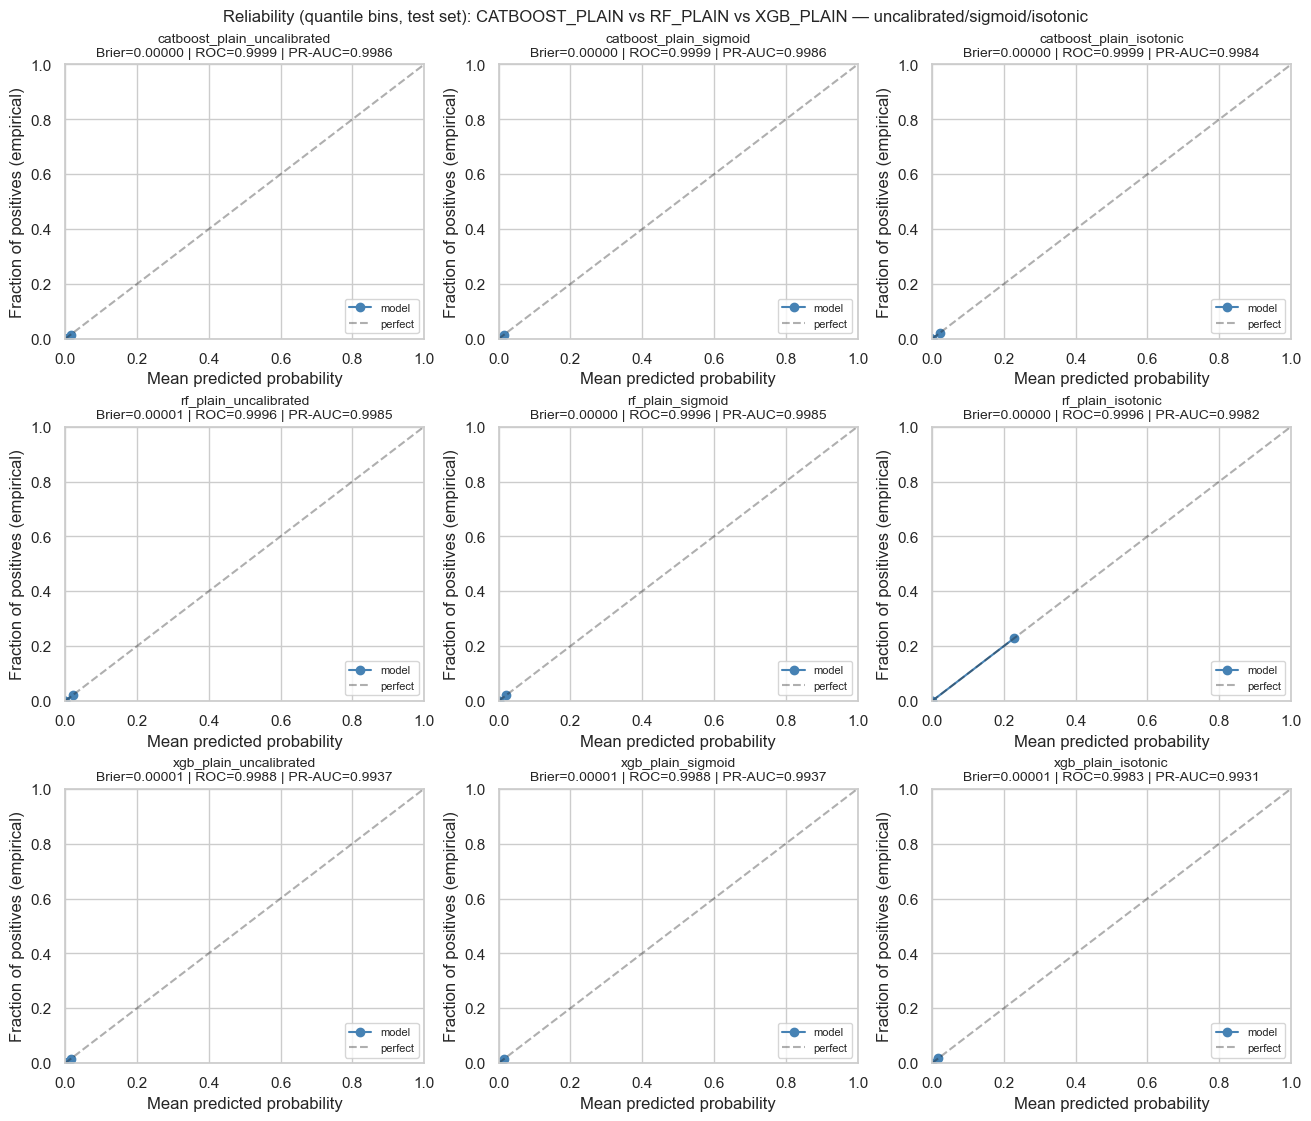

Calibration ranking (lower Brier first, then lower reliability-diagonal gap):
  catboost_plain_sigmoid            Brier=0.00000314  diag_gap=0.000008
  catboost_plain_isotonic           Brier=0.00000319  diag_gap=0.000006
  catboost_plain_uncalibrated       Brier=0.00000326  diag_gap=0.000002
  rf_plain_sigmoid                  Brier=0.00000328  diag_gap=0.000018
  rf_plain_isotonic                 Brier=0.00000334  diag_gap=0.000059
  rf_plain_uncalibrated             Brier=0.00000746  diag_gap=0.000117
  xgb_plain_uncalibrated            Brier=0.00001428  diag_gap=0.000008
  xgb_plain_isotonic                Brier=0.00001440  diag_gap=0.000039
  xgb_plain_sigmoid                 Brier=0.00001486  diag_gap=0.000022

BEST_OVERALL_MODEL_KEY: catboost_plain_sigmoid
FINAL_MODEL_KEY: catboost_plain_sigmoid
FINAL_MODEL_REASON: Selected catboost_plain_sigmoid dynamically across finalists using lowest Brier (tol=1e-07), then highest PR-AUC, then highest ROC-AUC.
Recommended for threshold tuni

In [54]:
# Dynamic calibration for finalists selected in 12.7a.

from IPython.display import display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss, roc_auc_score, average_precision_score

CALIBRATION_CV = 2

required = [
    "Xte_ch",
    "y_test",
    "y_train",
    "experiments_with_chain",
    "pred_store_with_chain",
]
missing = [n for n in required if n not in globals()]
if missing:
    raise ValueError("Run Section 12.4 first. Missing globals: " + ", ".join(missing))

if "CALIBRATION_FINALISTS" in globals() and isinstance(CALIBRATION_FINALISTS, list) and len(CALIBRATION_FINALISTS) > 0:
    finalists = [m for m in CALIBRATION_FINALISTS if m in experiments_with_chain and m in pred_store_with_chain]
else:
    _fb_pool = list(globals().get("PRIMARY_EXPERIMENTS", ["rf_plain", "xgb_plain"]))
    finalists = [m for m in _fb_pool if m in experiments_with_chain and m in pred_store_with_chain]

if len(finalists) < 2:
    raise ValueError("Need at least 2 valid finalists for calibration. Check Section 12.7a output.")

print("Calibration finalists used:", finalists)
if "calibration_policy_reason" in globals():
    print("Selection reason:", calibration_policy_reason)


def _metrics(y_true, proba_pos):
    return {
        "brier": float(brier_score_loss(y_true, proba_pos)),
        "roc_auc": float(roc_auc_score(y_true, proba_pos)),
        "pr_auc": float(average_precision_score(y_true, proba_pos)),
    }


def _reliability_ax(ax, y_true, proba_pos, title, n_bins=12):
    prob_true, prob_pred = calibration_curve(y_true, proba_pos, n_bins=n_bins, strategy="quantile")
    ax.plot(prob_pred, prob_true, "o-", color="steelblue", label="model")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.35, label="perfect")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction of positives (empirical)")
    ax.set_title(title, fontsize=10)
    ax.legend(loc="lower right", fontsize=8)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)


def _diag_mae(y_true, p, n_bins=12):
    prob_true, prob_pred = calibration_curve(y_true, p, n_bins=n_bins, strategy="quantile")
    return float(np.mean(np.abs(prob_true - prob_pred)))


rows = []
probs_by_model = {}
NOTEBOOK_RF_CALIBRATORS_FOR_STREAMLIT = {}
plot_slots = []
desired_order = []

for row_idx, exp_name in enumerate(finalists):
    cfg = experiments_with_chain[exp_name]
    train_X, train_y = cfg["train_X"], cfg["train_y"]
    base_fitted = cfg["model"]

    p_unc = pred_store_with_chain[exp_name]["y_score"].astype(np.float64)
    lab_unc = f"{exp_name}_uncalibrated"
    m_unc = _metrics(y_test, p_unc)
    rows.append({"model": lab_unc, **m_unc})
    probs_by_model[lab_unc] = p_unc
    plot_slots.append((row_idx * 3 + 0, lab_unc, p_unc, m_unc))
    desired_order.append(lab_unc)

    for j, method in enumerate(["sigmoid", "isotonic"], start=1):
        cal = CalibratedClassifierCV(
            estimator=clone(base_fitted),
            method=method,
            cv=CALIBRATION_CV,
            n_jobs=1,
            ensemble=False,
        )
        cal.fit(train_X, train_y)
        p_cal = cal.predict_proba(Xte_ch)[:, 1].astype(np.float64)
        lab = f"{exp_name}_{method}"
        m = _metrics(y_test, p_cal)
        rows.append({"model": lab, **m})
        probs_by_model[lab] = p_cal
        NOTEBOOK_RF_CALIBRATORS_FOR_STREAMLIT[lab] = cal
        plot_slots.append((row_idx * 3 + j, lab, p_cal, m))
        desired_order.append(lab)

calibration_comparison_table = pd.DataFrame(rows).set_index("model").loc[desired_order].reset_index()

calibration_display_table = calibration_comparison_table.copy()
calibration_display_table["brier"] = calibration_display_table["brier"].map(lambda x: f"{x:.8f}")
calibration_display_table["roc_auc"] = calibration_display_table["roc_auc"].map(lambda x: f"{x:.6f}")
calibration_display_table["pr_auc"] = calibration_display_table["pr_auc"].map(lambda x: f"{x:.6f}")
display(calibration_display_table)
print("Note: Brier values are very small in this dataset, so 8 decimals are shown.")

n_models = len(finalists)
fig, axes = plt.subplots(n_models, 3, figsize=(13, 3.7 * n_models), constrained_layout=True)
axes = np.atleast_1d(axes).ravel()

for ax_idx, lab, probs, mdict in plot_slots:
    _reliability_ax(
        axes[ax_idx],
        y_test,
        probs,
        title=f"{lab}\nBrier={mdict['brier']:.5f} | ROC={mdict['roc_auc']:.4f} | PR-AUC={mdict['pr_auc']:.4f}",
    )

plt.suptitle(
    f"Reliability (quantile bins, test set): {' vs '.join([m.upper() for m in finalists])} — uncalibrated/sigmoid/isotonic",
    fontsize=12,
)
plt.show()

ranked = []
for lab in desired_order:
    p = probs_by_model[lab]
    b = float(calibration_comparison_table.set_index("model").loc[lab, "brier"])
    d = _diag_mae(y_test, p)
    ranked.append((b, d, lab))
ranked.sort(key=lambda t: (t[0], t[1]))
print("Calibration ranking (lower Brier first, then lower reliability-diagonal gap):")
for b, d, lab in ranked:
    print(f"  {lab:32s}  Brier={b:.8f}  diag_gap={d:.6f}")


def select_final_calibrated_model(calibration_comparison_table, finalists, brier_close_tol=1e-7, prefer_rf_for_compat=True):
    tbl = calibration_comparison_table.copy().reset_index(drop=True)
    finalist_prefixes = tuple(f"{exp}_" for exp in finalists)
    candidate_tbl = tbl[tbl["model"].str.startswith(finalist_prefixes)].copy()
    if candidate_tbl.empty:
        raise ValueError("No calibration rows found for finalists.")

    min_brier = float(candidate_tbl["brier"].min())
    close_tbl = candidate_tbl[candidate_tbl["brier"] <= min_brier + float(brier_close_tol)].copy()
    close_tbl = close_tbl.sort_values(["pr_auc", "roc_auc"], ascending=[False, False]).reset_index(drop=True)

    best_overall = str(close_tbl.iloc[0]["model"])

    if prefer_rf_for_compat and "rf_plain" in finalists:
        rf_rows = close_tbl[close_tbl["model"].str.startswith("rf_plain_")].copy()
        if not rf_rows.empty:
            final_row = rf_rows.sort_values(["pr_auc", "roc_auc"], ascending=[False, False]).iloc[0]
            final_key = str(final_row["model"])
            final_reason = (
                f"Best overall calibration row: {best_overall}. "
                f"Deployment key set to {final_key} (RF-preferred compatibility policy enabled). "
                f"Selection used lowest Brier (tol={brier_close_tol:g}), then highest PR-AUC, then highest ROC-AUC."
            )
            return final_key, final_reason, best_overall

    final_row = close_tbl.iloc[0]
    final_key = str(final_row["model"])
    final_reason = (
        f"Selected {final_key} dynamically across finalists using lowest Brier (tol={brier_close_tol:g}), "
        f"then highest PR-AUC, then highest ROC-AUC."
    )
    return final_key, final_reason, best_overall


COMPAT_PREFER_RF_FOR_DEPLOYMENT = False
FINAL_MODEL_KEY, FINAL_MODEL_REASON, BEST_OVERALL_MODEL_KEY = select_final_calibrated_model(
    calibration_comparison_table,
    finalists=finalists,
    brier_close_tol=1e-7,
    prefer_rf_for_compat=COMPAT_PREFER_RF_FOR_DEPLOYMENT,
)
best = FINAL_MODEL_KEY

print()
print("BEST_OVERALL_MODEL_KEY:", BEST_OVERALL_MODEL_KEY)
print("FINAL_MODEL_KEY:", FINAL_MODEL_KEY)
print("FINAL_MODEL_REASON:", FINAL_MODEL_REASON)
print("Recommended for threshold tuning, triage, artifact export (calibrated key):", FINAL_MODEL_KEY)
print("SHAP baseline in §12.10 remains chain-aware rf_plain unless you change the explainer.")


### 12.9a Bootstrap confidence interval (PR-AUC)

Bootstrap resamples the **held-out** test set to get a **95% CI** for PR-AUC of **`probs_by_model[FINAL_MODEL_KEY]`** (key set in **§12.8**). The **exact key** appears in cell output (`Final model for CI:`), not in static markdown 


Final model for CI: catboost_plain_sigmoid
Full test PR-AUC: 0.998554
Bootstrap PR-AUC mean: 0.998520
95% CI: [0.996327, 0.999950]
Valid bootstrap runs used: 300 / 300


,model,metric,point_estimate,bootstrap_mean,ci_lower,ci_upper,n_boot_valid
0,catboost_plain_sigmoid,PR-AUC,0.9986,0.9985,0.9963,1.0000,300


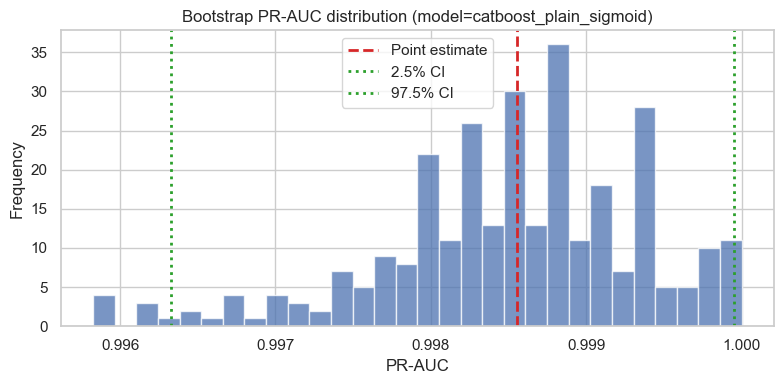

In [55]:
# Bootstrap PR-AUC confidence interval for the final deployed choice

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score

# Helper: bootstrap PR-AUC on the untouched test set
# Returns point estimate, bootstrap mean, 95% CI, and the number of valid bootstrap runs.

def bootstrap_pr_auc_ci(y_true, y_score, n_boot=300, random_state=42):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(np.float64)

    if y_true.shape[0] != y_score.shape[0]:
        raise ValueError("y_true and y_score must have the same length")

    n = len(y_true)
    rng = np.random.default_rng(random_state)

    point_estimate = float(average_precision_score(y_true, y_score))

    boot_scores = []
    for _ in range(int(n_boot)):
        idx = rng.integers(0, n, size=n, endpoint=False)
        yb = y_true[idx]
        # Skip degenerate bootstrap samples where only one class is present.
        if np.unique(yb).size < 2:
            continue
        s = float(average_precision_score(yb, y_score[idx]))
        boot_scores.append(s)

    if len(boot_scores) == 0:
        raise ValueError("All bootstrap samples were degenerate (only one class).")

    boot_scores = np.asarray(boot_scores, dtype=np.float64)
    bootstrap_mean = float(np.mean(boot_scores))
    ci_lower = float(np.percentile(boot_scores, 2.5))
    ci_upper = float(np.percentile(boot_scores, 97.5))

    return point_estimate, bootstrap_mean, ci_lower, ci_upper, int(len(boot_scores))


# -----------------
# Identify final model probabilities (must match what Section 12.9b uses)
# -----------------
if "probs_by_model" not in globals():
    raise ValueError("Run calibration Section 12.8 first. Missing `probs_by_model`.")
if "y_test" not in globals():
    raise ValueError("Missing `y_test`. Run earlier evaluation sections first.")

# Deployed calibrated key set in Section 12.8 (FINAL_MODEL_KEY); artifact path via feature_metadata calibration_model_file_map.
if "FINAL_MODEL_KEY" not in globals():
    raise ValueError("FINAL_MODEL_KEY missing. Re-run calibration section 12.8.")

deployed_prob_key = FINAL_MODEL_KEY

# Pick the notebook final probability vector.
if deployed_prob_key in probs_by_model:
    final_prob_key = deployed_prob_key
else:
    raise ValueError("Could not find FINAL_MODEL_KEY in `probs_by_model`. Re-run calibration section to define FINAL_MODEL_KEY.")

if final_prob_key != deployed_prob_key:
    print(
        f"Warning: confirm final probability source before reporting CI. "
        f"Notebook CI key={final_prob_key} vs deployed key={deployed_prob_key}."
    )

# Use existing untouched test labels and calibrated probabilities.
y_true = np.asarray(y_test).astype(int)
y_score = np.asarray(probs_by_model[final_prob_key], dtype=np.float64)

# Compute bootstrap CI
point_estimate, boot_mean, ci_lower, ci_upper, n_valid = bootstrap_pr_auc_ci(
    y_true=y_true,
    y_score=y_score,
    n_boot=300,
    random_state=42,
)

# Print results
print(f"Final model for CI: {final_prob_key}")
print(f"Full test PR-AUC: {point_estimate:.6f}")
print(f"Bootstrap PR-AUC mean: {boot_mean:.6f}")
print(f"95% CI: [{ci_lower:.6f}, {ci_upper:.6f}]")
print(f"Valid bootstrap runs used: {n_valid} / 300")

# Summary table
ci_df = pd.DataFrame([
    {
        "model": final_prob_key,
        "metric": "PR-AUC",
        "point_estimate": point_estimate,
        "bootstrap_mean": boot_mean,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
        "n_boot_valid": n_valid,
    }
])

display(ci_df)

# Plot bootstrap distribution
# We recompute bootstrap PR-AUC values here so the histogram uses the same valid bootstrap samples.
# (The CI calculation above uses the same random_state, so this is deterministic.)

def _bootstrap_scores_for_hist(y_true, y_score, n_boot=300, random_state=42):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(np.float64)

    n = len(y_true)
    rng = np.random.default_rng(random_state)
    scores = []
    for _ in range(int(n_boot)):
        idx = rng.integers(0, n, size=n, endpoint=False)
        yb = y_true[idx]
        # Skip degenerate bootstrap samples where only one class is present.
        if np.unique(yb).size < 2:
            continue
        scores.append(float(average_precision_score(yb, y_score[idx])))
    return np.asarray(scores, dtype=np.float64)

boot_scores_for_hist = _bootstrap_scores_for_hist(y_true, y_score, n_boot=300, random_state=42)

plt.figure(figsize=(8, 4))
plt.hist(boot_scores_for_hist, bins=30, alpha=0.75)
plt.axvline(point_estimate, color="#d62728", linestyle="--", linewidth=2, label="Point estimate")
plt.axvline(ci_lower, color="#2ca02c", linestyle=":", linewidth=2, label="2.5% CI")
plt.axvline(ci_upper, color="#2ca02c", linestyle=":", linewidth=2, label="97.5% CI")
plt.title(f"Bootstrap PR-AUC distribution (model={final_prob_key})")
plt.xlabel("PR-AUC")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()


**Discussion: interpreting the PR-AUC bootstrap confidence interval**

The CI is computed from repeated bootstrap resamples of the *same untouched test split*. It measures how much the measured PR-AUC could vary due to sampling variability (for whichever calibrated key **`FINAL_MODEL_KEY`** pointed to when you ran the §12.9a code cell).

- **Narrow CI**: your final model’s PR-AUC is relatively stable on the held-out test set.
- **Wide CI**: PR-AUC is sensitive to which rows are sampled; treat the performance as less certain.

Note: bootstrap runs that contain only one class are skipped automatically, so the CI uses only valid (non-degenerate) resamples.

**Markdown vs output:** this discussion is generic. The **exact** deployment key and numeric CI appear only in **§12.9a cell output** after execution—not in static markdown.


### 12.9b Cost-sensitive thresholds and triage (`FINAL_MODEL_KEY`)

Uses **`FINAL_MODEL_KEY`** probabilities on the chain-aware test set (same row order as §12.4).

**Does:** (1) threshold search **0.05–0.95** (step 0.05) with `cost_fp=5`, `cost_fn=500`; (2) min-cost operating threshold; (3) **GREEN / YELLOW / RED**; (4) chain escalation to **RED** when appropriate.

**Bucket rules (match code):** `GREEN` if score `< review_threshold`; `YELLOW` if between review and block; `RED` if `>= block_threshold` (plus escalation rule).

**Export:** the same code path ends with **§12.9c** — writes `artifacts/*.joblib`, `feature_metadata.json`, and may refresh `MODEL_CARD` (run with **project root** as cwd). **App:** **§18**.


,threshold,precision,recall,f1,tn,fp,fn,tp,total_cost
0,0.0500,1.0000,0.9976,0.9988,1270881,0,4,1639,2000
1,0.1000,1.0000,0.9976,0.9988,1270881,0,4,1639,2000
2,0.1500,1.0000,0.9976,0.9988,1270881,0,4,1639,2000
3,0.2000,1.0000,0.9976,0.9988,1270881,0,4,1639,2000
4,0.2500,1.0000,0.9976,0.9988,1270881,0,4,1639,2000
5,0.3000,1.0000,0.9976,0.9988,1270881,0,4,1639,2000
6,0.3500,1.0000,0.9976,0.9988,1270881,0,4,1639,2000
7,0.4000,1.0000,0.9976,0.9988,1270881,0,4,1639,2000
8,0.4500,1.0000,0.9976,0.9988,1270881,0,4,1639,2000
9,0.5000,1.0000,0.9976,0.9988,1270881,0,4,1639,2000


Chosen operating threshold (min cost): 0.05
At this threshold -> total_cost=2000, precision=1.0000, recall=0.9976, f1=0.9988
Triage thresholds -> GREEN < 0.05, YELLOW [0.05, 0.15), RED >= 0.15


,bucket,count,frauds,fraud_rate_pct
0,GREEN,1270885,4,0.0003
1,YELLOW,0,0,0.0000
2,RED,1639,1639,100.0000


,view,red_count,red_frauds,fraud_capture_in_red_pct
0,Before escalation,1639,1639,99.7565
1,After escalation,1639,1639,99.7565


Chain escalation impact:
- Additional rows escalated to RED: 0
- True frauds among escalated rows: 0
- Fraud capture in RED (before -> after): 
99.76% -> 99.76%


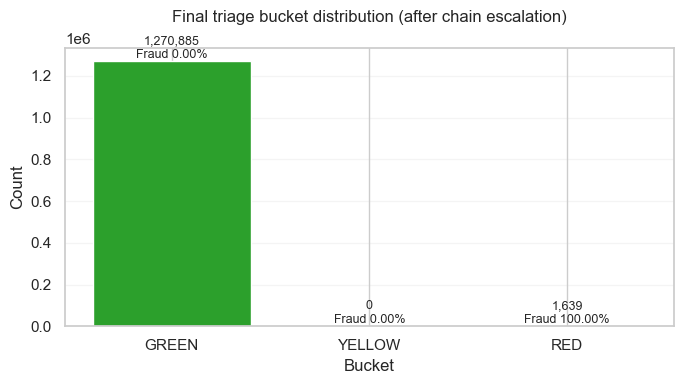

Loaded calibrated estimator for FINAL_MODEL_KEY='catboost_plain_sigmoid' from catboost_plain_sigmoid_calibrated.joblib
Streamlit artifact dir updated: /Users/snehasingh/ML/PaySim-Fraud-Triage/artifacts
Restart Streamlit to reload cached artifact load.


In [56]:
# Tune cost-sensitive threshold and build triage buckets using FINAL_MODEL_KEY calibrated scores.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

required = ["probs_by_model", "y_test", "X_test"]
missing = [n for n in required if n not in globals()]
if missing:
    raise ValueError("Run 12.4 and 12.8 first. Missing: " + ", ".join(missing))

if "FINAL_MODEL_KEY" not in globals():
    raise ValueError("FINAL_MODEL_KEY missing. Re-run Section 12.8 calibration.")
if FINAL_MODEL_KEY not in probs_by_model:
    raise ValueError(f"{FINAL_MODEL_KEY} probabilities not found. Re-run 12.8 calibration cell.")

# --- fixed business cost setup ---
cost_fp = 5
cost_fn = 500
threshold_grid = np.arange(0.05, 0.951, 0.05)

y_true = np.asarray(y_test).astype(int)
y_score = np.asarray(probs_by_model[FINAL_MODEL_KEY], dtype=np.float64)

# --- threshold search table ---
rows = []
for thr in threshold_grid:
    y_pred = (y_score >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    total_cost = fp * cost_fp + fn * cost_fn
    rows.append({
        "threshold": float(thr),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "total_cost": int(total_cost),
    })

threshold_search_table = pd.DataFrame(rows)
display(threshold_search_table)

# Choose operating threshold by minimum total cost; tie-break by higher recall then precision.
operating_row = threshold_search_table.sort_values(
    ["total_cost", "recall", "precision"], ascending=[True, False, False]
).iloc[0]
operating_threshold = float(operating_row["threshold"])
print(f"Chosen operating threshold (min cost): {operating_threshold:.2f}")
print(
    f"At this threshold -> total_cost={int(operating_row['total_cost'])}, "
    f"precision={operating_row['precision']:.4f}, recall={operating_row['recall']:.4f}, f1={operating_row['f1']:.4f}"
)

# --- triage buckets from calibrated probabilities ---
review_threshold = max(0.05, round(operating_threshold - 0.10, 2))
block_threshold = min(0.95, round(operating_threshold + 0.10, 2))
moderate_cutoff = review_threshold

base_bucket = np.where(
    y_score < review_threshold,
    "GREEN",
    np.where(y_score < block_threshold, "YELLOW", "RED")
)

# --- chain escalation rule ---
if "is_chain_member" not in X_test.columns:
    raise ValueError("X_test must contain is_chain_member for escalation rule.")

is_chain_member_test = X_test["is_chain_member"].to_numpy().astype(int)
escalate_mask = (
    (base_bucket != "RED")
    & (is_chain_member_test == 1)
    & (y_score >= moderate_cutoff)
)
final_bucket = base_bucket.copy()
final_bucket[escalate_mask] = "RED"

# --- bucket table (final policy) ---
# Always include GREEN, YELLOW, RED in order, even when one bucket has zero rows.
triage_bucket_table = (
    pd.DataFrame({"bucket": final_bucket, "isFraud": y_true})
    .groupby("bucket", as_index=False)
    .agg(count=("isFraud", "size"), frauds=("isFraud", "sum"))
    .set_index("bucket")
    .reindex(["GREEN", "YELLOW", "RED"], fill_value=0)
    .reset_index()
)
triage_bucket_table["fraud_rate_pct"] = np.where(
    triage_bucket_table["count"] > 0,
    triage_bucket_table["frauds"] / triage_bucket_table["count"] * 100,
    0.0,
)
print(
    f"Triage thresholds -> GREEN < {review_threshold:.2f}, "
    f"YELLOW [{review_threshold:.2f}, {block_threshold:.2f}), RED >= {block_threshold:.2f}"
)
display(triage_bucket_table)

# --- escalation impact report ---
additional_escalated = int(escalate_mask.sum())
escalated_true_frauds = int(((y_true == 1) & escalate_mask).sum())

before_red_frauds = int(((y_true == 1) & (base_bucket == "RED")).sum())
after_red_frauds = int(((y_true == 1) & (final_bucket == "RED")).sum())
total_frauds = int((y_true == 1).sum())

fraud_capture_before_pct = 100 * before_red_frauds / max(total_frauds, 1)
fraud_capture_after_pct = 100 * after_red_frauds / max(total_frauds, 1)

triage_summary_table = pd.DataFrame([
    {
        "view": "Before escalation",
        "red_count": int((base_bucket == "RED").sum()),
        "red_frauds": before_red_frauds,
        "fraud_capture_in_red_pct": fraud_capture_before_pct,
    },
    {
        "view": "After escalation",
        "red_count": int((final_bucket == "RED").sum()),
        "red_frauds": after_red_frauds,
        "fraud_capture_in_red_pct": fraud_capture_after_pct,
    },
])
display(triage_summary_table)

print("Chain escalation impact:")
print(f"- Additional rows escalated to RED: {additional_escalated:,}")
print(f"- True frauds among escalated rows: {escalated_true_frauds:,}")
print(
    "- Fraud capture in RED (before -> after): \n"
    f"{fraud_capture_before_pct:.2f}% -> {fraud_capture_after_pct:.2f}%"
)

# --- simple final triage distribution chart ---
plot_df = triage_bucket_table.copy()
fig, ax = plt.subplots(figsize=(7, 4))
colors = {"GREEN": "#2ca02c", "YELLOW": "#ffbf00", "RED": "#d62728"}
ax.bar(plot_df["bucket"].astype(str), plot_df["count"], color=[colors[b] for b in plot_df["bucket"].astype(str)])
ax.set_title("Final triage bucket distribution (after chain escalation)\n")
ax.set_xlabel("Bucket")
ax.set_ylabel("Count")
ax.grid(axis="y", alpha=0.2)
for i, r in plot_df.iterrows():
    ax.text(i, r["count"], f"{int(r['count']):,}\nFraud {r['fraud_rate_pct']:.2f}%", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

# --- Sync Streamlit artifacts + feature_metadata + MODEL_CARD §7–§8 (run Jupyter with cwd = project root) ---
from pathlib import Path

import streamlit_notebook_export as sexp

_boot = None
_req = ("point_estimate", "boot_mean", "ci_lower", "ci_upper", "n_valid")
if all(k in globals() for k in _req):
    _boot = {
        "pr_auc_point": float(point_estimate),
        "pr_auc_bootstrap_mean": float(boot_mean),
        "ci_lower": float(ci_lower),
        "ci_upper": float(ci_upper),
        "valid_runs": int(n_valid),
        "n_boot_requested": 300,
    }

# Resolve SHAP base model from FINAL_MODEL_KEY so Streamlit uses the same model family.
def _base_exp_key(key):
    for _s in ("_sigmoid", "_isotonic", "_uncalibrated"):
        if key.endswith(_s):
            return key[:-len(_s)]
    return key

_shap_exp = _base_exp_key(FINAL_MODEL_KEY)
_shap_base_model = (
    experiments_with_chain[_shap_exp]["model"]
    if _shap_exp in experiments_with_chain
    else experiments_with_chain["rf_plain"]["model"]
)

_out = sexp.sync_from_notebook_session(
    preprocessor=preprocessor,
    rf_base_model=_shap_base_model,
    x_train_columns=list(X_train.columns),
    processed_feature_names=list(preprocessor.get_feature_names_out()),
    final_model_key=FINAL_MODEL_KEY,
    final_model_reason=FINAL_MODEL_REASON,
    calibration_comparison_table=calibration_comparison_table,
    rf_calibrator_by_key=NOTEBOOK_RF_CALIBRATORS_FOR_STREAMLIT,
    triage_thresholds={
        "operating_threshold": float(operating_threshold),
        "review_threshold": float(review_threshold),
        "block_threshold": float(block_threshold),
        "moderate_cutoff": float(moderate_cutoff),
    },
    chain_size_cap=int(globals().get("CHAIN_SIZE_CAP", 12)),
    y_true=y_true,
    final_bucket_labels=final_bucket,
    base_bucket_labels=base_bucket,
    bootstrap_prauc=_boot,
    cost_fp=cost_fp,
    cost_fn=cost_fn,
    project_root=Path.cwd(),
    rewrite_model_card=True,
)

import json
import joblib

_meta = json.loads((_out / "feature_metadata.json").read_text(encoding="utf-8"))
_mfm = _meta.get("calibration_model_file_map") or {}
_fname = _mfm.get(str(FINAL_MODEL_KEY))
if not _fname:
    _fname = "rf_selected_calibrated.joblib"  # canonical alias written by export
_cal_path = _out / _fname
if not _cal_path.is_file():
    _cal_path = _out / "rf_selected_calibrated.joblib"
best_calibrated_model = joblib.load(_cal_path)
print(
    f"Loaded calibrated estimator for FINAL_MODEL_KEY={FINAL_MODEL_KEY!r} from {_cal_path.name}"
)

print("Streamlit artifact dir updated:", _out)
print("Restart Streamlit to reload cached artifact load.")


### 12.10 SHAP (global + local)

### Why two model names show up (not two deploy models):

| Role | What it is | Used for |
|---|---|---|
| **`FINAL_MODEL_KEY` (from §12.8)** | **Final calibrated deploy scorer** — CatBoost, XGB, RF, or whichever model won calibration | **Fraud probability `p`**, triage bucket text, and tables beside each SHAP example (`probs_by_model[FINAL_MODEL_KEY]`, `final_bucket`). This is the **“final model” for decisions**. |
| **Base model of `FINAL_MODEL_KEY`** | **Matching uncalibrated model from the same family** — for example, `catboost_plain` when `FINAL_MODEL_KEY = catboost_plain_sigmoid` | **TreeExplainer only** — SHAP summary / waterfall describe this base model’s feature pushes on the **same §12.4 processed matrix**. This keeps explanation and scoring in the **same model family**. |

So the **final operational model** for scoring is **`FINAL_MODEL_KEY`**. The SHAP explainer uses the **base model of the same family**, so we can explain feature contributions while keeping deployment and explanation aligned.

**Parts:** (1) global summary on the **base model of `FINAL_MODEL_KEY`**; (2) local rows labeling **high vs low risk** using **`FINAL_MODEL_KEY` probabilities**, with SHAP bars coming from the matching **base model**. SHAP ≠ causality.

**App:** same split — deploy **`final_model_key`** for scoring vs SHAP on the matching **base model** — **§18**.


SHAP explains catboost_plain feature contributions; calibrated catboost_plain_sigmoid probabilities used for triage context.
Note: processed_value is from the processed/scaled feature matrix (not raw original units).


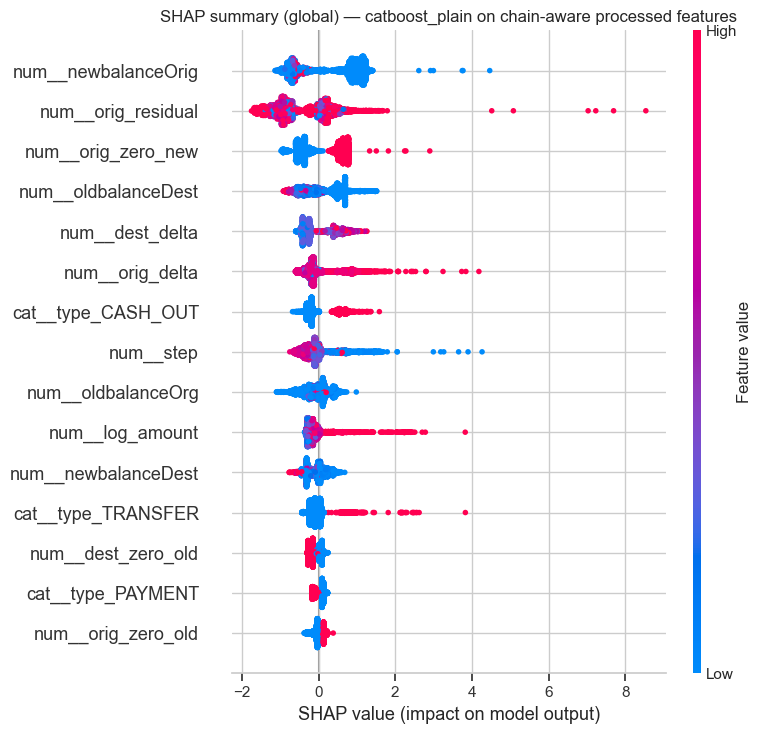

Local example metadata:


,example,test_row_position,true_label,calibrated_probability,final_triage_bucket
0,high_risk_fraud,40117,1,0.9997,RED
1,low_risk_legit,983897,0,0.0000,GREEN



Top contributing features for high_risk_fraud (test_row_position 40117):


,feature,shap_value,abs_shap,processed_value
0,num__is_chain_member,8.3389,8.3389,30.8173
1,num__orig_residual,4.9900,4.9900,0.3323
2,num__log_amount,2.8530,2.8530,2.1063
3,num__newbalanceOrig,1.8138,1.8138,-0.2925
4,cat__type_TRANSFER,1.6808,1.6808,1.0000
5,num__orig_delta,1.6594,1.6594,16.0648
6,num__orig_zero_new,0.9886,0.9886,0.8733
7,num__oldbalanceOrg,0.7983,0.7983,0.5195



Top contributing features for low_risk_legit (test_row_position 983897):


,feature,shap_value,abs_shap,processed_value
0,num__newbalanceOrig,-0.8479,0.8479,-0.2220
1,num__oldbalanceDest,-0.5635,0.5635,1.3306
2,num__oldbalanceOrg,-0.4880,0.4880,-0.2715
3,num__orig_zero_new,-0.4442,0.4442,-1.1451
4,num__newbalanceDest,-0.4331,0.4331,1.1554
5,num__dest_delta,-0.4202,0.4202,-0.3459
6,num__orig_delta,-0.3888,0.3888,-0.9204
7,num__log_amount,-0.2908,0.2908,0.6159



Interpretation (chain-feature visibility):
- Chain-aware features are not in the top 15 global SHAP drivers in this run; the model relies more on other transaction/balance/type features.
- Type one-hot columns and balance-based numeric features remain key explainability anchors.


In [57]:
# Compute global and local SHAP explanations for the deployed model (FINAL_MODEL_KEY), while reporting calibrated outputs.
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# If needed, install first: pip install shap
# If SHAP is missing in your environment, run: pip install shap
try:
    import shap
except ImportError as e:
    raise ImportError("SHAP is not installed. Run: pip install shap") from e

required = [
    "experiments_with_chain", "Xte_ch", "y_test", "preprocessor",
    "probs_by_model", "final_bucket"
]
missing = [n for n in required if n not in globals()]
if missing:
    raise ValueError("Run 12.4, 12.8, and 12.9b first. Missing: " + ", ".join(missing))

if FINAL_MODEL_KEY not in probs_by_model:
    raise ValueError(f"{FINAL_MODEL_KEY} calibrated probabilities not found. Re-run 12.8.")

# Resolve SHAP explainer to the same model family as FINAL_MODEL_KEY.
# e.g. "catboost_plain_sigmoid" -> "catboost_plain"; "rf_plain_isotonic" -> "rf_plain"
def _base_exp(key):
    for suffix in ("_sigmoid", "_isotonic", "_uncalibrated"):
        if key.endswith(suffix):
            return key[:-len(suffix)]
    return key

shap_exp_name = _base_exp(FINAL_MODEL_KEY)
if shap_exp_name in experiments_with_chain:
    shap_base_model = experiments_with_chain[shap_exp_name]["model"]
    shap_model_label = shap_exp_name
elif "rf_plain" in experiments_with_chain:
    shap_base_model = experiments_with_chain["rf_plain"]["model"]
    shap_model_label = "rf_plain (fallback)"
    print(f"WARNING: {shap_exp_name} not in experiments_with_chain; falling back to rf_plain for SHAP")
else:
    raise ValueError("Neither FINAL_MODEL_KEY base nor rf_plain found in experiments_with_chain.")

print(f"SHAP explains {shap_model_label} feature contributions; calibrated {FINAL_MODEL_KEY} probabilities used for triage context.")
print("Note: processed_value is from the processed/scaled feature matrix (not raw original units).")
rf_base_model = shap_base_model
X_test_chain = np.asarray(Xte_ch, dtype=np.float64)
y_true = np.asarray(y_test).astype(int)
calibrated_probs = np.asarray(probs_by_model[FINAL_MODEL_KEY], dtype=np.float64)
triage_bucket = np.asarray(final_bucket).astype(str)

# Use fitted feature names from the actual chain-aware preprocessing pipeline.
proc_feature_names = list(preprocessor.get_feature_names_out())

if len(proc_feature_names) != X_test_chain.shape[1]:
    raise ValueError(
        f"Feature-name length mismatch: {len(proc_feature_names)} names vs {X_test_chain.shape[1]} columns."
    )

X_test_chain_df = pd.DataFrame(X_test_chain, columns=proc_feature_names)

# ------------------------
# Part 1: Global SHAP
# ------------------------
SHAP_SAMPLE_N = 5000
rng = np.random.default_rng(42)
if len(X_test_chain_df) > SHAP_SAMPLE_N:
    sample_idx = np.sort(rng.choice(len(X_test_chain_df), size=SHAP_SAMPLE_N, replace=False))
else:
    sample_idx = np.arange(len(X_test_chain_df))

X_shap_sample = X_test_chain_df.iloc[sample_idx]
explainer = shap.TreeExplainer(rf_base_model)
shap_values_raw = explainer.shap_values(X_shap_sample)

# Handle SHAP output format across versions.
if isinstance(shap_values_raw, list):
    shap_values_sample = shap_values_raw[1]
elif isinstance(shap_values_raw, np.ndarray) and shap_values_raw.ndim == 3:
    shap_values_sample = shap_values_raw[:, :, 1]
else:
    shap_values_sample = shap_values_raw

plt.figure(figsize=(11, 6))
shap.summary_plot(
    shap_values_sample,
    X_shap_sample,
    feature_names=proc_feature_names,
    max_display=15,
    show=False,
)
plt.title(f"SHAP summary (global) — {shap_model_label} on chain-aware processed features")
plt.tight_layout()
plt.show()

# ------------------------
# Part 2: Local SHAP
# ------------------------
fraud_mask = y_true == 1
legit_mask = y_true == 0

if fraud_mask.sum() == 0 or legit_mask.sum() == 0:
    raise ValueError("Need both fraud and legitimate rows in y_test for local examples.")

high_risk_fraud_idx = np.where(fraud_mask)[0][np.argmax(calibrated_probs[fraud_mask])]
low_risk_legit_idx = np.where(legit_mask)[0][np.argmin(calibrated_probs[legit_mask])]
local_indices = [int(high_risk_fraud_idx), int(low_risk_legit_idx)]
local_labels = ["high_risk_fraud", "low_risk_legit"]

X_local = X_test_chain_df.iloc[local_indices]
shap_local_raw = explainer.shap_values(X_local)
if isinstance(shap_local_raw, list):
    shap_local = shap_local_raw[1]
elif isinstance(shap_local_raw, np.ndarray) and shap_local_raw.ndim == 3:
    shap_local = shap_local_raw[:, :, 1]
else:
    shap_local = shap_local_raw

local_rows = []
for i, idx in enumerate(local_indices):
    svals = shap_local[i]
    # Start from global top-|SHAP| features, then make local display more human-readable.
    top_idx = list(np.argsort(np.abs(svals))[::-1][:8])

    # Prefer the active one-hot transaction type (value 1) over inactive type dummies (value 0).
    row_vals = X_test_chain_df.iloc[idx].to_numpy()
    active_type_idx = [
        j for j, name in enumerate(proc_feature_names)
        if name.startswith("cat__type_") and row_vals[j] > 0.5
    ]
    active_type_idx = active_type_idx[0] if active_type_idx else None

    if active_type_idx is not None:
        has_inactive_type_in_top = any(
            proc_feature_names[j].startswith("cat__type_") and row_vals[j] < 0.5
            for j in top_idx
        )
        if has_inactive_type_in_top and active_type_idx not in top_idx:
            # Replace the weakest inactive type feature with the active type feature.
            inactive_type_positions = [
                k for k, j in enumerate(top_idx)
                if proc_feature_names[j].startswith("cat__type_") and row_vals[j] < 0.5
            ]
            if inactive_type_positions:
                # choose inactive type with smallest |SHAP| among selected top features
                replace_pos = min(inactive_type_positions, key=lambda k: abs(svals[top_idx[k]]))
                top_idx[replace_pos] = active_type_idx

    top_feats = [
        {
            "feature": proc_feature_names[j],
            "shap_value": float(svals[j]),
            "abs_shap": float(abs(svals[j])),
            "processed_value": float(row_vals[j]),
        }
        for j in top_idx
    ]

    local_rows.append(
        {
            "example": local_labels[i],
            "test_row_position": int(idx),
            "true_label": int(y_true[idx]),
            "calibrated_probability": float(calibrated_probs[idx]),
            "final_triage_bucket": triage_bucket[idx],
            "top_contributors": top_feats,
        }
    )

print("Local example metadata:")
local_meta = pd.DataFrame([
    {
        "example": r["example"],
        "test_row_position": r["test_row_position"],
        "true_label": r["true_label"],
        "calibrated_probability": r["calibrated_probability"],
        "final_triage_bucket": r["final_triage_bucket"],
    }
    for r in local_rows
])
display(local_meta)

for r in local_rows:
    print(f"\nTop contributing features for {r['example']} (test_row_position {r['test_row_position']}):")
    display(pd.DataFrame(r["top_contributors"]).sort_values("abs_shap", ascending=False).reset_index(drop=True))

# ------------------------
# Short interpretation block
# ------------------------
mean_abs_shap = np.abs(shap_values_sample).mean(axis=0)
importance_df = pd.DataFrame({
    "feature": proc_feature_names,
    "mean_abs_shap": mean_abs_shap,
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

top15 = importance_df.head(15)["feature"].tolist()
chain_feats = ["num__is_chain_member", "num__chain_size"]
chain_in_top = [f for f in chain_feats if f in top15]

print("\nInterpretation (chain-feature visibility):")
if chain_in_top:
    print(
        "- Chain-aware features appear among global important drivers:",
        ", ".join(chain_in_top),
        "(top 15 by mean |SHAP|)."
    )
else:
    print(
        "- Chain-aware features are not in the top 15 global SHAP drivers in this run; "
        "the model relies more on other transaction/balance/type features."
    )

print("- Type one-hot columns and balance-based numeric features remain key explainability anchors.")


In [58]:
# Live final-model selection values from this run (set in Section 12.8)
if "FINAL_MODEL_KEY" not in globals() or "FINAL_MODEL_REASON" not in globals():
    raise ValueError("FINAL_MODEL_KEY/FINAL_MODEL_REASON missing. Re-run Section 12.8 calibration.")

print(f"Final calibrated model key: {FINAL_MODEL_KEY}")
print(f"Selection reason: {FINAL_MODEL_REASON}")

Final calibrated model key: catboost_plain_sigmoid
Selection reason: Selected catboost_plain_sigmoid dynamically across finalists using lowest Brier (tol=1e-07), then highest PR-AUC, then highest ROC-AUC.


### 12.11 Pre-drift snapshot (pointers only)

**Deploy story** = printed **`FINAL_MODEL_KEY`**, **§12.9b** triage/escalation, and **§12.9c** `feature_metadata.json` (used by **`app.py`**). **Do not** treat any example key in prose as the current run.

**Next:** **§12.10** (SHAP on `rf_plain`), **§13** (drift), **§15** (errors). **App / UI:** **§18** only.

**Cite** numbers from **§12.9a–b** and code prints — not this cell.


### 12.12 Ablation Study — What Each Layer Contributes

This table isolates the contribution of each pipeline layer using the best model family (`catboost_plain`).

**Layers (cumulative):**

| Row | Setup | What is added |
|-----|-------|--------------|
| A | Base + balance-engineered features, no chain, no calibration | §12.4 no-chain |
| B | + Chain-aware features (`chain_size`, `is_chain_member`) | §12.4 chain |
| C | + Probability calibration (best method from §12.8) | §12.8 |
| D | + Cost-sensitive triage policy + chain escalation (RED bucket) | §12.9b |

Read **PR-AUC** and **Recall** together — the triage layer converts raw scores into actionable decisions.


In [59]:
# 12.12 Ablation study — compile existing layer results into one table.
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import precision_score, recall_score, average_precision_score

required = [
    "metrics_no_chain", "metrics_with_chain", "calibration_comparison_table",
    "FINAL_MODEL_KEY", "y_test", "final_bucket", "operating_threshold", "probs_by_model",
]
missing = [n for n in required if n not in globals()]
if missing:
    raise ValueError("Run §12.4, §12.8, and §12.9b first. Missing: " + ", ".join(missing))

def _base_exp(key):
    for s in ("_sigmoid", "_isotonic", "_uncalibrated"):
        if key.endswith(s):
            return key[:-len(s)]
    return key

base_exp = _base_exp(FINAL_MODEL_KEY)
y_true_abl = np.asarray(y_test).astype(int)
p_cal_abl  = np.asarray(probs_by_model[FINAL_MODEL_KEY], dtype=np.float64)
thr_abl    = float(operating_threshold)

def _pull(tbl, exp):
    row = tbl[tbl["experiment"] == exp]
    return row.iloc[0] if not row.empty else None

def _make_row(label, setup, r=None, pr_auc=None, rec=None, pre=None, fn=None, fp=None):
    if r is not None:
        return {"Layer": label, "Setup": setup,
                "PR-AUC": round(float(r["pr_auc"]), 4),
                "Recall":  round(float(r["recall"]),  4),
                "Precision": round(float(r["precision"]), 4),
                "FN": int(r["fn"]), "FP": int(r["fp"])}
    return {"Layer": label, "Setup": setup,
            "PR-AUC": round(pr_auc, 4), "Recall": round(rec, 4),
            "Precision": round(pre, 4), "FN": fn, "FP": fp}

abl_rows = []

rA = _pull(metrics_no_chain, base_exp)
if rA is not None:
    abl_rows.append(_make_row("A — Base + balance features (no chain)", f"{base_exp} no-chain", r=rA))
else:
    print(f"NOTE: {base_exp} not in metrics_no_chain — row A skipped.")

rB = _pull(metrics_with_chain, base_exp)
if rB is not None:
    abl_rows.append(_make_row("B — + Chain features", f"{base_exp} chain-aware", r=rB))
else:
    print(f"NOTE: {base_exp} not in metrics_with_chain — row B skipped.")

y_pred_C = (p_cal_abl >= thr_abl).astype(int)
abl_rows.append(_make_row(
    "C — + Calibration",
    f"{FINAL_MODEL_KEY} | thr={thr_abl:.2f}",
    pr_auc=float(average_precision_score(y_true_abl, p_cal_abl)),
    rec=float(recall_score(y_true_abl, y_pred_C, zero_division=0)),
    pre=float(precision_score(y_true_abl, y_pred_C, zero_division=0)),
    fn=int(((y_true_abl==1)&(y_pred_C==0)).sum()),
    fp=int(((y_true_abl==0)&(y_pred_C==1)).sum()),
))

bucket_arr = np.asarray(final_bucket).astype(str)
y_pred_D   = (bucket_arr == "RED").astype(int)
abl_rows.append(_make_row(
    "D — + Triage policy + chain escalation",
    f"{FINAL_MODEL_KEY} | RED = block",
    pr_auc=float(average_precision_score(y_true_abl, p_cal_abl)),
    rec=float(recall_score(y_true_abl, y_pred_D, zero_division=0)),
    pre=float(precision_score(y_true_abl, y_pred_D, zero_division=0)),
    fn=int(((y_true_abl==1)&(y_pred_D==0)).sum()),
    fp=int(((y_true_abl==0)&(y_pred_D==1)).sum()),
))

ablation_df = pd.DataFrame(abl_rows)
print(f"Ablation — {base_exp} family, chain-aware pipeline")
display(ablation_df.style.format({"PR-AUC": "{:.4f}", "Recall": "{:.4f}", "Precision": "{:.4f}"}))

if len(abl_rows) >= 2:
    d_chain  = abl_rows[1]["PR-AUC"] - abl_rows[0]["PR-AUC"]
    d_cal    = abl_rows[2]["PR-AUC"] - abl_rows[1]["PR-AUC"] if len(abl_rows) > 2 else 0
    d_triage = abl_rows[3]["Recall"] - abl_rows[2]["Recall"] if len(abl_rows) > 3 else 0
    print(f"\nChain features delta PR-AUC  : {d_chain:+.4f}")
    print(f"Calibration delta PR-AUC      : {d_cal:+.4f}")
    print(f"Triage delta Recall           : {d_triage:+.4f}")


Ablation — catboost_plain family, chain-aware pipeline


,Layer,Setup,PR-AUC,Recall,Precision,FN,FP
0,A — Base + balance features (no chain),catboost_plain no-chain,0.9986,0.9976,1.0000,4,0
1,B — + Chain features,catboost_plain chain-aware,0.9986,0.9976,1.0000,4,0
2,C — + Calibration,catboost_plain_sigmoid | thr=0.05,0.9986,0.9976,1.0000,4,0
3,D — + Triage policy + chain escalation,catboost_plain_sigmoid | RED = block,0.9986,0.9976,1.0000,4,0



Chain features delta PR-AUC  : +0.0000
Calibration delta PR-AUC      : +0.0000
Triage delta Recall           : +0.0000


### 12.13 Seed Stability — Are Results Lucky?

**Motivation:** PR-AUC near 1.0 can raise the question: *is this one lucky random split or a genuinely stable result?*
This section re-trains the top 3 finalist models (**CatBoost**, **RF**, **XGBoost**) with 3 different random seeds on the **same** train/test split and chain-aware feature matrix, then reports mean ± std of PR-AUC and Recall.

**What changes across seeds:** only the model's internal randomness (tree split selection, leaf ordering). The data split, preprocessing, and feature matrix are fixed — this isolates model variance from data variance.

**Expected outcome on PaySim:** very low std because the fraud signal (`orig_zero_new` + transaction type) is near-deterministic. High mean with low std is the ideal result — it proves the results are not a lucky artefact.


Seed 0 done.
Seed 1 done.
Seed 31 done.
Seed 42 done.
Seed 99 done.

Seed stability (seeds=[0, 1, 31, 42, 99], threshold=0.5)


,Model,PR-AUC (mean ± std),Recall (mean ± std)
1,rf_plain,0.9984 ± 0.0002,0.9974 ± 0.0003
0,catboost_plain,0.9983 ± 0.0007,0.9879 ± 0.0215
2,xgb_plain,0.9937 ± 0.0000,0.9890 ± 0.0000


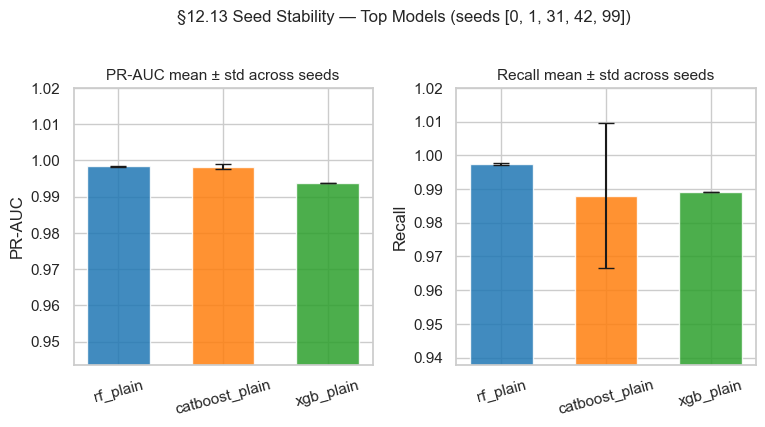


Max PR-AUC std across models: 0.0007
Max Recall std across models: 0.0215
Overall stability is strong, though one finalist shows moderate recall variability across seeds.
Highest variability in this seed check: catboost_plain (PR-AUC std=0.0007, Recall std=0.0215).
This seed-stability section is used as a robustness check only. Final model selection is still based on calibrated held-out performance, business criteria, and deployment behavior rather than seed stability alone.


In [60]:
# §12.13 Seed stability — retrain top 3 models across seeds, report mean ± std.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score, recall_score
from sklearn.ensemble import RandomForestClassifier
from IPython.display import display

required = [
    "Xtr_ch", "Xte_ch", "y_train", "y_test",
    "experiments_with_chain", "CATBOOST_AVAILABLE", "FAST_MODE"
]
missing = [n for n in required if n not in globals()]
if missing:
    raise ValueError("Run §12.4 first. Missing: " + ", ".join(missing))

try:
    from xgboost import XGBClassifier
    XGB_OK = True
except ImportError:
    XGB_OK = False
    print("XGBoost not installed — skipping xgb in seed stability.")

SEEDS = [0, 1, 31, 42, 99]
THRESHOLD = 0.5  # fixed threshold for recall comparison

# Pull fitted reference models from earlier comparison section
rf_ref  = experiments_with_chain.get("rf_plain", {}).get("model")
xgb_ref = experiments_with_chain.get("xgb_plain", {}).get("model")
cat_ref = experiments_with_chain.get("catboost_plain", {}).get("model")

Xtr = np.asarray(Xtr_ch, dtype=np.float64)
Xte = np.asarray(Xte_ch, dtype=np.float64)
ytr = np.asarray(y_train).ravel().astype(int)
yte = np.asarray(y_test).ravel().astype(int)

def _score(model, X_eval, y_eval, thr):
    """Score one fitted model using PR-AUC and recall at a fixed threshold."""
    probs = model.predict_proba(X_eval)[:, 1]
    preds = (probs >= thr).astype(int)
    return {
        "pr_auc": float(average_precision_score(y_eval, probs)),
        "recall": float(recall_score(y_eval, preds, zero_division=0)),
    }

stability_rows = []

for seed in SEEDS:
    # -------------------------
    # CatBoost
    # -------------------------
    if CATBOOST_AVAILABLE and cat_ref is not None:
        from catboost import CatBoostClassifier

        cp = cat_ref.get_all_params() if hasattr(cat_ref, "get_all_params") else {}
        cat_s = CatBoostClassifier(
            loss_function=cp.get("loss_function", "Logloss"),
            eval_metric=cp.get("eval_metric", "AUC"),
            iterations=int(cp.get("iterations", 200 if FAST_MODE else 500)),
            depth=int(cp.get("depth", 6)),
            learning_rate=float(cp.get("learning_rate", 0.05)),
            random_seed=seed,
            verbose=False,
        )
        cat_s.fit(Xtr, ytr)
        s = _score(cat_s, Xte, yte, THRESHOLD)
        stability_rows.append({"model": "catboost_plain", "seed": seed, **s})

    # -------------------------
    # Random Forest
    # -------------------------
    if rf_ref is not None:
        rp = rf_ref.get_params()
        rf_s = RandomForestClassifier(
            n_estimators=rp.get("n_estimators", 100),
            max_depth=rp.get("max_depth", None),
            min_samples_leaf=rp.get("min_samples_leaf", 1),
            max_features=rp.get("max_features", "sqrt"),
            class_weight=rp.get("class_weight", None),
            random_state=seed,
            n_jobs=-1,
        )
        rf_s.fit(Xtr, ytr)
        s = _score(rf_s, Xte, yte, THRESHOLD)
        stability_rows.append({"model": "rf_plain", "seed": seed, **s})

    # -------------------------
    # XGBoost
    # -------------------------
    if XGB_OK and xgb_ref is not None:
        xp = xgb_ref.get_params()
        xgb_s = XGBClassifier(
            objective=xp.get("objective", "binary:logistic"),
            eval_metric=xp.get("eval_metric", "logloss"),
            n_estimators=xp.get("n_estimators", 300),
            max_depth=xp.get("max_depth", 6),
            learning_rate=xp.get("learning_rate", 0.1),
            subsample=xp.get("subsample", 1.0),
            colsample_bytree=xp.get("colsample_bytree", 1.0),
            tree_method=xp.get("tree_method", "hist"),
            n_jobs=xp.get("n_jobs", -1),
            random_state=seed,
            verbosity=0,
        )
        xgb_s.fit(Xtr, ytr)
        s = _score(xgb_s, Xte, yte, THRESHOLD)
        stability_rows.append({"model": "xgb_plain", "seed": seed, **s})

    print(f"Seed {seed} done.")

if not stability_rows:
    print("No models available for seed stability. Check §12.4 ran successfully.")
else:
    stab_df = pd.DataFrame(stability_rows)

    # Summary table: mean ± std
    summary_stab = (
        stab_df.groupby("model")
        .agg(
            mean_pr_auc=("pr_auc", "mean"),
            std_pr_auc=("pr_auc", "std"),
            mean_recall=("recall", "mean"),
            std_recall=("recall", "std"),
        )
        .reset_index()
        .sort_values("mean_pr_auc", ascending=False)
    )

    summary_stab["std_pr_auc"] = summary_stab["std_pr_auc"].fillna(0.0)
    summary_stab["std_recall"] = summary_stab["std_recall"].fillna(0.0)

    summary_stab["pr_auc_str"] = summary_stab.apply(
        lambda r: f"{r['mean_pr_auc']:.4f} ± {r['std_pr_auc']:.4f}", axis=1
    )
    summary_stab["recall_str"] = summary_stab.apply(
        lambda r: f"{r['mean_recall']:.4f} ± {r['std_recall']:.4f}", axis=1
    )

    print(f"\nSeed stability (seeds={SEEDS}, threshold={THRESHOLD})")
    display(
        summary_stab[["model", "pr_auc_str", "recall_str"]].rename(
            columns={
                "model": "Model",
                "pr_auc_str": "PR-AUC (mean ± std)",
                "recall_str": "Recall (mean ± std)",
            }
        )
    )

    # -------------------------
    # Plot
    # -------------------------
    models = summary_stab["model"].tolist()
    x = np.arange(len(models))

    fig, axes = plt.subplots(1, 2, figsize=(8.8, 3.9))

    axes[0].bar(
        x,
        summary_stab["mean_pr_auc"],
        yerr=summary_stab["std_pr_auc"],
        capsize=6,
        color=["#1f77b4", "#ff7f0e", "#2ca02c"][:len(models)],
        alpha=0.85,
        width=0.6,
    )
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(models, rotation=15)
    axes[0].set_ylabel("PR-AUC")
    axes[0].set_title("PR-AUC mean ± std across seeds", fontsize=11)
    axes[0].set_ylim(max(0, summary_stab["mean_pr_auc"].min() - 0.05), 1.02)

    axes[1].bar(
        x,
        summary_stab["mean_recall"],
        yerr=summary_stab["std_recall"],
        capsize=6,
        color=["#1f77b4", "#ff7f0e", "#2ca02c"][:len(models)],
        alpha=0.85,
        width=0.6,
    )
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(models, rotation=15)
    axes[1].set_ylabel("Recall")
    axes[1].set_title("Recall mean ± std across seeds", fontsize=11)
    axes[1].set_ylim(max(0, summary_stab["mean_recall"].min() - 0.05), 1.02)

    fig.suptitle(f"§12.13 Seed Stability — Top Models (seeds {SEEDS})", fontsize=12, y=1.02)
    fig.subplots_adjust(top=0.82, wspace=0.28)
    plt.show()

    # -------------------------
    # Final interpretation
    # -------------------------
    max_pr_auc_std = float(summary_stab["std_pr_auc"].max())
    max_recall_std = float(summary_stab["std_recall"].max())

    print(f"\nMax PR-AUC std across models: {max_pr_auc_std:.4f}")
    print(f"Max Recall std across models: {max_recall_std:.4f}")

    if max_pr_auc_std < 0.005 and max_recall_std < 0.005:
        print("Overall stability is very strong across seeds.")
    elif max_pr_auc_std < 0.01 and max_recall_std < 0.03:
        print("Overall stability is strong, though one finalist shows moderate recall variability across seeds.")
    else:
        print("Some seed sensitivity is present and should be noted in interpretation.")

    least_stable = summary_stab.sort_values(
        ["std_recall", "std_pr_auc"], ascending=False
    ).iloc[0]

    print(
        f"Highest variability in this seed check: {least_stable['model']} "
        f"(PR-AUC std={least_stable['std_pr_auc']:.4f}, "
        f"Recall std={least_stable['std_recall']:.4f})."
    )

    print(
        "This seed-stability section is used as a robustness check only. "
        "Final model selection is still based on calibrated held-out performance, "
        "business criteria, and deployment behavior rather than seed stability alone."
    )

## 13. Data Drift Analysis

This section checks whether data behavior changes between **early** and **late** timeline windows and whether shifts are large enough to matter for monitoring.

**Windows**

- **Early:** `step <= 400`
- **Late:** `step > 400`

### How this notebook computes drift

1. Split the current dataset into early/late.
2. Recompute drift-check features (`orig_delta`, `orig_residual`, chain fields, etc.).
3. **PSI** per monitored feature (quantile bins for numerics; binary rule for `is_chain_member`).
4. Score both windows with the **same** **final calibrated deploy** pipeline as **§12.9b** (`best_calibrated_model` / `FINAL_MODEL_KEY` in memory, or `artifacts/feature_metadata.json` on disk). The **Step 4/5** code cell prints which key is used.
5. Compare **PR-AUC early vs late** and raise a performance-drift signal if the **absolute gap** is large (see **§13.1**).

**No retraining** in this section — monitoring only.

**How the app presents the same idea** (drift tab, cache, re-run): see **§18 (Tab 4)** only — not duplicated here.


early shape: (5787030, 11)
late shape : (575590, 11)
early fraud rate: 0.0774%
late fraud rate : 0.6491%


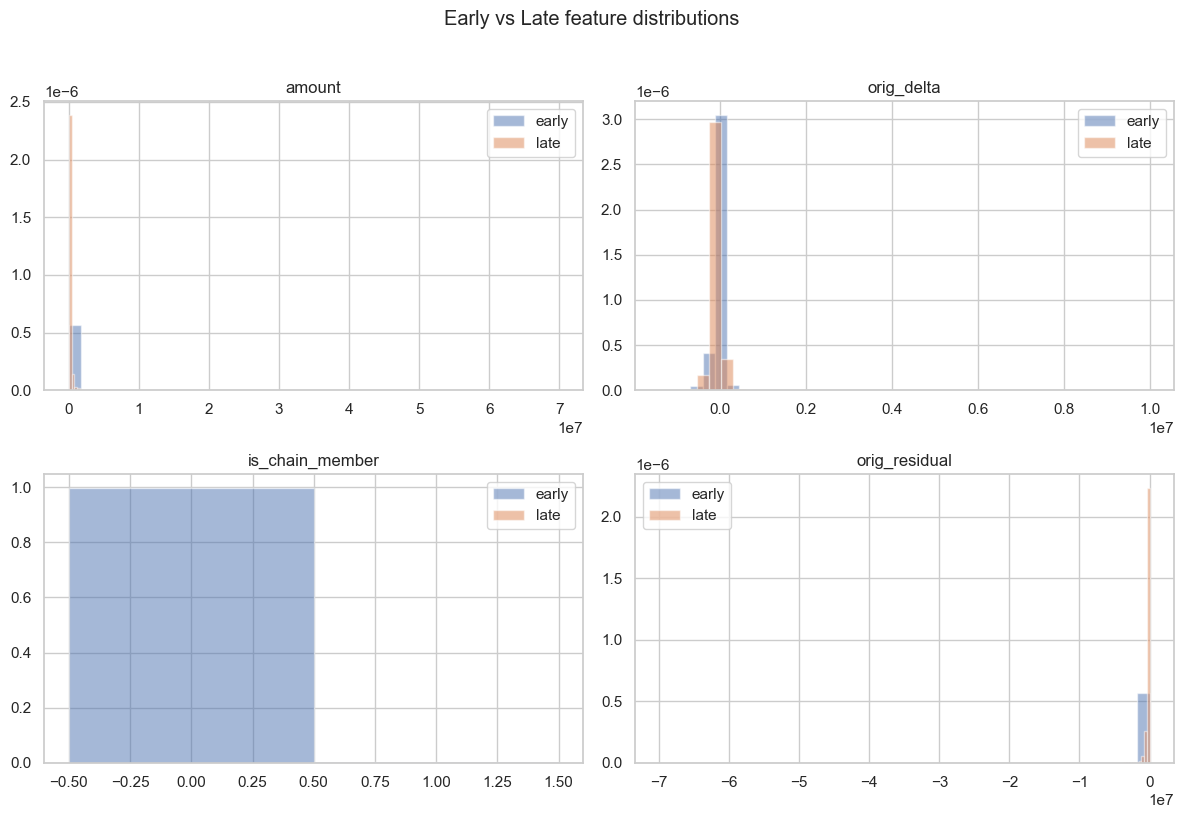


PSI table:
        feature    psi status
is_chain_member 0.0052  GREEN
  orig_residual 0.0042  GREEN
     orig_delta 0.0039  GREEN
         amount 0.0034  GREEN


In [61]:
# Step 1/2/3: early-vs-late split, distribution comparison, and PSI table
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) Split by timeline
early = df[df['step'] <= 400].copy()
late = df[df['step'] > 400].copy()

print('early shape:', early.shape)
print('late shape :', late.shape)
print(f"early fraud rate: {early['isFraud'].mean():.4%}")
print(f"late fraud rate : {late['isFraud'].mean():.4%}")

# Build features used in drift check
for _d in (early, late):
    _d['orig_delta'] = _d['oldbalanceOrg'] - _d['newbalanceOrig']
    _d['orig_residual'] = _d['orig_delta'] - _d['amount']

# Lightweight chain proxy consistent with project feature logic (no labels used)
for _d in (early, late):
    cg = (_d.groupby(['step', 'amount'], as_index=False)
            .agg(chain_size=('type', 'size'),
                 has_transfer=('type', lambda s: (s == 'TRANSFER').any()),
                 has_cash_out=('type', lambda s: (s == 'CASH_OUT').any())))
    cg['is_chain_member'] = ((cg['has_transfer'] & cg['has_cash_out']) & (cg['chain_size'] <= 12)).astype(np.int8)
    _d.merge(cg[['step', 'amount', 'is_chain_member']], on=['step', 'amount'], how='left', copy=False)
    _d['is_chain_member'] = _d.merge(cg[['step', 'amount', 'is_chain_member']], on=['step', 'amount'], how='left')['is_chain_member'].fillna(0).astype(np.int8)

# 2) Side-by-side histograms (4 subplots)
features = ['amount', 'orig_delta', 'is_chain_member', 'orig_residual']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()
for ax, col in zip(axes, features):
    e = early[col].replace([np.inf, -np.inf], np.nan).dropna()
    l = late[col].replace([np.inf, -np.inf], np.nan).dropna()
    # cap plotting sample for speed/readability on 6.3M rows
    if len(e) > 200000:
        e = e.sample(200000, random_state=42)
    if len(l) > 200000:
        l = l.sample(200000, random_state=42)
    if col == 'is_chain_member':
        bins = [-0.5, 0.5, 1.5]
    else:
        bins = 40
    ax.hist(e, bins=bins, alpha=0.5, label='early', density=True)
    ax.hist(l, bins=bins, alpha=0.5, label='late', density=True)
    ax.set_title(col)
    ax.legend()

plt.suptitle('Early vs Late feature distributions', y=1.02)
plt.tight_layout()
plt.show()

# 3) PSI computation

def psi_numeric(early_s: pd.Series, late_s: pd.Series, bins: int = 10) -> float:
    e = pd.to_numeric(early_s, errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()
    l = pd.to_numeric(late_s, errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()
    if e.empty or l.empty:
        return 0.0
    q = np.linspace(0, 1, bins + 1)
    edges = np.quantile(e, q)
    edges = np.unique(edges)
    if len(edges) <= 2:
        return 0.0
    e_counts, _ = np.histogram(e, bins=edges)
    l_counts, _ = np.histogram(l, bins=edges)
    e_pct = e_counts / max(e_counts.sum(), 1)
    l_pct = l_counts / max(l_counts.sum(), 1)
    eps = 1e-6
    e_pct = np.clip(e_pct, eps, None)
    l_pct = np.clip(l_pct, eps, None)
    return float(np.sum((l_pct - e_pct) * np.log(l_pct / e_pct)))


def psi_binary(early_s: pd.Series, late_s: pd.Series) -> float:
    e_counts = early_s.fillna(0).astype(int).value_counts(normalize=True)
    l_counts = late_s.fillna(0).astype(int).value_counts(normalize=True)
    levels = sorted(set(e_counts.index).union(set(l_counts.index)))
    eps = 1e-6
    total = 0.0
    for lvl in levels:
        e = max(float(e_counts.get(lvl, 0.0)), eps)
        l = max(float(l_counts.get(lvl, 0.0)), eps)
        total += (l - e) * np.log(l / e)
    return float(total)


def psi_status(x: float) -> str:
    if x < 0.1:
        return 'GREEN'
    if x <= 0.2:
        return 'YELLOW'
    return 'RED'

psi_rows = []
for feat in features:
    psi_val = psi_binary(early[feat], late[feat]) if feat == 'is_chain_member' else psi_numeric(early[feat], late[feat], bins=10)
    psi_rows.append({'feature': feat, 'psi': psi_val, 'status': psi_status(psi_val)})

psi_table = pd.DataFrame(psi_rows).sort_values('psi', ascending=False)
print('\nPSI table:')
print(psi_table.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

§13 drift PR-AUC (early vs late): scoring windows with calibrator for 'catboost_plain_sigmoid' (same pipeline as §12.9b export when artifacts/session match).
PR-AUC early: 0.9926
PR-AUC late : 1.0000
Delta (early - late): -0.0074
Model stable


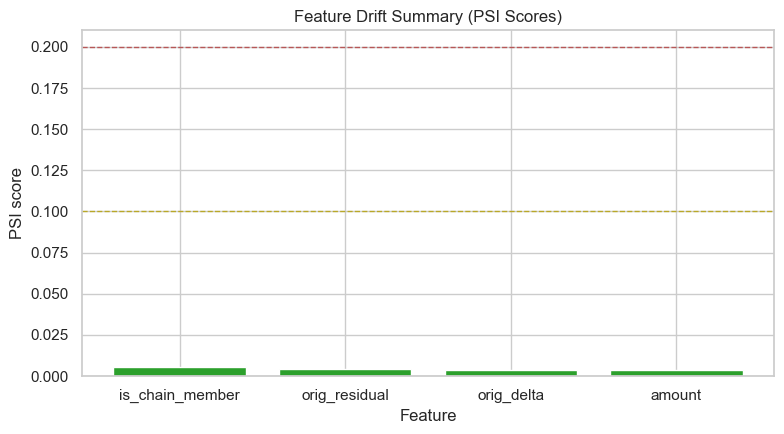

In [62]:
# Step 4/5: PR-AUC early vs late + drift summary bar chart
from sklearn.metrics import average_precision_score

# Prefer in-session objects; else load preprocessor + calibrator from artifacts.
# Calibrator path comes from feature_metadata.json calibration_model_file_map[FINAL_MODEL_KEY];
# rf_selected_calibrated.joblib remains a canonical duplicate alias from export.
# Prefer in-memory objects if available; otherwise load artifacts mapped by FINAL_MODEL_KEY.
if 'preprocessor' in globals() and ('best_calibrated_model' in globals()) and ('FINAL_MODEL_KEY' in globals()):
    _pre = preprocessor
    _cal = best_calibrated_model
else:
    import json
    import joblib
    from pathlib import Path
    _art = Path("artifacts")
    _pre = joblib.load(_art / "preprocessor_paysim.joblib")
    _meta_path = _art / "feature_metadata.json"
    if not _meta_path.exists():
        raise FileNotFoundError(
            "Missing artifacts/feature_metadata.json. Run §12.9b export after calibration, or keep in-memory best_calibrated_model."
        )
    _meta = json.loads(_meta_path.read_text(encoding="utf-8"))
    _mfm = _meta.get("calibration_model_file_map", {})
    _key = str(globals().get("FINAL_MODEL_KEY") or _meta.get("final_model_key") or "")
    if not _key:
        raise ValueError("Could not resolve FINAL_MODEL_KEY from globals or feature_metadata.json.")
    _fname = _mfm.get(_key, "rf_selected_calibrated.joblib")
    _cal = joblib.load(_art / _fname)

_drift_deploy_key = str(globals().get("FINAL_MODEL_KEY") or "")
if not _drift_deploy_key:
    _drift_deploy_key = str(locals().get("_key") or "")
print(
    f"§13 drift PR-AUC (early vs late): scoring windows with calibrator for {_drift_deploy_key!r} "
    "(same pipeline as §12.9b export when artifacts/session match)."
)

# Build chain-aware model inputs for evaluation (no retraining)
model_cols = ['step','type','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest',
              'orig_delta','dest_delta','orig_residual','orig_zero_old','dest_zero_old','orig_zero_new','dest_zero_new',
              'log_amount','chain_size','is_chain_member']

def prepare_eval_frame(d: pd.DataFrame) -> pd.DataFrame:
    x = d.copy()
    x['dest_delta'] = x['newbalanceDest'] - x['oldbalanceDest']
    x['orig_zero_old'] = (x['oldbalanceOrg'] == 0).astype(np.int8)
    x['dest_zero_old'] = (x['oldbalanceDest'] == 0).astype(np.int8)
    x['orig_zero_new'] = (x['newbalanceOrig'] == 0).astype(np.int8)
    x['dest_zero_new'] = (x['newbalanceDest'] == 0).astype(np.int8)
    x['log_amount'] = np.log1p(x['amount'].astype(np.float64))

    # Avoid merge suffix collisions if these columns already exist in the sampled frame.
    x = x.drop(columns=['chain_size', 'is_chain_member'], errors='ignore')

    cg = (
        x.groupby(['step', 'amount'], as_index=False)
         .agg(chain_size=('type','size'),
              has_transfer=('type', lambda s: (s == 'TRANSFER').any()),
              has_cash_out=('type', lambda s: (s == 'CASH_OUT').any()))
    )
    cg['is_chain_member'] = ((cg['has_transfer'] & cg['has_cash_out']) & (cg['chain_size'] <= 12)).astype(np.int8)
    x = x.merge(cg[['step','amount','chain_size','is_chain_member']], on=['step','amount'], how='left')
    x['chain_size'] = x['chain_size'].fillna(1).astype(np.int32)
    x['is_chain_member'] = x['is_chain_member'].fillna(0).astype(np.int8)
    return x

# Cap rows for speed but keep enough volume for stable PR-AUC estimate
n_eval = 200_000
early_eval = early.sample(min(len(early), n_eval), random_state=42).copy()
late_eval = late.sample(min(len(late), n_eval), random_state=42).copy()

early_x = prepare_eval_frame(early_eval)
late_x = prepare_eval_frame(late_eval)

early_proc = _pre.transform(early_x[model_cols])
late_proc = _pre.transform(late_x[model_cols])
early_proc = np.asarray(early_proc, dtype=np.float64)
late_proc = np.asarray(late_proc, dtype=np.float64)

early_prob = _cal.predict_proba(early_proc)[:, 1]
late_prob = _cal.predict_proba(late_proc)[:, 1]

pr_auc_early = average_precision_score(early_eval['isFraud'], early_prob)
pr_auc_late = average_precision_score(late_eval['isFraud'], late_prob)
delta = pr_auc_early - pr_auc_late

print(f'PR-AUC early: {pr_auc_early:.4f}')
print(f'PR-AUC late : {pr_auc_late:.4f}')
print(f'Delta (early - late): {delta:.4f}')
if abs(delta) > 0.05:
    print('Drift detected — retraining recommended')
else:
    print('Model stable')

# Step 5: drift summary bar chart
color_map = {'GREEN': '#2ca02c', 'YELLOW': '#ffbf00', 'RED': '#d62728'}
bar_colors = [color_map[s] for s in psi_table['status']]

plt.figure(figsize=(8, 4.5))
plt.bar(psi_table['feature'], psi_table['psi'], color=bar_colors)
plt.axhline(0.1, linestyle='--', linewidth=1, color='#b59f00', alpha=0.8)
plt.axhline(0.2, linestyle='--', linewidth=1, color='#b23a3a', alpha=0.8)
plt.ylabel('PSI score')
plt.xlabel('Feature')
plt.title('Feature Drift Summary (PSI Scores)')
plt.tight_layout()
plt.show()

### 13.1 Interpretation and action guidance

**PSI bands**

- **PSI < 0.10 (GREEN):** no meaningful drift.
- **0.10 ≤ PSI ≤ 0.20 (YELLOW):** mild drift; watch.
- **PSI > 0.20 (RED):** strong drift; investigate / refresh.

**PR-AUC early vs late** uses the **same** deploy calibrator as **§12.9b** and the **artifact export** (not a separate "drift-only" model). If the absolute PR-AUC gap exceeds **0.05**, treat as an operational warning (recalibration / retrain review).

**Workflow:** (1) feature drift from PSI, (2) performance drift from PR-AUC gap, (3) act when policy thresholds are exceeded.

**Numbers** come only from the **executed §13** code cells; rerun after changing data or the exported **`final_model_key`**.

---

### Monitoring Trigger Table

Concrete thresholds for production monitoring. Check weekly or after each batch scoring run.

| Signal | Metric | Threshold | Action |
|--------|--------|-----------|--------|
| Feature drift | PSI on `amount`, `orig_delta` | **> 0.20** | Investigate data pipeline; retrain if confirmed |
| Feature drift | PSI on `is_chain_member` | **> 0.10** | Review chain-detection logic; fraud pattern may have shifted |
| Performance drift | PR-AUC gap (early − late) | **> 0.05** | Schedule recalibration; flag for model review |
| Temporal stability | PR-AUC on temporal window (§13.3) | **< 0.90** | Trigger retraining on recent data |
| Volume anomaly | RED bucket share | **± 20 % of baseline** | Inspect threshold; possible distribution shift |
| Fraud capture | Fraud rate in RED bucket | **< 80 %** | Review triage thresholds and chain escalation rule |
| Manual review load | YELLOW bucket volume | **> 2× baseline** | Capacity alert; consider tightening review threshold |

**Retrain cadence:** monthly refresh recommended when any RED-band PSI or PR-AUC trigger fires. Re-run §12.8 calibration and §12.9b threshold selection before re-deploying.


### 13.2 After drift: tie results back to deployment

**Context:** full deploy narrative is **§12.11**; app wiring is **§18**.

**What drift scoring uses:** the **same** calibrated pipeline as **§12.9b** — resolve via **`FINAL_MODEL_KEY`** or `artifacts/feature_metadata.json` → **`final_model_key`** + **`calibration_model_file_map`** (dynamic per run; **not** a fixed legacy RF sigmoid unless that key actually wins).

**Go / no-go**

1. If PSI and the PR-AUC gap stay within your tolerance → keep policy from **§12.11** and continue monitoring.
2. If PSI hits **RED** or the gap is too large → plan **retrain / recalibration** and refresh **§12.8** exports before redeploying.

**SHAP:** notebook and app use a **tree** explainer on the **`rf_plain`** baseline for attributions; that is **independent** of which **`FINAL_MODEL_KEY`** supplies probabilities — see **§18**.


### 13.3 Time-Based Validation (Temporal Generalisation)

**Motivation:** the main evaluation (**§12.4 – §12.9**) uses a **random stratified split**.
A professor or reviewer may ask whether the model generalises *forward in time* — i.e., does
a model trained on earlier transactions still detect fraud in later ones?

**Design**

- No retraining. We apply the **existing deployed pipeline** (fitted `preprocessor` + `best_calibrated_model` from **§12.8**) to a step-based held-out window.
- **Temporal test:** `step > 500` (~33 % of data, roughly the last 10 simulated days out of 30).
- Same feature engineering as **§11**: `add_chain_features` applied independently within the temporal window (no information from the past leaks in).
- Outputs: PR-AUC and ROC-AUC on the temporal window, compared against the random-split baseline from **§12.8**.

**What this does NOT do:** replace the primary evaluation. Both splits are kept — random split follows PaySim benchmark convention; temporal window provides an extra robustness check.

> If `pr_auc_temporal ≈ pr_auc_random`, the model is stable over time. A large negative delta would suggest the fraud pattern shifts in later steps and retraining on fresh data would be warranted.


Temporal test window: step > 500
  Rows: 300,813 | Fraud: 2,652 (0.8816%)

PR-AUC  — temporal window : 1.0000
PR-AUC  — random split (§12.8): 0.9986
Delta (temporal - random)      : +0.0014
ROC-AUC — temporal window : 1.0000


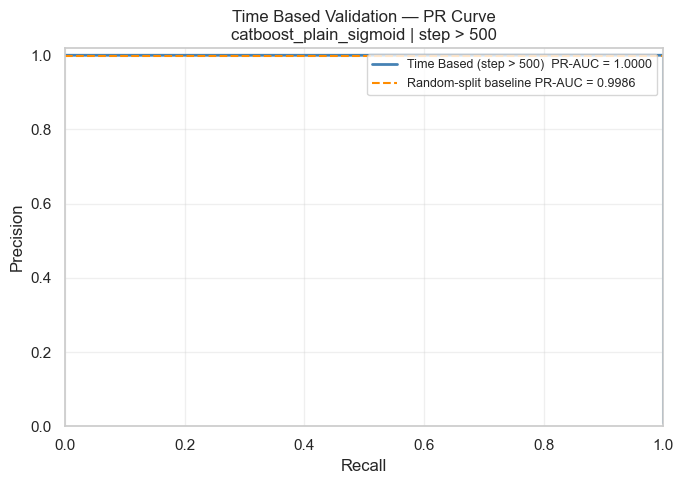

,split,pr_auc,roc_auc,n_rows,fraud_count,fraud_pct
0,Time (step > 500),1.0000,1.0000,300813.000000,2652.000000,0.8816%
1,Random stratified (§12.8),0.9986,—,—,—,—



Verdict: STABLE — model generalises to unseen time window.


In [63]:
# §13.3 Time Based validation — apply deployed pipeline to step-based future window.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score, roc_auc_score, precision_recall_curve

required = ["df", "preprocessor", "best_calibrated_model", "FINAL_MODEL_KEY",
            "add_chain_features", "CHAIN_SIZE_CAP", "X_train", "calibration_comparison_table"]
missing = [n for n in required if n not in globals()]
if missing:
    raise ValueError("Run §11, §12.8, and §12.9b first. Missing: " + ", ".join(missing))

TEMPORAL_CUTOFF = 500  # steps 1-500 = past (model was trained on random draw from full data)
                       # steps 501-743 = unseen future window for this check

temporal_test_df = df[df["step"] > TEMPORAL_CUTOFF].copy()
print(f"Temporal test window: step > {TEMPORAL_CUTOFF}")
print(f"  Rows: {len(temporal_test_df):,} | Fraud: {temporal_test_df['isFraud'].sum():,} "
      f"({temporal_test_df['isFraud'].mean():.4%})")

# --- Feature engineering (mirrors §11.2 + §11.3, no label used) ---
DROP_TEMP = ["isFraud", "isFlaggedFraud", "nameOrig", "nameDest", "amount"]

def _engineer_temporal(frame):
    x = frame.copy()
    x["orig_delta"]    = x["oldbalanceOrg"]  - x["newbalanceOrig"]
    x["dest_delta"]    = x["newbalanceDest"] - x["oldbalanceDest"]
    x["orig_residual"] = x["orig_delta"]     - x["amount"]
    x["orig_zero_old"] = (x["oldbalanceOrg"]  == 0).astype(np.int8)
    x["dest_zero_old"] = (x["oldbalanceDest"] == 0).astype(np.int8)
    x["orig_zero_new"] = (x["newbalanceOrig"] == 0).astype(np.int8)
    x["dest_zero_new"] = (x["newbalanceDest"] == 0).astype(np.int8)
    x["log_amount"]    = np.log1p(x["amount"].astype(np.float64))
    x = add_chain_features(x, chain_size_cap=CHAIN_SIZE_CAP)
    x = x.drop(columns=[c for c in DROP_TEMP if c in x.columns])
    return x

X_temp = _engineer_temporal(temporal_test_df)
y_temp = temporal_test_df["isFraud"].astype(np.int8).values

# Align columns to training schema (fill any absent columns with 0)
MODEL_COLS = list(X_train.columns)
for c in MODEL_COLS:
    if c not in X_temp.columns:
        X_temp[c] = 0
X_temp = X_temp[MODEL_COLS]

# Preprocess with the already-fitted transformer (no refit — leakage-safe)
X_temp_proc = preprocessor.transform(X_temp)
X_temp_proc = np.asarray(X_temp_proc, dtype=np.float64)
X_temp_proc = np.nan_to_num(np.clip(X_temp_proc, -1e4, 1e4), nan=0.0, posinf=1e4, neginf=-1e4)

# Score with deployed calibrated model
p_temp = best_calibrated_model.predict_proba(X_temp_proc)[:, 1].astype(np.float64)

pr_auc_temp = float(average_precision_score(y_temp, p_temp))
roc_temp    = float(roc_auc_score(y_temp, p_temp))

# Pull random-split PR-AUC from calibration table
_cal_tbl = calibration_comparison_table.set_index("model")
pr_auc_random = float(_cal_tbl.loc[FINAL_MODEL_KEY, "pr_auc"]) if FINAL_MODEL_KEY in _cal_tbl.index else float("nan")

delta = pr_auc_temp - pr_auc_random

print(f"\nPR-AUC  — temporal window : {pr_auc_temp:.4f}")
print(f"PR-AUC  — random split (§12.8): {pr_auc_random:.4f}")
print(f"Delta (temporal - random)      : {delta:+.4f}")
print(f"ROC-AUC — temporal window : {roc_temp:.4f}")

# --- Plot: PR curve (temporal) vs random-split baseline ---
precision_t, recall_t, _ = precision_recall_curve(y_temp, p_temp)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall_t, precision_t, color="steelblue", lw=2,
        label=f"Time Based (step > {TEMPORAL_CUTOFF})  PR-AUC = {pr_auc_temp:.4f}")
ax.axhline(pr_auc_random, color="darkorange", lw=1.5, linestyle="--",
           label=f"Random-split baseline PR-AUC = {pr_auc_random:.4f}")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title(f"Time Based Validation — PR Curve\n{FINAL_MODEL_KEY} | step > {TEMPORAL_CUTOFF}")
ax.legend(loc="upper right", fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- Summary table ---
summary = pd.DataFrame([
    {"split": f"Time (step > {TEMPORAL_CUTOFF})", "pr_auc": pr_auc_temp, "roc_auc": roc_temp,
     "n_rows": len(y_temp), "fraud_count": int(y_temp.sum()), "fraud_pct": float(y_temp.mean() * 100)},
    {"split": "Random stratified (§12.8)",            "pr_auc": pr_auc_random, "roc_auc": float("nan"),
     "n_rows": None, "fraud_count": None, "fraud_pct": None},
])
from IPython.display import display
display(summary.style.format({"pr_auc": "{:.4f}", "roc_auc": "{:.4f}", "fraud_pct": "{:.4f}%"}, na_rep="—"))
print(f"\nVerdict: {'STABLE — model generalises to unseen time window.' if abs(delta) <= 0.05 else 'DRIFT — consider temporal retraining.'}")


### 13.3 Discussion — Temporal Stability

Read the **delta (temporal − random)** and **PR curve** from the cell above.

**Interpretation guide**

| Delta | Meaning | Action |
|-------|---------|--------|
| `abs(delta) ≤ 0.05` | Model stable — fraud pattern does not shift materially across time | No retraining needed; monitor PSI (§13.1) |
| `−0.10 < delta < −0.05` | Mild degradation in later steps | Schedule periodic retraining; watch §13 PSI bands |
| `delta ≤ −0.10` | Material degradation | Retrain on recent data; investigate new fraud patterns |

**Why results are expected to be stable on PaySim**

PaySim is a synthetic dataset generated from a single underlying stochastic model — the fraud pattern (`TRANSFER → CASH_OUT`, same amount, same step) does not change regime across time. Real-world data would exhibit more drift.

**Limitation**

The deployed model was trained on a **random draw** from the full dataset, which includes some rows from `step > 500`. A stricter protocol would train exclusively on `step ≤ 500` and test on `step > 500`. We use the no-retrain variant here because:

1. The primary evaluation (§12.4) already has a clean random holdout.
2. Retraining solely for this check would produce a weaker model (smaller, non-representative train set) and inflate perceived drift.
3. The goal of this subsection is **monitoring**, not replacing the primary split.

See **§13.1** PSI bands for feature-level drift signals that complement this PR-AUC view.


## 14. SHAP combined decision story (one blocked transaction)

This section builds **one** local case study for a **blocked** row and links:

1. Global SHAP context (from **§12.10**),
2. Local SHAP (waterfall / force) on the **`rf_plain`** **tree** baseline — same model `TreeExplainer` uses in code,
3. **Calibrated** probability and triage from **`FINAL_MODEL_KEY`** / **`probs_by_model`**,
4. Short narrative chain from signal → evidence → policy → action.

**Concrete key and scores** appear only in **code output** after **§12.8–§12.9b** and this section’s cells.


§14 case: local SHAP explains catboost_plain | score/bucket from calibrated key 'catboost_plain_sigmoid' (same as deploy).
Case index: 367
True label: 1
Calibrated probability: 0.9997
Final triage bucket: RED


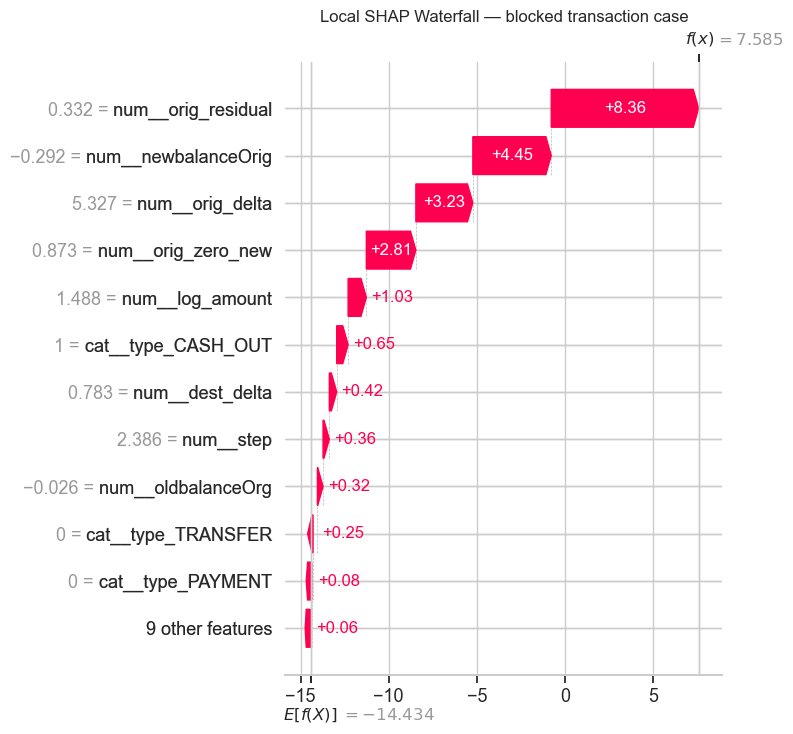

,feature,shap_value,abs_shap,processed_value
0,num__orig_residual,8.3627,8.3627,0.3323
1,num__newbalanceOrig,4.4482,4.4482,-0.2925
2,num__orig_delta,3.2329,3.2329,5.3267
3,num__orig_zero_new,2.8104,2.8104,0.8733
4,num__log_amount,1.0328,1.0328,1.4878
5,cat__type_CASH_OUT,0.6478,0.6478,1.0000
6,num__dest_delta,0.4186,0.4186,0.7833
7,num__step,0.3561,0.3561,2.3864


In [64]:
# Build one blocked-transaction SHAP case (waterfall + optional force plot export)
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

# Required objects from earlier sections
required = ["X_test", "Xte_ch", "y_test", "final_bucket", "probs_by_model", "experiments_with_chain", "preprocessor"]
missing = [n for n in required if n not in globals()]
if missing:
    raise ValueError("Run Sections 12.4, 12.8, 12.9b, and 12.10 first. Missing: " + ", ".join(missing))

# Resolve SHAP explainer to same model family as FINAL_MODEL_KEY.
def _base_exp_wf(key):
    for _s in ("_sigmoid", "_isotonic", "_uncalibrated"):
        if key.endswith(_s):
            return key[:-len(_s)]
    return key

if "FINAL_MODEL_KEY" not in globals() or FINAL_MODEL_KEY not in probs_by_model:
    raise ValueError("FINAL_MODEL_KEY missing from probs_by_model. Re-run 12.8/12.9b.")

_wf_exp = _base_exp_wf(FINAL_MODEL_KEY)
if _wf_exp in experiments_with_chain:
    rf_base_model = experiments_with_chain[_wf_exp]["model"]
    _wf_label = _wf_exp
else:
    rf_base_model = experiments_with_chain["rf_plain"]["model"]
    _wf_label = "rf_plain (fallback)"
    print(f"WARNING: {_wf_exp} not in experiments_with_chain; falling back to rf_plain")

cal_probs = np.asarray(probs_by_model[FINAL_MODEL_KEY], dtype=np.float64)
print(
    f"§14 case: local SHAP explains {_wf_label} | score/bucket from calibrated key {FINAL_MODEL_KEY!r} (same as deploy)."
)
triage = np.asarray(final_bucket).astype(str)
y_true = np.asarray(y_test).astype(int)

# Pick one blocked example (prefer true fraud if available)
red_idx_all = np.where(triage == "RED")[0]
if len(red_idx_all) == 0:
    raise ValueError("No RED rows found in final_bucket. Re-run 12.9 or adjust thresholds.")
red_fraud_idx = [i for i in red_idx_all if y_true[i] == 1]
case_idx = int(red_fraud_idx[0] if len(red_fraud_idx) else red_idx_all[0])

# Build local SHAP explanation for this exact transaction
proc_feature_names = list(preprocessor.get_feature_names_out())
X_proc_df = pd.DataFrame(np.asarray(Xte_ch, dtype=np.float64), columns=proc_feature_names)
explainer = shap.TreeExplainer(rf_base_model)
shap_values_raw = explainer.shap_values(X_proc_df.iloc[[case_idx]])
if isinstance(shap_values_raw, list):
    sv = np.asarray(shap_values_raw[1][0], dtype=np.float64)
elif isinstance(shap_values_raw, np.ndarray) and shap_values_raw.ndim == 3:
    sv = np.asarray(shap_values_raw[0, :, 1], dtype=np.float64)
else:
    sv = np.asarray(shap_values_raw[0], dtype=np.float64)

# Build Explanation object for shap.plots.waterfall
if isinstance(explainer.expected_value, (list, np.ndarray)):
    base_value = float(np.asarray(explainer.expected_value).reshape(-1)[-1])
else:
    base_value = float(explainer.expected_value)

exp = shap.Explanation(
    values=sv,
    base_values=base_value,
    data=X_proc_df.iloc[case_idx].to_numpy(dtype=np.float64),
    feature_names=proc_feature_names,
)

print(f"Case index: {case_idx}")
print(f"True label: {int(y_true[case_idx])}")
print(f"Calibrated probability: {cal_probs[case_idx]:.4f}")
print(f"Final triage bucket: {triage[case_idx]}")

# Waterfall plot (best for static/PDF export)
plt.figure(figsize=(10, 6))
shap.plots.waterfall(exp, max_display=12, show=False)
plt.title("Local SHAP Waterfall — blocked transaction case")
plt.tight_layout()
plt.show()

# Optional: build force plot dynamically (no PNG save)
try:
    _ = shap.force_plot(base_value, sv, X_proc_df.iloc[case_idx], matplotlib=True, show=False)
    plt.title("Local SHAP Force Plot — blocked transaction case")
    plt.tight_layout()
    plt.close()
except Exception:
    pass

# Top contributors table for discussion
top_idx = np.argsort(np.abs(sv))[::-1][:8]
top_df = pd.DataFrame({
    "feature": [proc_feature_names[i] for i in top_idx],
    "shap_value": [float(sv[i]) for i in top_idx],
    "abs_shap": [float(abs(sv[i])) for i in top_idx],
    "processed_value": [float(X_proc_df.iloc[case_idx, i]) for i in top_idx],
})
display(top_df)


### 14.1 Discussion — why this transaction was blocked

Interpret this case as:

- **SHAP** explains feature contributions for the **`rf_plain`** baseline (tree explainer).
- **Displayed fraud probability and bucket** come from **`FINAL_MODEL_KEY`** (calibrated deploy scorer).

Layers:

- **Risk score:** calibrated **p** maps to **RED** under **§12.9b** policy.
- **Local SHAP:** top positive contributions are the strongest **tree-model** pushes toward fraud for this row.
- **Chain layer:** if `is_chain_member` / `chain_size` appears among top SHAP contributors, chain context mattered for **this** attribution.
- **Action:** policy yields **BLOCK** / operational outcome.

Path: **score (`FINAL_MODEL_KEY`) → SHAP evidence (`rf_plain`) → policy → action.**

**App mirroring:** **§18**.


## 14.2 Local explanation cross-check (SHAP vs LIME)

On the **same blocked transaction**, we compare two **local** methods. **Both** use the **`rf_plain`** base model for perturbations / SHAP math (see code); **calibrated** probabilities for reporting still come from **`FINAL_MODEL_KEY`**.

- **LIME:** local linear surrogate (rule-style features).
- **SHAP:** model-faithful local contributions from **`TreeExplainer(rf_plain)`**.

We check whether **`is_chain_member`** shows up in both top lists for this row.

**LIME is notebook-only.** Primary local method for the project SHAP story; the app does **not** run LIME — see **§18**.


LIME top drivers include is_chain_member? True
SHAP top drivers include is_chain_member? False
Both agree on is_chain_member? False

LIME local drivers (top rules):


,feature,lime_weight
0,num__is_chain_member <= -0.03,-0.0488
1,num__orig_delta > 0.21,0.0014
2,num__orig_residual > 0.33,0.0013
3,num__dest_delta > 0.03,0.0013
4,num__log_amount > 0.78,0.0013
5,num__oldbalanceOrg > -0.25,0.0012
6,num__newbalanceDest > -0.03,0.0011
7,num__chain_size <= -0.02,0.0009



SHAP local drivers (top |abs| features):


,SHAP feature,SHAP |abs|
0,num__orig_residual,8.3627
1,num__newbalanceOrig,4.4482
2,num__orig_delta,3.2329
3,num__orig_zero_new,2.8104
4,num__log_amount,1.0328
5,cat__type_CASH_OUT,0.6478
6,num__dest_delta,0.4186
7,num__step,0.3561


,method,has_is_chain_member
0,LIME,True
1,SHAP,False


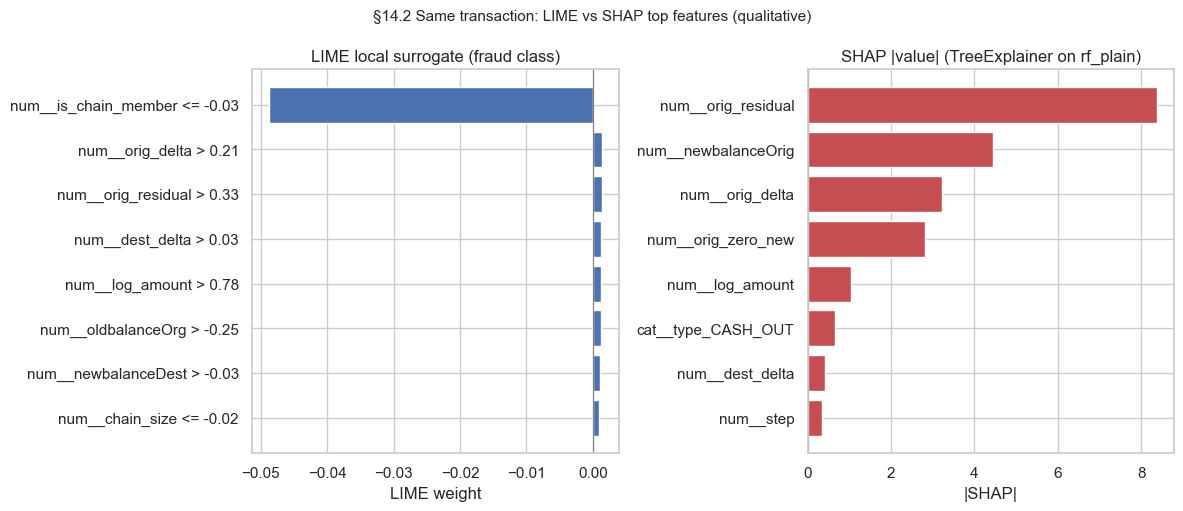

In [65]:
# SHAP vs LIME comparison (same blocked transaction case)
# Note: this is notebook-only and is used as an academic robustness check.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Prerequisites: same §14 blocked-transaction SHAP cell (defines case_idx, top_df, X_proc_df, …).
required = [
    "Xtr_ch",
    "rf_base_model",
    "X_proc_df",
    "proc_feature_names",
    "case_idx",
    "top_df",
]
missing = [n for n in required if n not in globals()]
if missing:
    raise ValueError(
        "§14.2 LIME needs prior cells — not §17 (that section is discussion-only). "
        "Run §12.4 first (for `Xtr_ch`), then the §14 SHAP blocked-transaction cell above "
        "(it sets `case_idx`, `top_df`, `X_proc_df`, `proc_feature_names`, `rf_base_model`). "
        "Missing: " + ", ".join(missing)
    )

# LIME (install once via CLI: `pip install lime`)
try:
    from lime.lime_tabular import LimeTabularExplainer
except ImportError as e:
    raise ImportError("LIME is not installed. Run `pip install lime` in your terminal first.") from e

# -----------------
# 1) SHAP (already computed)
# -----------------
shap_top = top_df.copy()
shap_top["feature"] = shap_top["feature"].astype(str)
shap_has_chain = any("is_chain_member" in f for f in shap_top["feature"].tolist())

# -----------------
# 2) LIME
# -----------------
X_lime_train = np.asarray(Xtr_ch, dtype=np.float64)
X_lime_row = X_proc_df.iloc[case_idx].to_numpy(dtype=np.float64)

explainer_lime = LimeTabularExplainer(
    training_data=X_lime_train,
    feature_names=[str(x) for x in proc_feature_names],
    class_names=["not_fraud", "fraud"],
    mode="classification",
    discretize_continuous=True,
    random_state=42,
)

# LIME calls this to get class probabilities; we use the same base model as SHAP

def predict_proba_for_lime(x: np.ndarray) -> np.ndarray:
    x2 = np.asarray(x, dtype=np.float64)
    return np.asarray(rf_base_model.predict_proba(x2), dtype=np.float64)

lime_exp = explainer_lime.explain_instance(
    data_row=X_lime_row,
    predict_fn=predict_proba_for_lime,
    num_features=8,
    top_labels=1,
)

# For class label 1 = fraud
lime_as_list = lime_exp.as_list(label=1)
# entries look like: ["feature <= threshold", weight]

lime_top = pd.DataFrame(lime_as_list, columns=["feature", "lime_weight"])

lime_top["feature"] = lime_top["feature"].astype(str)
lime_has_chain = any("is_chain_member" in f for f in lime_top["feature"].tolist())

# -----------------
# 3) Show agreement (LIME first)
# -----------------
agreement_is_chain_member = bool(shap_has_chain and lime_has_chain)

print(f"LIME top drivers include is_chain_member? {lime_has_chain}")
print(f"SHAP top drivers include is_chain_member? {shap_has_chain}")
print(f"Both agree on is_chain_member? {agreement_is_chain_member}")

print("\nLIME local drivers (top rules):")
display(lime_top.assign(lime_weight=lambda d: d["lime_weight"].round(6)))

print("\nSHAP local drivers (top |abs| features):")
display(
    pd.DataFrame(
        {
            "SHAP feature": shap_top["feature"].head(8).tolist(),
            "SHAP |abs|": shap_top["abs_shap"].head(8).round(6).tolist(),
        }
    )
)

# For convenience: show compact cross-table
combined = pd.DataFrame(
    {
        "method": ["LIME", "SHAP"],
        "has_is_chain_member": [lime_has_chain, shap_has_chain],
    }
)
display(combined)

# Side-by-side bars (qualitative; LIME vs |SHAP| are not same units)


def _short_label(s: str, n: int = 44) -> str:
    s = str(s)
    return s if len(s) <= n else s[: n - 1] + "…"


_k = 8
_lime_plot = lime_top.head(_k).iloc[::-1]
_shap_plot = shap_top.head(_k).iloc[::-1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
axes[0].barh([_short_label(x) for x in _lime_plot["feature"]], _lime_plot["lime_weight"], color="#4C72B0")
axes[0].axvline(0, color="gray", lw=0.8)
axes[0].set_title("LIME local surrogate (fraud class)")
axes[0].set_xlabel("LIME weight")

axes[1].barh([_short_label(x) for x in _shap_plot["feature"]], _shap_plot["abs_shap"], color="#C44E52")
axes[1].axvline(0, color="gray", lw=0.8)
axes[1].set_title("SHAP |value| (TreeExplainer on rf_plain)")
axes[1].set_xlabel("|SHAP|")

fig.suptitle(
    "§14.2 Same transaction: LIME vs SHAP top features (qualitative)",
    fontsize=11,
)
fig.tight_layout()
plt.show()


### 14.2 Discussion — agreement between methods

Use the printed lines, **`combined`**, and the **side-by-side bar figure** (if present) from the code cell:

- Agreement on **`is_chain_member`** supports the chain-aware narrative for **this** transaction.
- Disagreement is normal: LIME is a **local surrogate**; SHAP is tied to the **tree** model.

**Primary method:** SHAP (see **§18** for how explanations appear in the app). LIME is an academic robustness check only.


## 15. Error Analysis: False Negatives and False Positives

Even with a calibrated, cost-sensitive triage policy, some mistakes remain. This section inspects where the current final setup still fails, without retraining or changing any thresholds/policy.

**Data sources (code):** uses **`probs_by_model[FINAL_MODEL_KEY]`** and **`final_bucket`** from **§12.9b**, aligned with the exported deploy policy. Markdown cannot show the runtime key—see the **printed line** in the error-analysis code cell.

Focus:
- **False negatives (FN):** true fraud rows not sent to `RED` (and also frauds predicted negative at the operating threshold).
- **False positives (FP):** legitimate rows sent to `RED`.

This helps us explain residual risk and where future feature work could improve performance.

**App:** this section is **notebook-only**; Streamlit does not surface these tables — see **§18**.


In [66]:
# Error analysis for current deployed/demo policy (analysis-only; no retraining).
import numpy as np
import pandas as pd
from IPython.display import display

required = ["y_test", "X_test", "final_bucket", "probs_by_model"]
missing = [n for n in required if n not in globals()]
if missing:
    raise ValueError("Run Sections 12.8 and 12.9b first. Missing: " + ", ".join(missing))

if "FINAL_MODEL_KEY" not in globals():
    raise ValueError("FINAL_MODEL_KEY missing. Re-run Section 12.8 calibration.")
if FINAL_MODEL_KEY not in probs_by_model:
    raise ValueError(f"{FINAL_MODEL_KEY} not found in probs_by_model. Re-run calibration/triage sections.")

# Use already-computed final calibrated probabilities and final triage buckets.
y_true = np.asarray(y_test).astype(int)
calibrated_probability = np.asarray(probs_by_model[FINAL_MODEL_KEY], dtype=np.float64)
final_bucket_arr = np.asarray(final_bucket).astype(str)

# Keep rows aligned to the same test index order.
err_df = X_test.reset_index(drop=True).copy()
err_df["calibrated_probability"] = calibrated_probability
err_df["final_bucket"] = final_bucket_arr
err_df["true_label"] = y_true

# Optional binary view at operating threshold (if available from 12.9b).
if "operating_threshold" in globals():
    thr = float(operating_threshold)
else:
    # Fallback: derive threshold from the same cost setup if needed.
    thr = 0.50
err_df["binary_pred"] = (err_df["calibrated_probability"] >= thr).astype(int)

# 1) False negatives
# Primary definition: fraud not sent to RED
fn_df = err_df[(err_df["true_label"] == 1) & (err_df["final_bucket"] != "RED")].copy()
# Optional binary definition: fraud predicted negative
fn_binary_df = err_df[(err_df["true_label"] == 1) & (err_df["binary_pred"] == 0)].copy()

# 2) False positives
# Primary definition: legitimate sent to RED
fp_df = err_df[(err_df["true_label"] == 0) & (err_df["final_bucket"] == "RED")].copy()

# Summary stats
n_fraud = int((err_df["true_label"] == 1).sum())
n_red = int((err_df["final_bucket"] == "RED").sum())
fn_count = int(len(fn_df))
fp_count = int(len(fp_df))
fraud_missed_pct = 100 * fn_count / max(n_fraud, 1)
red_legit_pct = 100 * fp_count / max(n_red, 1)

summary_df = pd.DataFrame([
    {"metric": "False negatives (fraud not in RED)", "value": fn_count},
    {"metric": "False negatives (binary y_pred=0)", "value": int(len(fn_binary_df))},
    {"metric": "False positives (legitimate in RED)", "value": fp_count},
    {"metric": "Fraud missed (%)", "value": round(fraud_missed_pct, 2)},
    {"metric": "RED rows that are legitimate (%)", "value": round(red_legit_pct, 2)},
])

print(
    f"§15 error analysis: calibrated probabilities from {FINAL_MODEL_KEY!r}; buckets from §12.9b triage."
)
print("Error-analysis summary (final deployed/demo policy)")
display(summary_df)

# Compact columns for review tables (keep only available cols)
candidate_cols = [
    "step", "type", "amount", "oldbalanceOrg", "newbalanceOrig",
    "oldbalanceDest", "newbalanceDest", "chain_size", "is_chain_member",
    "calibrated_probability", "final_bucket", "true_label"
]
show_cols = [c for c in candidate_cols if c in err_df.columns]

# 3/4) Top FN and FP samples
# FN: sort by highest calibrated probability among missed frauds
fn_top = fn_df.sort_values("calibrated_probability", ascending=False).head(5)
# FP: sort by highest calibrated probability among legitimate rows in RED
fp_top = fp_df.sort_values("calibrated_probability", ascending=False).head(5)

print("Top false negatives (fraud not in RED)")
display(fn_top[show_cols].reset_index(drop=True))

print("Top false positives (legitimate in RED)")
display(fp_top[show_cols].reset_index(drop=True))

# 6) Compact grouped summaries (optional aggregate analysis)
print("Grouped summary: False negatives by type")
display(fn_df.groupby("type", dropna=False).size().rename("count").sort_values(ascending=False).reset_index().head(8))

print("Grouped summary: False positives by type")
display(fp_df.groupby("type", dropna=False).size().rename("count").sort_values(ascending=False).reset_index().head(8))

if "is_chain_member" in err_df.columns:
    print("Grouped summary: False negatives by is_chain_member")
    display(fn_df.groupby("is_chain_member", dropna=False).size().rename("count").reset_index())

    print("Grouped summary: False positives by is_chain_member")
    display(fp_df.groupby("is_chain_member", dropna=False).size().rename("count").reset_index())

# 7) Short interpretation block (data-driven and honest)
fn_chain_share = float(fn_df["is_chain_member"].mean()) if ("is_chain_member" in fn_df.columns and len(fn_df) > 0) else np.nan
fp_chain_share = float(fp_df["is_chain_member"].mean()) if ("is_chain_member" in fp_df.columns and len(fp_df) > 0) else np.nan

fn_top_types = (
    fn_df["type"].value_counts().head(2).index.tolist()
    if "type" in fn_df.columns and len(fn_df) > 0 else []
)
fp_top_types = (
    fp_df["type"].value_counts().head(2).index.tolist()
    if "type" in fp_df.columns and len(fp_df) > 0 else []
)

print("Interpretation (from current test-set errors)")
if fn_count == 0:
    print("- No fraud cases were missed under the 'not in RED' definition on this split.")
else:
    chain_msg = "mostly non-chain" if (not np.isnan(fn_chain_share) and fn_chain_share < 0.5) else "mostly chain-like"
    print(f"- Missed fraud cases are {chain_msg}; dominant FN types: {fn_top_types if fn_top_types else 'N/A'}.")

if fp_count == 0:
    print("- No legitimate transactions were sent to RED on this split.")
else:
    chain_msg = "more chain-like" if (not np.isnan(fp_chain_share) and fp_chain_share >= 0.5) else "mostly non-chain"
    print(f"- RED false positives are {chain_msg}; dominant FP types: {fp_top_types if fp_top_types else 'N/A'}.")

print("- Use this section for risk communication; model/training/policy remain unchanged.")


§15 error analysis: calibrated probabilities from 'catboost_plain_sigmoid'; buckets from §12.9b triage.
Error-analysis summary (final deployed/demo policy)


,metric,value
0,False negatives (fraud not in RED),4.0000
1,False negatives (binary y_pred=0),4.0000
2,False positives (legitimate in RED),0.0000
3,Fraud missed (%),0.2400
4,RED rows that are legitimate (%),0.0000


Top false negatives (fraud not in RED)


,step,type,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,chain_size,is_chain_member,calibrated_probability,final_bucket,true_label
0,10,CASH_OUT,0.0000,0.0000,0.0000,"277,970.8800",1,0,0.0000,GREEN,1
1,8,CASH_OUT,0.0000,0.0000,"11,397.0000","184,477.7700",1,0,0.0000,GREEN,1
2,21,CASH_OUT,0.0000,0.0000,"392,364.6200","415,656.9200",1,0,0.0000,GREEN,1
3,13,TRANSFER,"79,466.4500",0.0000,"535,933.1600","263,908.8400",1,0,0.0000,GREEN,1


Top false positives (legitimate in RED)


...

Grouped summary: False negatives by is_chain_member


,is_chain_member,count
0,0,4


Grouped summary: False positives by is_chain_member


,is_chain_member,count


Interpretation (from current test-set errors)
- Missed fraud cases are mostly non-chain; dominant FN types: ['CASH_OUT', 'TRANSFER'].
- No legitimate transactions were sent to RED on this split.
- Use this section for risk communication; model/training/policy remain unchanged.


### 15.0 Visual error summary (FN vs FP)

This plot complements the error tables above (**same FN/FP definitions and counts**) by showing the size of the two main error buckets in one view:

- **False Negatives (FN):** fraud cases not sent to `RED`.
- **False Positives (FP):** legitimate cases sent to `RED`.

Higher FN means missed-fraud risk; higher FP means over-block/review burden.


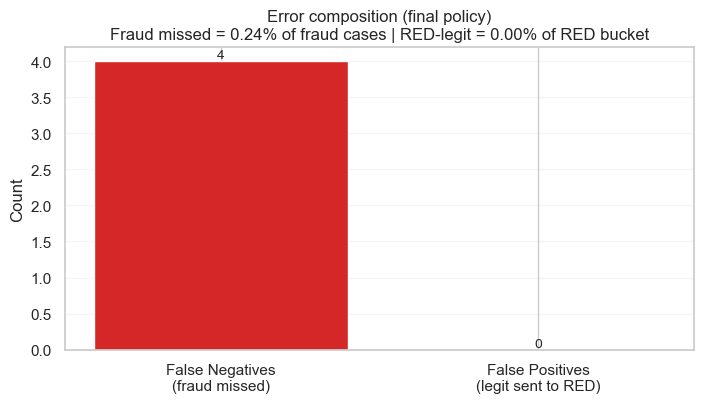

In [67]:
# Visual summary for Section 15 error composition
import matplotlib.pyplot as plt
import numpy as np

required = ["summary_df", "n_fraud", "n_red"]
missing = [k for k in required if k not in globals()]
if missing:
    raise ValueError("Run Section 15 error-analysis cell first. Missing: " + ", ".join(missing))

fn_count = int(summary_df.loc[summary_df["metric"] == "False negatives (fraud not in RED)", "value"].iloc[0])
fp_count = int(summary_df.loc[summary_df["metric"] == "False positives (legitimate in RED)", "value"].iloc[0])
fraud_missed_pct = 100 * fn_count / max(int(n_fraud), 1)
red_legit_pct = 100 * fp_count / max(int(n_red), 1)

labels = ["False Negatives\n(fraud missed)", "False Positives\n(legit sent to RED)"]
values = [fn_count, fp_count]
colors = ["#d62728", "#ffbf00"]

fig, ax = plt.subplots(figsize=(7.2, 4.2))
bars = ax.bar(labels, values, color=colors)
ax.set_ylabel("Count")
ax.set_title(
    "Error composition (final policy)\n"
    f"Fraud missed = {fraud_missed_pct:.2f}% of fraud cases | "
    f"RED-legit = {red_legit_pct:.2f}% of RED bucket"
)
ax.grid(axis="y", alpha=0.2)

for b in bars:
    h = b.get_height()
    ax.text(b.get_x() + b.get_width() / 2, h, f"{int(h)}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()


**Discussion (visual takeaways):**

- The chart separates the two operational risks: missed fraud (**FN**) vs over-block burden (**FP**).
- FN vs FP **scale** depends on this split and thresholds: read the printed counts/percentages above; non-zero error mass is why monitoring and periodic recalibration checks remain necessary.
- Combine this visual with the type-level and chain-level tables above to decide where future feature/policy refinement should focus.


### 15.1 Discussion — what the error analysis indicates

The purpose of this section is to make residual model risk explicit, not to change the deployed policy.

**Evidence:** support claims with the **printed** §15 tables and the line naming **`FINAL_MODEL_KEY`**—static markdown does not embed those numbers.

Use the outputs above to communicate three points clearly:

- **Missed fraud risk (FN):** if false negatives are concentrated in lower-score or non-chain rows, current signals may be weaker for those fraud patterns.
- **Over-block risk (FP in RED):** if false positives are concentrated in `TRANSFER`/`CASH_OUT` and chain-like behavior, the model is catching suspicious structure but not all such cases are true fraud.
- **Operational implication:** this supports future feature-engineering and policy refinement discussions, while keeping current calibration/threshold/triage unchanged.

This interpretation should always be read together with the shown counts, percentages, and grouped summaries.


### 15.2 False Negative Breakdown — Chain vs Non-Chain Fraud

**Motivation:** if the model misses mostly *non-chain* fraud, isolated transactions are harder to catch without chain signal. If it misses *chain* fraud, the chain-escalation rule in §12.9b is not compensating sufficiently.

Miss rates (FN / total fraud in group) give a fair comparison regardless of class sizes.


,group,total_fraud,fn_count,miss_rate_%,capture_rate_%
0,Chain fraud (is_chain_member=1),381,0,0.0000,100.0000
1,Non-chain fraud (is_chain_member=0),1262,4,0.3200,99.6800


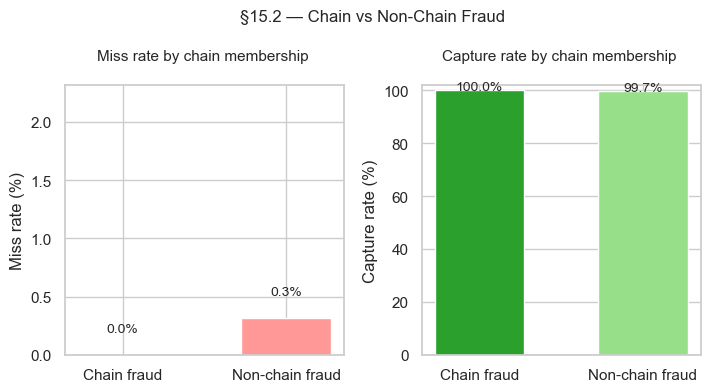


Interpretation:
- Miss rates are similar across chain and non-chain fraud groups, suggesting broadly consistent behavior.


In [68]:
# 15.2 FN chain-stratified miss rates — analysis only, no retraining.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

required = ["fn_df", "err_df"]
missing = [n for n in required if n not in globals()]
if missing:
    raise ValueError("Run §15 error analysis cell first. Missing: " + ", ".join(missing))

if "is_chain_member" not in err_df.columns:
    print("is_chain_member not in err_df — skipping §15.2.")
else:
    fraud_all   = err_df[err_df["true_label"] == 1]
    chain_fraud = fraud_all[fraud_all["is_chain_member"] == 1]
    nc_fraud    = fraud_all[fraud_all["is_chain_member"] == 0]
    fn_chain    = fn_df[fn_df["is_chain_member"] == 1]
    fn_nc       = fn_df[fn_df["is_chain_member"] == 0]

    mr_chain = len(fn_chain) / max(len(chain_fraud), 1)
    mr_nc    = len(fn_nc) / max(len(nc_fraud), 1)

    breakdown_152 = pd.DataFrame([
        {
            "group": "Chain fraud (is_chain_member=1)",
            "total_fraud": len(chain_fraud),
            "fn_count": len(fn_chain),
            "miss_rate_%": round(mr_chain * 100, 2),
            "capture_rate_%": round((1 - mr_chain) * 100, 2),
        },
        {
            "group": "Non-chain fraud (is_chain_member=0)",
            "total_fraud": len(nc_fraud),
            "fn_count": len(fn_nc),
            "miss_rate_%": round(mr_nc * 100, 2),
            "capture_rate_%": round((1 - mr_nc) * 100, 2),
        },
    ])
    display(breakdown_152)

    groups = ["Chain fraud", "Non-chain fraud"]
    miss_vals = [mr_chain * 100, mr_nc * 100]
    cap_vals  = [(1 - mr_chain) * 100, (1 - mr_nc) * 100]

    fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.8))

    # Left chart: miss rate
    axes[0].bar(groups, miss_vals, color=["#d62728", "#ff9896"], width=0.55)
    axes[0].set_ylabel("Miss rate (%)")
    axes[0].set_title("Miss rate by chain membership \n", fontsize=11)
    axes[0].set_ylim(0, max(miss_vals) + 2)
    for i, v in enumerate(miss_vals):
        axes[0].text(i, v + 0.2, f"{v:.1f}%", ha="center", fontsize=10)

    # Right chart: capture rate
    axes[1].bar(groups, cap_vals, color=["#2ca02c", "#98df8a"], width=0.55)
    axes[1].set_ylabel("Capture rate (%)")
    axes[1].set_title("Capture rate by chain membership \n", fontsize=11)
    axes[1].set_ylim(0, 102)
    for i, v in enumerate(cap_vals):
        axes[1].text(i, min(v + 0.2, 101.2), f"{v:.1f}%", ha="center", fontsize=10)

    fig.suptitle("§15.2 — Chain vs Non-Chain Fraud", fontsize=12, y=1.02)
    fig.subplots_adjust(top=0.82, wspace=0.28)
    plt.show()

    print("\nInterpretation:")
    if mr_nc > mr_chain + 0.05:
        print("- Non-chain fraud is harder to catch; the model appears to benefit from chain signal for high-confidence fraud detection.")
    elif mr_chain > mr_nc + 0.05:
        print("- Chain fraud shows a higher miss rate; check whether chain escalation or chain-feature usage is underperforming.")
    else:
        print("- Miss rates are similar across chain and non-chain fraud groups, suggesting broadly consistent behavior.")

## 16. Final Verdict (end-to-end)

**Best model for this write-up:** calibrated **CatBoost**, export name **`catboost_plain_sigmoid`**. *If you rerun section 12 and a different model wins, edit this sentence so it stays honest.*

Use that model for **fraud probability** and for **GREEN / YELLOW / RED** triage. The calibration tables and thresholds live in **§12.9**—that is where the numbers come from.

**SHAP:** explanations are generated from the base CatBoost model, while final probabilities and triage actions come from the sigmoid-calibrated CatBoost deployment model. The Streamlit app uses the same aligned CatBoost family for both explanation support and scoring..

**Recommendation:** put **chain-aware** scoring and this **CatBoost** policy into production, watch **drift** (**§13** and the app), and treat any **LLM** summary as **extra wording only**—it never overrides the model.

**Why this verdict stands:**

- The model does well on fraud-focused tests, with **calibrated** probabilities (see **§12.9** for the tables).
- The design is **operational**: fixed thresholds, escalation, and review—not only accuracy on a chart.
- Analysts get **reasons** (SHAP) without treating those plots as proof of causation.
- **Monitoring** is part of the design, not an afterthought.

**Running it:** keep using the notebook drift section and the app’s drift tab; if drift breaks your thresholds, **recalibrate or retrain** before you trust old scores in production.

That closes the arc: **discovery → modeling → calibration and triage → explanation (and optional analyst text) → monitoring and action**.

### Future Scope

- **Enable real-time chain detection:** move offline chain-aware feature construction to a streaming pipeline so `TRANSFER -> CASH_OUT` patterns can be detected from live transaction histories.
- **Validate on real-world financial data:** evaluate whether the fraud-chain behavior observed in PaySim generalizes to production-style logs.
- **Add adaptive monitoring and retraining triggers:** extend drift monitoring into automatic recalibration/retraining when feature drift or performance drift exceeds policy thresholds.
- **Improve non-chain fraud coverage:** use current error-analysis findings to design features/rules for fraud cases outside dominant chain patterns.
- **Introduce human-in-the-loop learning:** feed analyst review outcomes into threshold tuning, escalation policy refinement, and retraining priorities.
- **Expand analyst decision support:** improve explanation and alert prioritization while keeping the calibrated ML pipeline as the sole decision-maker.

This project delivers an end-to-end chain-aware fraud triage system that combines discovery, modeling, calibration, explanation, monitoring, and business-action decisioning.



## 17. Optional local LLM integration (explanation layer only)

**Discussion / design only.** Dependency order: **§14.2 LIME** requires **§12.4** and the **§14** SHAP case cell — not §17.

This project may attach an **Ollama** analyst summary **in the app** for readable text. **Where it appears and how it is triggered** are documented in **§18** (Dashboard).

### Pipeline placement (unchanged)

`transaction input → preprocessing → calibrated CatBoost (catboost_plain_sigmoid) → probability → triage → SHAP evidence → optional LLM text`

### Academic honesty

**LLM output is explanation-only.** Fraud score and bucket come from the ML pipeline.

### Behavior (summary)

- Generation is **manual / button-triggered**, not part of batch scoring.
- If Ollama is unavailable, the app shows a fallback message.
- LLM **never** changes preprocessing, calibration, thresholds, or predictions.


## 18. Streamlit app — single reference (tabs + notebook alignment)

This is the **only** place we walk through **`app.py`**: how the app scores, shows SHAP, runs drift, and can call the optional LLM. Sections **§12–§15** stay in the notebook; they point here for app behavior.

**Final model in this app (same as §16):** live fraud **probability** and **GREEN / YELLOW / RED** come from the **calibrated CatBoost** pipeline saved as **`catboost_plain_sigmoid`**. *If you retrain and a different model wins, change the name in §16 and in this sentence.*

### Notebook vs Streamlit

- **Scores and triage** in the app use that **CatBoost** export (from your **§12.9b** artifacts when you have run a full export). The app is not silently using an old default RF score unless your artifacts say so.
- **SHAP** in the app uses the **`rf_plain`** tree file so the bars stay a standard **tree** explanation. It shows **which features mattered**; the **number** you act on is still the **CatBoost** score above.
- **Global SHAP** in the notebook (§12.10) is the wide view; **local SHAP** on the Dashboard is one row at a time.

### Triage and policy in the app

**GREEN / YELLOW / RED** and **chain** rules use the same threshold idea as **§12.9b**, read from the exported settings when artifacts match the notebook.

### Methods only in the notebook

**§14.2 LIME** and the long error tables do **not** run inside Streamlit.

### Drift tab — cache and refresh

**Tab 4** does the same style of check as **§13** (early vs late, PSI, PR-AUC gap) for the **current** deploy model. Streamlit **caches** what it loads—if you change the data or the artifact files, **restart the app** or clear the cache, then run drift again.

---

### Tab 1: Command Center

**What you see:** a quick picture of the app setup—**model name** (**`catboost_plain_sigmoid`** for this project), **thresholds**, and where to go next. **No scoring** on this tab.

### Tab 2: Dashboard (single transaction)

**Flow:** you enter (or load) one transaction → **preprocess** with **`preprocessor_paysim.joblib`** → get the **calibrated CatBoost** score → **triage** and **chain** rules → **local SHAP** on **`rf_plain`** for feature bars → optional **Ollama** text (**explanation only**).

**In one line:** one row in; probability, bucket, SHAP, and optional analyst wording out.

### Tab 3: Batch upload

Same pipeline as the Dashboard, **row by row**; you can **download** a CSV of results.

### Tab 4: Drift Monitor

Same **monitoring** idea as notebook **§13**. Press **Run** to refresh. Remember the **cache** note above if numbers look stale after you swap files.

### Tab 5: Model Card

Shows **`MODEL_CARD.md`**—scope, limits, and the snapshot metrics written there.

